# NB02 — WTI Volatility: Benchmark de Modelos
## GARCH · LSTM Univariado · LSTM Multivariado · Híbrido (FinBERT)

| Campo | Valor |
|---|---|
| **Tesis** | Predicción de Regímenes Extremos de Volatilidad WTI |
| **Notebook** | NB02 — Benchmark GARCH + LSTM |
| **Versión** | v1.0 |
| **Fecha** | 2026-02-26 |
| **Objetivo** | Superar estándar ingenuo B1: F1 > 0.4872, AUC > 0.8241 · Referencia cuantitativa B5: F1 > 0.7416 (Christoffersen 1998) |
| **Target** | `y_tp1` — régimen extremo en t+1 (forecast causal) |

> **Nota metodológica**: El umbral de clasificación (P95 = 0.042996) fue calibrado en NB01 sobre `train CLEAN`.
> No se recalcula en este notebook. Se carga directamente de `config_estudio_FINAL.json`.

> **Valores de referencia dinámicos**: Los umbrales B1/B5 se imprimen al ejecutar Cell 0.5 (carga del config). Los valores en esta tabla corresponden a la última ejecución certificada del NB01.

## 0.1 IMPORTAR LIBRERÍAS Y VERIFICAR ENTORNO

In [1]:
# ── Instalación arch con recompilación forzada ─────────────────
# --no-binary arch: compila desde fuente contra el numpy del entorno.
# Evita el error "numpy.dtype size changed" de wheels precompiladas.
import subprocess
subprocess.run(
    ['pip', 'install', 'arch', '--no-binary', 'arch', '-q'],
    check=True
)

# Limpiar módulo cacheado si ya estaba importado en esta sesión
import sys
for mod in list(sys.modules.keys()):
    if 'arch' in mod:
        del sys.modules[mod]

# Importar y verificar
import arch
import numpy as np

print(f"arch version  : {arch.__version__}")
print(f"numpy version : {np.__version__}")
assert int(arch.__version__.split('.')[0]) >= 5, \
    f"Versión insuficiente: {arch.__version__}. Se requiere >= 5.x"
print("arch OK ✓")

arch version  : 8.0.0
numpy version : 2.0.2
arch OK ✓


In [2]:
# ─── 0.2 Imports y patrón Colab ───────────────────────────────
import sys, os, json, random, warnings, pickle
from datetime import datetime
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit

# Imbalanced-learn
# from imblearn.over_sampling import SMOTE
# SMOTE prohibido: rompe estructura temporal. Usar class_weight.

# GARCH (arch package)
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# TensorFlow / Keras —
import tensorflow as tf
from tensorflow import keras

print(f"TF version     : {tf.__version__}")
print(f"Fecha ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


TF version     : 2.19.0
Fecha ejecución: 2026-03-16 11:52:17


In [3]:
# ─── 0.3 Seeds de reproducibilidad (TODAS las fuentes) ────────
RANDOM_SEED = 42

random.seed(RANDOM_SEED)                        #Python
np.random.seed(RANDOM_SEED)                     #Numpy
tf.random.set_seed(RANDOM_SEED)                 #TensorFlow
os.environ['TF_DETERMINISTIC_OPS'] = '1'        #Determinismo interno TF
os.environ['CUDA_VISIBLE_DEVICES'] = ''         #Forzar CPU reproducible
os.environ['PYTHONHASHSEED']      = str(RANDOM_SEED)      #Orden interno Python

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# IEEE-style — idéntico a NB01
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif'],
    'font.size'         : 10,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'legend.fontsize'   : 9,
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : ':',
    'axes.edgecolor'    : 'black',
    'axes.linewidth'    : 0.8,
})

print(f"RANDOM_SEED = {RANDOM_SEED}  |  seeds fijadas")


RANDOM_SEED = 42  |  seeds fijadas


In [4]:
# ─── 0.4 Versiones del entorno (reproducibilidad) ─────────────
import imblearn, sklearn, statsmodels, scipy, matplotlib, seaborn

print("  ENTORNO DE EJECUCIÓN — NB02 WTI Benchmark")
print(f" \nPython          : {sys.version.split()[0]}")
print(f"  numpy           : {np.__version__}")
print(f"  pandas          : {pd.__version__}")
print(f"  tensorflow      : {tf.__version__}")
print(f"  arch            : {arch.__version__}")
print(f"  scikit-learn    : {sklearn.__version__}")
print(f"  imbalanced-learn: {imblearn.__version__}")
print(f"  statsmodels     : {statsmodels.__version__}")
print(f"  scipy           : {scipy.__version__}")
print(f"  matplotlib      : {matplotlib.__version__}")
print(f"  seaborn         : {seaborn.__version__}")

  ENTORNO DE EJECUCIÓN — NB02 WTI Benchmark
 
Python          : 3.12.12
  numpy           : 2.0.2
  pandas          : 2.2.2
  tensorflow      : 2.19.0
  arch            : 8.0.0
  scikit-learn    : 1.6.1
  imbalanced-learn: 0.14.1
  statsmodels     : 0.14.6
  scipy           : 1.16.3
  matplotlib      : 3.10.0
  seaborn         : 0.13.2


In [5]:
# ─── 0.5 Rutas, detección de entorno y guards de integridad ───

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"IN_COLAB : {IN_COLAB}")

if IN_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print(f"Drive ya montado o error: {e}")
    BASE_PATH   = "/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos"
    OUTPUT_PATH = BASE_PATH
    FIG_PATH    = "/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/Fig_NB02"
else:
    BASE_PATH   = "."
    OUTPUT_PATH = "."
    FIG_PATH    = "./Fig_NB02"

CONFIG_PATH = f"{BASE_PATH}/config_estudio_FINAL.json"
CSV_PATH    = f"{BASE_PATH}/wti_volatilidad_CLEAN.csv"

# Crear directorios necesarios
for _dir in [FIG_PATH,                            # figuras del benchmark
             f"{OUTPUT_PATH}/predicciones_nb02",  #CSVs de predicciones por modelo
             f"{OUTPUT_PATH}/modelos_nb02"]:      # Modelos Keras y scalers
    Path(_dir).mkdir(parents=True, exist_ok=True)
    print(f"  dir OK : {_dir}")

print(f"  config : {CONFIG_PATH}  ✓")
print(f"  CSV    : {CSV_PATH}  ✓")

IN_COLAB : True
Mounted at /content/drive
  dir OK : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/Fig_NB02
  dir OK : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/predicciones_nb02
  dir OK : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/modelos_nb02
  config : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/config_estudio_FINAL.json  ✓
  CSV    : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/wti_volatilidad_CLEAN.csv  ✓


In [6]:
# 0.5 Rutas y carga de config
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

nb02_cfg = config['nb02']

#  Parámetros fijos (NO recalcular — fuente: config_estudio_FINAL.json)
UMBRAL_CLASIFICACION = nb02_cfg['umbral_clasificacion']
VENTANA_VOL          = nb02_cfg['ventana_vol']            # 21

# Estándar mínimo — baseline ingenuo (B1, regla de 1 variable)
F1_MINIMO  = nb02_cfg['baseline_ingenuo']['f1_minimo']
AUC_MINIMO = nb02_cfg['baseline_ingenuo']['auc_minimo']

# Referencia cuantitativa — B5 Christoffersen (1998), evaluado val + test
F1_CUANT      = nb02_cfg['baseline_cuantitativo']['f1_val']
AUC_CUANT     = nb02_cfg['baseline_cuantitativo']['auc_val']
F1_CUANT_TEST = nb02_cfg['baseline_cuantitativo']['f1_test']
AUC_CUANT_TEST= nb02_cfg['baseline_cuantitativo']['auc_test']

TRAIN_END  = config['fechas']['train_end']
VAL_START  = config['fechas']['val_start']
VAL_END    = config['fechas']['val_end']
TEST_START = config['fechas']['test_start']

# ── Guardia de integridad ──
_UMBRAL_ESPERADO = 0.04299581565948056
assert abs(UMBRAL_CLASIFICACION - _UMBRAL_ESPERADO) < 1e-10, (
    f"UMBRAL_CLASIFICACION={UMBRAL_CLASIFICACION:.14f} no coincide con "
    f"valor esperado={_UMBRAL_ESPERADO:.14f}\n"
    f"  → Regenerar config ejecutando NB01 completo"
)

print(f"\nUmbral clasificación : {UMBRAL_CLASIFICACION:.14f}")
print(f"Ventana vol          : {VENTANA_VOL}")
print(f"Estándar mínimo (B1) : F1>{F1_MINIMO:.4f} | AUC>{AUC_MINIMO:.4f}")
print(f"Ref. cuantitativa B5 : F1_val={F1_CUANT:.4f} | AUC_val={AUC_CUANT:.4f}")
print(f"                       F1_test={F1_CUANT_TEST:.4f} | AUC_test={AUC_CUANT_TEST:.4f}")
print(f"Splits               : train ≤ {TRAIN_END} | "
      f"val {VAL_START}–{VAL_END} | test ≥ {TEST_START}")
print(f"Base path            : {BASE_PATH}")
print("config cargado")



Umbral clasificación : 0.04299581565948
Ventana vol          : 21
Estándar mínimo (B1) : F1>0.4872 | AUC>0.8241
Ref. cuantitativa B5 : F1_val=0.7416 | AUC_val=0.9805
                       F1_test=0.5474 | AUC_test=0.9983
Splits               : train ≤ 2018-12-31 | val 2019-01-02–2020-12-31 | test ≥ 2021-01-02
Base path            : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos
config cargado


In [7]:
# ─── 0.6 Carga de CSV y verificación de integridad ────────────
df = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True)
df = df.sort_index()

print(f"Shape total: {df.shape}")
print(f"Rango fechas: {df.index.min().date()} → {df.index.max().date()}")
print()

# ── Shapes por split ──
print("─── Shapes por split ───────────────────────────────")
for s in ['train', 'validation', 'test']:
    sub     = df[df['split'] == s]
    n_valid = sub['is_extreme_clean'].notna().sum()
    n_ext   = int(sub['is_extreme_clean'].sum())
    n_bad   = int(sub['bad_vol21'].sum())
    rate    = n_ext / n_valid if n_valid > 0 else 0
    print(f"  {s:12s}: {len(sub):5,} filas | {n_valid:5,} válidas | "
          f"{n_ext:3d} extremos ({rate:.1%}) | {n_bad} bad_vol21")

# ── Distribución is_extreme_clean ──
print()
print("─── Distribución is_extreme_clean ──────────────────")
print(df['is_extreme_clean'].value_counts(dropna=False))

# ── NaN por columna clave ──
key_cols = ['vol21', 'vol21_clean', 'returns', 'is_extreme_clean',
            'var_rolling_252', 'hl_spread', 'co_spread',
            'ma_cross', 'bad_vol21']
print()
print("─── NaN por columna clave ───────────────────────────")
print(df[key_cols].isna().sum())

# ── Confirmar umbral P95 ──
p95_train = df.loc[df['split'] == 'train', 'vol21_clean'].quantile(0.95)
print()
print(f"─── Verificación umbral P95 ─────────────────────────")
print(f"  P95 calculado en train  : {p95_train:.14f}")
print(f"  P95 desde config (NB01) : {UMBRAL_CLASIFICACION:.14f}")
print(f"  Diferencia              : {abs(p95_train - UMBRAL_CLASIFICACION):.2e}")

# ── Nuevas columnas disponibles desde NB01 actualizado (Feb 2026) ──────────
# returns_zscore_clean : Z-score de retornos; NaN en dias bad_vol21
# outlier_zscore_clean : flag booleano de outliers en retornos
# p95_vol21_rolling_252: umbral dinamico P95 de vol21 (252 dias rolling)
# is_extreme_dynamic   : clasificacion de regimen usando umbral dinamico
NUEVAS_COLS    = ['returns_zscore_clean', 'outlier_zscore_clean',
                  'p95_vol21_rolling_252', 'is_extreme_dynamic']
cols_presentes = [c for c in NUEVAS_COLS if c in df.columns]
cols_faltantes = [c for c in NUEVAS_COLS if c not in df.columns]
print(f"\nColumnas nuevas de NB01 actualizado: "
      f"{len(cols_presentes)}/{len(NUEVAS_COLS)} presentes")
for c in cols_presentes:
    print(f"  OK {c}")
for c in cols_faltantes:
    print(f"  FALTA {c}  <- regenerar NB01 y re-exportar CSV")
if cols_faltantes:
    print("  ADVERTENCIA: col(s) faltante(s) -- "
          "ejecutar NB01 completo y guardar wti_volatilidad_CLEAN.csv")


Shape total: (6363, 31)
Rango fechas: 2000-09-22 → 2026-02-27

─── Shapes por split ───────────────────────────────
  train       : 4,584 filas | 4,584 válidas | 230 extremos (5.0%) | 0 bad_vol21
  validation  :   483 filas |   483 válidas |  39 extremos (8.1%) | 0 bad_vol21
  test        : 1,296 filas | 1,296 válidas |  27 extremos (2.1%) | 0 bad_vol21

─── Distribución is_extreme_clean ──────────────────
is_extreme_clean
0.000000    6067
1.000000     296
Name: count, dtype: int64

─── NaN por columna clave ───────────────────────────
vol21                 0
vol21_clean           0
returns               0
is_extreme_clean      0
var_rolling_252     125
hl_spread             0
co_spread             0
ma_cross              0
bad_vol21             0
dtype: int64

─── Verificación umbral P95 ─────────────────────────
  P95 calculado en train  : 0.04299581565948
  P95 desde config (NB01) : 0.04299581565948
  Diferencia              : 5.55e-17

Columnas nuevas de NB01 actualizado: 4/4 prese

In [8]:
# ─── 0.7 Funciones helper (portadas de NB01) ──────────────────

# ── evaluar_baseline (NB01 original) ──
def evaluar_baseline(nombre, y_true, y_pred, y_score=None, split='val'):
    """Evalúa métricas de clasificación binaria. Portada de NB01.
    NOTA: accuracy EXCLUIDA — desinformativa con ratio 1:47 test.
    Con 1,241 TN y 27 positivos, accuracy ≈ 97.9% para un modelo
    que no predice ningún extremo. Se reporta F1, AUC-ROC y AUC-PR.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    # accuracy — EXCLUIDA (igual que en NB01)
    try:
        auc = roc_auc_score(y_true, y_score) if y_score is not None else np.nan
    except ValueError:
        auc = np.nan
    try:
        auc_pr = average_precision_score(y_true, y_score) if y_score is not None else np.nan
    except ValueError:
        auc_pr = np.nan
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    return {
        'nombre': nombre, 'split': split,
        'f1': f1, 'auc': auc, 'auc_pr': auc_pr,
        'precision': precision, 'recall': recall,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)
    }

# ── safe_float (NB01 original) ──
def safe_float(x):
    return float(x) if x is not None and not (isinstance(x, float) and np.isnan(x)) else None

# ── Zonas de crisis (NB01 original) ──
CRISIS = [
    ("2008-09-01", "2009-06-30", "Crisis\n2008",   "#d4a574"),
    ("2014-06-01", "2016-03-31", "Petróleo\n2014", "#b8a038"),
    ("2020-02-01", "2020-06-30", "COVID-19",         "#e74c3c"),
]

def add_crisis_zones(ax, eventos=CRISIS, xlim=None):
    """Añade zonas sombreadas de crisis. Portada de NB01."""
    for ini, fin, label, col in eventos:
        t0, t1 = pd.Timestamp(ini), pd.Timestamp(fin)
        if xlim:
            t0 = max(t0, xlim[0])
            t1 = min(t1, xlim[1])
            if t0 >= t1:
                continue
        ax.axvspan(t0, t1, alpha=0.15, color=col, zorder=0)
        mid  = t0 + (t1 - t0) / 2
        ymax = ax.get_ylim()[1]
        ax.text(mid, ymax * 0.92, label, ha='center', va='top',
                fontsize=7, color='white',
                bbox=dict(facecolor=col, alpha=0.85, pad=1.5,
                          boxstyle='round,pad=0.3', edgecolor='none'))

print("Helper functions cargadas")
print("  • evaluar_baseline()  [accuracy excluida — igual que NB01]")
print("  • safe_float()")
print("  • add_crisis_zones()")


Helper functions cargadas
  • evaluar_baseline()  [accuracy excluida — igual que NB01]
  • safe_float()
  • add_crisis_zones()


In [9]:
# ─── 0.8 Registros globales de resultados ─────────────────────
RESULTS_REGISTRY    = []   # lista de dicts de evaluar_baseline()
SIGMA_PREDS         = {}   # {nombre: pd.Series} — forecasts sigma GARCH
Y_SCORES            = {}   # {nombre: (y_true, y_score)} — curvas ROC/PR
OPTIMAL_THRESHOLDS  = {}   # {nombre: float} — umbral óptimo por modelo (val)

print("Registros inicializados:")
print(f"  RESULTS_REGISTRY   : {type(RESULTS_REGISTRY)}")
print(f"  SIGMA_PREDS        : {type(SIGMA_PREDS)}")
print(f"  Y_SCORES           : {type(Y_SCORES)}")
print(f"  OPTIMAL_THRESHOLDS : {type(OPTIMAL_THRESHOLDS)}")


Registros inicializados:
  RESULTS_REGISTRY   : <class 'list'>
  SIGMA_PREDS        : <class 'dict'>
  Y_SCORES           : <class 'dict'>
  OPTIMAL_THRESHOLDS : <class 'dict'>


---
## PARTE I — Preparación de Features

> **Causalidad temporal**: El modelo emite un forecast en el día `t` (usando información hasta `t`).
> El target `y_tp1[t] = is_extreme_clean[t+1]` — régimen extremo del DÍA SIGUIENTE.
> Esto garantiza que no se usa información del futuro para construir el pronóstico.

**Pipeline de preparación:**
1. Construir `y_tp1` con `shift(-1)`
2. Calcular features nuevas (con shifts donde aplica)
3. Separar splits estrictamente por columna `split`
4. Normalizar con `StandardScaler` fit SOLO en train
5. Construir secuencias LSTM (lookback L=21) por split separado
6. Calcular `class_weight` para manejo de desbalanceo en Keras


In [10]:
# ─── 1.1 Target t+1 ────────────────────────────────────────────
# CRÍTICO: y_tp1[t] = is_extreme_clean[t+1]
# El shift(-1) mueve la etiqueta un día hacia atrás en el índice.
# El modelo entrenado en X[t] predice y_tp1[t] = label de MAÑANA.

df['y_tp1'] = df['is_extreme_clean'].shift(-1)

# La última fila tendrá NaN (no hay t+1 para el último día) — correcto.
# Las filas con bad_vol21=True también generarán NaN en y_tp1 si vol21_clean=NaN.

print("─── Target y_tp1 ────────────────────────────────────")
print(f"Total filas        : {len(df)}")
print(f"y_tp1 no-NaN       : {df['y_tp1'].notna().sum()}")
print(f"y_tp1 NaN          : {df['y_tp1'].isna().sum()}")
print(f"y_tp1 positivos (1): {int(df['y_tp1'].sum())}")
print()
print("Distribución por split:")
for s in ['train', 'validation', 'test']:
    sub = df[df['split'] == s]['y_tp1']
    valid = sub.notna().sum()
    pos   = int(sub.sum())
    print(f"  {s:12s}: {valid:5,} válidos | {pos:3d} positivos "
          f"({pos/valid:.1%})")


─── Target y_tp1 ────────────────────────────────────
Total filas        : 6363
y_tp1 no-NaN       : 6362
y_tp1 NaN          : 1
y_tp1 positivos (1): 296

Distribución por split:
  train       : 4,584 válidos | 230 positivos (5.0%)
  validation  :   483 válidos |  39 positivos (8.1%)
  test        : 1,295 válidos |  27 positivos (2.1%)


In [11]:
# ─── 1.2 Verificación de features del CSV ──────────────────────────────────
# Todas las features vienen precalculadas de NB01 via wti_volatilidad_CLEAN.csv
# NB02 solo consume — NO recalcula features.

# ── Verificación: ma_cross coherente con bad_vol21 ──────────────────────────
# En NB01 (Feb 2026+), ma_cross tiene NaN en los 22 días bad_vol21.
n_nan_ma    = df['ma_cross'].isna().sum()
n_bad_vol21 = df['bad_vol21'].sum()
assert n_nan_ma == n_bad_vol21, (
    f"ma_cross tiene {n_nan_ma} NaN pero bad_vol21 tiene {n_bad_vol21} dias. "
    "Solución: regenerar wti_volatilidad_CLEAN.csv con NB01 >= Feb 2026."
)
print(f"ma_cross: {n_nan_ma} NaN = {n_bad_vol21} días bad_vol21")
print("Features pre-calculadas en NB01 — verificación completa en celda siguiente.")


ma_cross: 0 NaN = 0 días bad_vol21
Features pre-calculadas en NB01 — verificación completa en celda siguiente.


In [12]:
# Features cargadas desde config (fuente única de verdad)
FEATURES_UNI   = config['nb02']['features']['FEATURES_UNI']
FEATURES_MULTI = config['nb02']['features']['FEATURES_MULTI']
LOOKBACK       = config['nb02']['features']['LOOKBACK']

# GARCH usa retornos crudos (sin escalar); se escalan a % para estabilidad numérica
GARCH_FEATURE = 'returns'

print(f"FEATURES_UNI   : {FEATURES_UNI}")
print(f"FEATURES_MULTI : {FEATURES_MULTI} ({len(FEATURES_MULTI)} features)")
print(f"LOOKBACK       : {LOOKBACK}")
print(f"GARCH_FEATURE  : {GARCH_FEATURE}")
print()

# Verificar que todas las features existen en el DataFrame
for f in FEATURES_UNI + FEATURES_MULTI:
    assert f in df.columns, f"Feature '{f}' no encontrada en el CSV"
print("Todas las features encontradas en el DataFrame")

FEATURES_UNI   : ['vol21_clean']
FEATURES_MULTI : ['vol21_clean', 'returns', 'ret_abs_lag1', 'hl_spread', 'co_spread', 'var_rolling_252_lag1', 'ma_cross', 'volumen_ratio_21'] (8 features)
LOOKBACK       : 21
GARCH_FEATURE  : returns

Todas las features encontradas en el DataFrame


In [13]:
# ─── 1.4 Splits temporales estrictos ──────────────────────────
# Usar columna 'split' del CSV (definida en NB01, nunca re-derivar por fecha)
# Excluir bad_vol21=True (ventanas contaminadas) y y_tp1=NaN

clean_obs = (~df['bad_vol21']) & df['y_tp1'].notna()

train_mask = (df['split'] == 'train')      & clean_obs
val_mask   = (df['split'] == 'validation') & clean_obs
test_mask  = (df['split'] == 'test')       & clean_obs

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

print("─── Splits limpios (sin bad_vol21, con y_tp1 válido) ─")
print(f"  Train : {len(df_train):5,} filas | "
      f"{int(df_train['y_tp1'].sum())} positivos ({df_train['y_tp1'].mean():.1%})")
print(f"  Val   : {len(df_val):5,} filas | "
      f"{int(df_val['y_tp1'].sum())} positivos ({df_val['y_tp1'].mean():.1%})")
print(f"  Test  : {len(df_test):5,} filas | "
      f"{int(df_test['y_tp1'].sum())} positivos ({df_test['y_tp1'].mean():.1%})")

# ── Guardia anti-leakage ──
assert df_train.index.max() < df_val.index.min(), \
    "LEAKAGE DETECTADO: train y val se solapan"
assert df_val.index.max() < df_test.index.min(), \
    "LEAKAGE DETECTADO: val y test se solapan"

print()
print("Guardia anti-leakage PASSED")
print(f"  Train termina : {df_train.index.max().date()}")
print(f"  Val  comienza : {df_val.index.min().date()}")
print(f"  Val  termina  : {df_val.index.max().date()}")
print(f"  Test comienza : {df_test.index.min().date()}")


─── Splits limpios (sin bad_vol21, con y_tp1 válido) ─
  Train : 4,584 filas | 230 positivos (5.0%)
  Val   :   483 filas | 39 positivos (8.1%)
  Test  : 1,295 filas | 27 positivos (2.1%)

Guardia anti-leakage PASSED
  Train termina : 2018-12-31
  Val  comienza : 2019-01-02
  Val  termina  : 2020-12-31
  Test comienza : 2021-01-04


In [14]:
_warm_up = df_train[FEATURES_MULTI].isna().any(axis=1).sum()
print(f"Warm-up excluido de train: {_warm_up} obs "
      f"({_warm_up/len(df_train)*100:.1f}% de train total)")
print(f"Train efectivo para LSTM : {(~df_train[FEATURES_MULTI].isna().any(axis=1)).sum():,} obs")
# Output esperado: ~253 obs (1.1% de 4,584)
# Origen: var_rolling_252_lag1 requiere 252d rolling + 1d shift

Warm-up excluido de train: 128 obs (2.8% de train total)
Train efectivo para LSTM : 4,456 obs


In [15]:
# Verificar NaN en features antes de escalar
print("=== NaN por feature (train) ===")
nan_report = df_train[FEATURES_MULTI].isna().sum()
print(nan_report[nan_report > 0])

# Eliminar filas con NaN residual (warm-up de shifts)
pre = len(df_train)
df_train = df_train.dropna(subset=FEATURES_MULTI)
df_val   = df_val.dropna(subset=FEATURES_MULTI)
df_test  = df_test.dropna(subset=FEATURES_MULTI)
print(f"Filas eliminadas por NaN residual: train={pre-len(df_train)}, val=..., test=...")


=== NaN por feature (train) ===
ret_abs_lag1              1
var_rolling_252_lag1    126
volumen_ratio_21          6
dtype: int64
Filas eliminadas por NaN residual: train=128, val=..., test=...


In [16]:
# Verificación post-dropna — debe ser todo cero
print("NaN residual tras dropna:")
for name, df_s in [("train", df_train), ("val", df_val), ("test", df_test)]:
    nans = df_s[FEATURES_MULTI].isna().sum().sum()
    print(f"  {name}: {nans} NaN totales")

NaN residual tras dropna:
  train: 0 NaN totales
  val: 0 NaN totales
  test: 0 NaN totales


In [17]:
# ─── 1.5 StandardScaler — fit SÓLO en train ──────────────────
# Regla estricta: scaler.fit() EXCLUSIVAMENTE sobre df_train
# scaler.transform() sobre val y test

# Scaler multivariado
scaler_multi = StandardScaler()
scaler_multi.fit(df_train[FEATURES_MULTI])

X_train_multi = scaler_multi.transform(df_train[FEATURES_MULTI]).astype(np.float32)
X_val_multi   = scaler_multi.transform(df_val[FEATURES_MULTI]).astype(np.float32)
X_test_multi  = scaler_multi.transform(df_test[FEATURES_MULTI]).astype(np.float32)

# Scaler univariado (separado para no mezclar dimensiones)
scaler_uni = StandardScaler()
scaler_uni.fit(df_train[FEATURES_UNI])

X_train_uni = scaler_uni.transform(df_train[FEATURES_UNI]).astype(np.float32)
X_val_uni   = scaler_uni.transform(df_val[FEATURES_UNI]).astype(np.float32)
X_test_uni  = scaler_uni.transform(df_test[FEATURES_UNI]).astype(np.float32)

# Targets
y_train = df_train['y_tp1'].values.astype(np.int32)
y_val   = df_val['y_tp1'].values.astype(np.int32)
y_test  = df_test['y_tp1'].values.astype(np.int32)

print("─── StandardScaler aplicado ─────────────────────────")
print(f"  X_train_multi : {X_train_multi.shape}")
print(f"  X_val_multi   : {X_val_multi.shape}")
print(f"  X_test_multi  : {X_test_multi.shape}")
print(f"  X_train_uni   : {X_train_uni.shape}")
print(f"  y_train dist  : {Counter(y_train)}")
print(f"  y_val   dist  : {Counter(y_val)}")
print(f"  y_test  dist  : {Counter(y_test)}")
print()
print(f"  Scaler multi mean[:3]  : {scaler_multi.mean_[:3].round(4)}")
print(f"  Scaler multi scale[:3] : {scaler_multi.scale_[:3].round(4)}")


─── StandardScaler aplicado ─────────────────────────
  X_train_multi : (4456, 8)
  X_val_multi   : (483, 8)
  X_test_multi  : (1289, 8)
  X_train_uni   : (4456, 1)
  y_train dist  : Counter({np.int32(0): 4226, np.int32(1): 230})
  y_val   dist  : Counter({np.int32(0): 444, np.int32(1): 39})
  y_test  dist  : Counter({np.int32(0): 1262, np.int32(1): 27})

  Scaler multi mean[:3]  : [0.0213 0.0001 0.017 ]
  Scaler multi scale[:3] : [0.0101 0.0236 0.0164]


In [18]:
# También verifica Inf que el scaler no detecta
for name, arr in [("X_train", X_train_multi), ("X_val", X_val_multi), ("X_test", X_test_multi)]:
    print(f"  {name} → NaN: {np.isnan(arr).sum()}, Inf: {np.isinf(arr).sum()}")

  X_train → NaN: 0, Inf: 0
  X_val → NaN: 0, Inf: 0
  X_test → NaN: 0, Inf: 0


In [19]:
# ─── 1.6 Función windowed_dataset ─────────────────────────────
def windowed_dataset(X, y, index, lookback=21):
    """
    Construye secuencias deslizantes para LSTM. Llamar por split separado.

    Ventana i: X[i : i+lookback]  →  label: y[i+lookback-1]
    Como y ya es y_tp1 (shift(-1) aplicado), y[i+lookback-1] es el label
    del día SIGUIENTE al último de la ventana → causalidad garantizada.

    Los primeros (lookback-1) días de cada split no generan ventana completa
    → comportamiento correcto, se descartan silenciosamente.

    Parámetros
    ----------
    X        : np.ndarray  (N, n_features) — ya escalado
    y        : np.ndarray  (N,) — y_tp1 ya construido
    index    : pd.DatetimeIndex — fechas de X/y
    lookback : int — L=21 por defecto

    Retorna
    -------
    X_win : np.ndarray  (n_windows, lookback, n_features)  donde n_windows = N - lookback
    y_win : np.ndarray  (n_windows,)
    idx   : pd.DatetimeIndex  longitud n_windows — fecha de decisión (día t de cada ventana)
    """

    assert len(X) == len(y) == len(index), "X, y, index deben tener la misma longitud"
    n = len(y)
    if n <= lookback:
        raise ValueError(f"Split muy pequeño: {n} filas < lookback={lookback}")

    assert X.ndim == 2, f"X debe ser 2D, recibido ndim={X.ndim}"
    n_feat = X.shape[1]
    n_windows = n - lookback

    X_win = np.empty((n_windows, lookback, n_feat), dtype=np.float32)
    y_win = np.empty(n_windows, dtype=np.float32)

    for i in range(n_windows):
        X_win[i] = X[i : i + lookback]
        y_win[i] = y[i + lookback - 1]   # ← CORRECCIÓN: -1 porque y ya es y_tp1

    # idx = fecha de decisión (as-of date): último día de la ventana
    # La ventana i va de index[i] a index[i+lookback-1]
    # y_win[i] = y_tp1[index[i+lookback-1]] = is_extreme[index[i+lookback]]
    # → el evento predicho ocurre el día SIGUIENTE a idx[i]
    idx = index[lookback - 1 : n - 1]
    assert len(idx) == n_windows, f"Índice incorrecto: {len(idx)} vs {n_windows}"

    return X_win, y_win, idx

print("windowed_dataset() definida")
print(f"  Lookback por defecto: L=21 (1 ventana de volatilidad = 1 mes trading)")

windowed_dataset() definida
  Lookback por defecto: L=21 (1 ventana de volatilidad = 1 mes trading)


In [20]:
# ─── 1.7 Construir secuencias LSTM ────────────────────────────
# ── Univariado ──
Xw_train_uni, yw_train_uni, idx_train_uni = windowed_dataset(
    X_train_uni, y_train, df_train.index, lookback=LOOKBACK)
Xw_val_uni, yw_val_uni, idx_val_uni = windowed_dataset(
    X_val_uni, y_val, df_val.index, lookback=LOOKBACK)
Xw_test_uni, yw_test_uni, idx_test_uni = windowed_dataset(
    X_test_uni, y_test, df_test.index, lookback=LOOKBACK)

# ── Multivariado ──
Xw_train_multi, yw_train_multi, idx_train_multi = windowed_dataset(
    X_train_multi, y_train, df_train.index, lookback=LOOKBACK)
Xw_val_multi, yw_val_multi, idx_val_multi = windowed_dataset(
    X_val_multi, y_val, df_val.index, lookback=LOOKBACK)
Xw_test_multi, yw_test_multi, idx_test_multi = windowed_dataset(
    X_test_multi, y_test, df_test.index, lookback=LOOKBACK)

print("─── Shapes de secuencias LSTM ───────────────────────")
print(f"  Univariado  — train: {Xw_train_uni.shape} | val: {Xw_val_uni.shape} | test: {Xw_test_uni.shape}")
print(f"  Multivariado— train: {Xw_train_multi.shape} | val: {Xw_val_multi.shape} | test: {Xw_test_multi.shape}")
print()
print(f"  Labels train (uni) : {Counter(yw_train_uni.astype(int))}")
print(f"  Labels val   (uni) : {Counter(yw_val_uni.astype(int))}")
print()

# Verificar que las primeras LOOKBACK-1 fechas de cada split se perdieron correctamente
print("  Ventanas perdidas por split (esperado: LOOKBACK-1 = 20):")
print(f"    train: {len(df_train) - len(Xw_train_uni)} filas no generan ventana")
print(f"    val  : {len(df_val)   - len(Xw_val_uni)} filas no generan ventana")
print(f"    test : {len(df_test)  - len(Xw_test_uni)} filas no generan ventana")

─── Shapes de secuencias LSTM ───────────────────────
  Univariado  — train: (4435, 21, 1) | val: (462, 21, 1) | test: (1268, 21, 1)
  Multivariado— train: (4435, 21, 8) | val: (462, 21, 8) | test: (1268, 21, 8)

  Labels train (uni) : Counter({np.int64(0): 4205, np.int64(1): 230})
  Labels val   (uni) : Counter({np.int64(0): 423, np.int64(1): 39})

  Ventanas perdidas por split (esperado: LOOKBACK-1 = 20):
    train: 21 filas no generan ventana
    val  : 21 filas no generan ventana
    test : 21 filas no generan ventana


In [21]:
# ─── 1.8 CLASS_WEIGHTS (estrategia principal para desbalanceo) ─
# Preferido sobre SMOTE para datos temporales: no crea muestras sintéticas
# que podrían romper dependencias secuenciales.

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHTS = {0: float(cw[0]), 1: float(cw[1])}

imbalance_ratio = Counter(y_train)[0] / Counter(y_train)[1]
print("─── Desbalanceo en train ─────────────────────────────")
print(f"  Clase 0 (normal)  : {Counter(y_train)[0]:,}")
print(f"  Clase 1 (extremo) : {Counter(y_train)[1]:,}")
print(f"  Ratio             : {imbalance_ratio:.1f}:1")
print()
print("─── class_weight para Keras ─────────────────────────")
print(f"  Peso clase 0: {CLASS_WEIGHTS[0]:.4f}")
print(f"  Peso clase 1: {CLASS_WEIGHTS[1]:.4f}")
print(f"  (Ratio pesos): {CLASS_WEIGHTS[1]/CLASS_WEIGHTS[0]:.1f}x más peso al evento extremo)")


─── Desbalanceo en train ─────────────────────────────
  Clase 0 (normal)  : 4,226
  Clase 1 (extremo) : 230
  Ratio             : 18.4:1

─── class_weight para Keras ─────────────────────────
  Peso clase 0: 0.5272
  Peso clase 1: 9.6870
  (Ratio pesos): 18.4x más peso al evento extremo)


### Nota metodológica: SMOTE vs class_weight para LSTM

Se eligió **`class_weight`** como estrategia principal por las siguientes razones:

| Criterio | `class_weight` ✅ | SMOTE ⚠️ |
|---|---|---|
| Preserva orden temporal | Sí | No (SMOTE mezcla) |
| Crea muestras sintéticas | No | Sí |
| Afecta función de pérdida | Sí (penalización) | No (aumenta N) |
| Complejidad | Mínima | Alta (reshape 3D→2D→3D) |
| Riesgo de leakage | Ninguno | Bajo si se aplica post-split |

**Si se desea usar SMOTE**: aplicar EXCLUSIVAMENTE sobre el train aplanado `(N, L×F)`, nunca antes de la división temporal:

```python
# SMOTE (alternativa — NO ejecutar por defecto)
# X_flat = Xw_train_multi.reshape(len(Xw_train_multi), LOOKBACK * len(FEATURES_MULTI))
# sm = SMOTE(random_state=RANDOM_SEED)
# X_flat_sm, y_sm = sm.fit_resample(X_flat, yw_train_multi)
# Xw_train_multi_sm = X_flat_sm.reshape(-1, LOOKBACK, len(FEATURES_MULTI))
```


---
## PARTE II — Modelo GARCH (Baseline Econométrico)

Los modelos GARCH capturan **heterocedasticidad condicional** (clustering de volatilidad),
fenómeno confirmado en NB01 (ARCH-LM stat=1253.8, p<0.001).

Se evalúan 4 especificaciones:
- **GARCH(1,1)-Normal**: baseline simétrico estándar
- **GARCH(1,1)-t**: colas pesadas (leptocurtosis documentada en WTI)
- **EGARCH(1,1)-t**: efecto leverage (caídas amplifican volatilidad más que subidas)
- **GJR-GARCH(1,1)-t**: asimetría mediante indicador de signo negativo

Selección: **AIC/BIC** sobre train. Forecast: **rolling expanding window** (metodología rigurosa).


In [22]:
# ─── 2.1 Ajuste de 4 especificaciones GARCH sobre train ───────
# Convención: returns * 100 para estabilidad numérica (arch recomienda escala ~1%)
returns_train_pct = df_train[GARCH_FEATURE].dropna() * 100

print(f"Serie de entrenamiento: {len(returns_train_pct)} obs "
      f"({returns_train_pct.index.min().date()} → {returns_train_pct.index.max().date()})")
print(f"Media: {returns_train_pct.mean():.4f}%  |  Std: {returns_train_pct.std():.4f}%")
print()

# Especificaciones a comparar
garch_specs = {
    'GARCH(1,1)-Normal' : dict(vol='Garch',  p=1, q=1, o=0, dist='normal'),
    'GARCH(1,1)-t'      : dict(vol='Garch',  p=1, q=1, o=0, dist='t'),
    'EGARCH(1,1)-t'     : dict(vol='EGarch', p=1, q=1, o=0, dist='t'),
    'GJR-GARCH(1,1)-t'  : dict(vol='Garch',  p=1, q=1, o=1, dist='t'),
}

garch_results = {}
aic_bic_rows  = []

for name, spec in garch_specs.items():
    dist_name = spec.pop('dist')
    try:
        am = arch_model(
            returns_train_pct, mean='Constant', rescale=False, **spec)
        spec['dist'] = dist_name  # restaurar
        res = am.fit(disp='off', show_warning=False,
                     options={'maxiter': 500, 'ftol': 1e-9})
        garch_results[name] = res
        aic_bic_rows.append({
            'Modelo': name, 'AIC': res.aic, 'BIC': res.bic,
            'LogL': res.loglikelihood, 'Convergió': True
        })
        print(f"  {name:25s}  AIC={res.aic:10.2f}  BIC={res.bic:10.2f}  "
              f"LogL={res.loglikelihood:10.2f} ")
    except Exception as e:
        spec['dist'] = dist_name
        print(f"  {name:25s}  ERROR: {e}")
        aic_bic_rows.append({'Modelo': name, 'AIC': np.nan, 'BIC': np.nan,
                             'LogL': np.nan, 'Convergió': False})

aic_bic_df = (pd.DataFrame(aic_bic_rows)
              .sort_values('AIC')
              .reset_index(drop=True))

print()
print("─── Tabla AIC/BIC ───────────────────────────────────")
print(aic_bic_df.to_string(index=False))

BEST_GARCH_NAME = aic_bic_df.loc[aic_bic_df['AIC'].idxmin(), 'Modelo']
print()
print(f"Mejor modelo (AIC mínimo): {BEST_GARCH_NAME}")


Serie de entrenamiento: 4456 obs (2001-03-27 → 2018-12-31)
Media: 0.0101%  |  Std: 2.3577%

  GARCH(1,1)-Normal          AIC=  19201.74  BIC=  19227.35  LogL=  -9596.87 
  GARCH(1,1)-t               AIC=  19201.74  BIC=  19227.35  LogL=  -9596.87 
  EGARCH(1,1)-t              AIC=  19201.13  BIC=  19226.74  LogL=  -9596.56 
  GJR-GARCH(1,1)-t           AIC=  19148.17  BIC=  19180.18  LogL=  -9569.08 

─── Tabla AIC/BIC ───────────────────────────────────
           Modelo          AIC          BIC         LogL  Convergió
 GJR-GARCH(1,1)-t 19148.168391 19180.178425 -9569.084195       True
    EGARCH(1,1)-t 19201.129405 19226.737432 -9596.564702       True
     GARCH(1,1)-t 19201.741794 19227.349821 -9596.870897       True
GARCH(1,1)-Normal 19201.741794 19227.349821 -9596.870897       True

Mejor modelo (AIC mínimo): GJR-GARCH(1,1)-t


In [23]:
# ─── 2.2 Diagnóstico del mejor modelo GARCH ──────────────────
best_res   = garch_results[BEST_GARCH_NAME]
std_resid  = best_res.std_resid.dropna()

print(f"Diagnóstico: {BEST_GARCH_NAME}")
print()

# ── Estadísticos de residuos estandarizados ──
from scipy.stats import skew, kurtosis, jarque_bera
print("─── Residuos estandarizados ─────────────────────────")
print(f"  Media     : {std_resid.mean():.4f}  (ideal ~ 0)")
print(f"  Std       : {std_resid.std():.4f}  (ideal ~ 1)")
print(f"  Skewness  : {skew(std_resid):.4f}")
print(f"  Kurtosis  : {kurtosis(std_resid):.4f}")

jb_stat, jb_p = jarque_bera(std_resid)
print(f"  Jarque-Bera: stat={jb_stat:.2f}, p={jb_p:.4e}")
print()

# ── Ljung-Box sobre residuos² ──
lb_sq = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
print("─── Ljung-Box sobre residuos² ──────────────────────")
print("  H0: no autocorrelación en residuos² (sin efectos ARCH residuales)")
print(lb_sq.to_string())
print()

# ── ARCH-LM sobre residuos ──
lm_stat, lm_p, f_stat, f_p = het_arch(std_resid, nlags=10)
print("─── ARCH-LM (10 lags) ───────────────────────────────")
print(f"  LM stat={lm_stat:.4f}, p={lm_p:.4e}")
if lm_p > 0.05:
    print("  → No efectos ARCH residuales (modelo adecuado)")
else:
    print(f"  → Efectos ARCH residuales detectados (p={lm_p:.4e}) — considerar orden mayor")


Diagnóstico: GJR-GARCH(1,1)-t

─── Residuos estandarizados ─────────────────────────
  Media     : -0.0034  (ideal ~ 0)
  Std       : 1.0002  (ideal ~ 1)
  Skewness  : -0.2744
  Kurtosis  : 1.4922
  Jarque-Bera: stat=469.34, p=1.2159e-102

─── Ljung-Box sobre residuos² ──────────────────────
  H0: no autocorrelación en residuos² (sin efectos ARCH residuales)
     lb_stat  lb_pvalue
5   4.013555   0.547466
10  7.212994   0.705196
20 15.918156   0.721689

─── ARCH-LM (10 lags) ───────────────────────────────
  LM stat=7.2362, p=7.0297e-01
  → No efectos ARCH residuales (modelo adecuado)


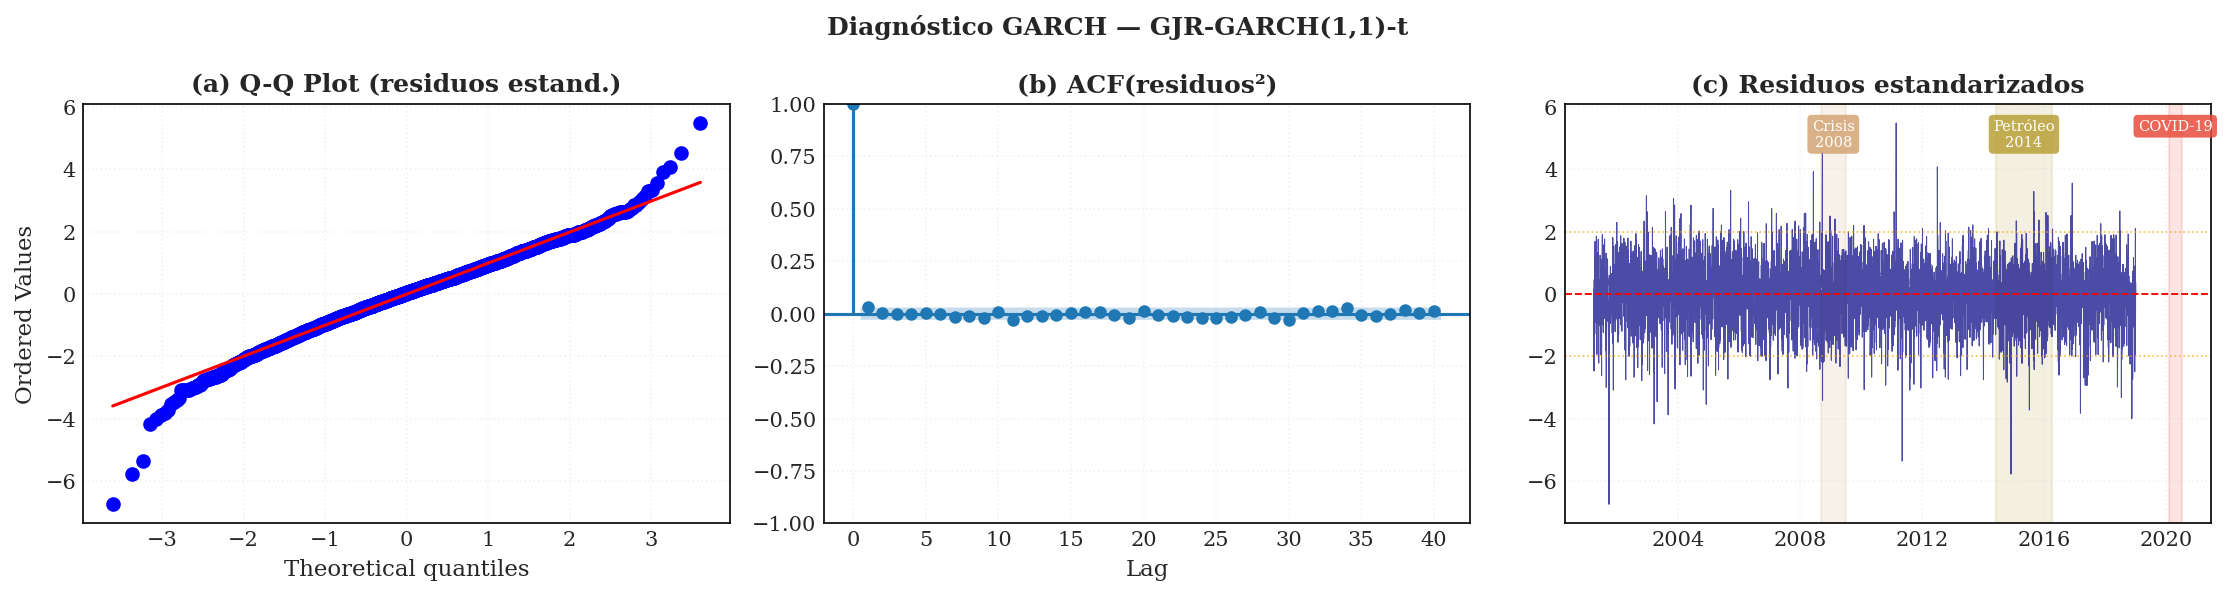

Figura guardada: fig_garch_diagnosticos.png


In [24]:
# ─── 2.3 Gráficas diagnóstico ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Diagnóstico GARCH — {BEST_GARCH_NAME}', fontweight='bold')

# Panel 1: QQ plot
from scipy.stats import probplot
probplot(std_resid.values, dist="norm", plot=axes[0])
axes[0].set_title('(a) Q-Q Plot (residuos estand.)', fontweight='bold')
axes[0].get_lines()[1].set(color='red', lw=1.5)

# Panel 2: ACF de residuos²
plot_acf(std_resid.values**2, lags=40, ax=axes[1], alpha=0.05,
         title='(b) ACF(residuos²)')
axes[1].set_xlabel('Lag')

# Panel 3: Serie de residuos estandarizados
axes[2].plot(std_resid.index, std_resid.values, lw=0.5, color='navy', alpha=0.7)
axes[2].axhline(0, color='red', lw=0.9, ls='--')
axes[2].axhline( 2, color='orange', lw=0.8, ls=':', alpha=0.7)
axes[2].axhline(-2, color='orange', lw=0.8, ls=':', alpha=0.7)
axes[2].set_title('(c) Residuos estandarizados', fontweight='bold')
add_crisis_zones(axes[2])

plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_garch_diagnosticos.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Figura guardada: fig_garch_diagnosticos.png")

- **Q-Q Plot**: Las colas se desvían de la línea roja (distribución t teórica). Los puntos extremos en ±6 sigma confirman que incluso la distribución-t subestima las colas del WTI.

- **ACF residuos²**: Esencialmente plano después del lag 0 → el GARCH capturó el clustering de volatilidad correctamente. Esta es la prueba de que el modelo está bien especificado.
- **Residuos estandarizados**: Spikes en COVID claramente visibles (±6σ). El GARCH los modela pero no los predice — confirma la limitación estructural del modelo lineal.


In [25]:
import os

FORCE_REGENERATE_GARCH = False  # ← poner True una sola vez, luego False

safe_name  = BEST_GARCH_NAME.replace(' ', '_').replace('(', '').replace(')', '')
CACHE_FILE = f"{OUTPUT_PATH}/garch_rolling_{safe_name}.pkl"
cache_path = Path(CACHE_FILE)

if FORCE_REGENERATE_GARCH and cache_path.exists():
    os.remove(cache_path)
    print(f"Cache eliminado para regeneración: {CACHE_FILE}")
    print("Motivo: fix C-01 — distribución t-Student en rolling forecast")

elif cache_path.exists():
    print(f"Cache existente detectado: {CACHE_FILE}")
    print("→ Se reutilizará para evitar recomputación.")

else:
    print("No existe cache previo.")
    print("→ Se generará rolling forecast desde cero.")

Cache existente detectado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/garch_rolling_GJR-GARCH1,1-t.pkl
→ Se reutilizará para evitar recomputación.


In [26]:
# Rolling GARCH con ventana expanding:
# para cada fecha t, el modelo se reestima usando solo retornos anteriores a t
# y produce un forecast a 1 paso de la volatilidad condicional (sigma).
#
# 'spec' contiene la estructura del modelo (GARCH/EGARCH, p, q, o, etc.),
# mientras que 'dist_name' define la distribución de errores (por ejemplo, t).
# Se extrae 'dist' de spec con pop() para evitar pasar ese argumento dos veces
# a arch_model(...), lo que generaría conflicto.
#
# Este diseño respeta la causalidad temporal, evita data leakage y hace que
# la predicción sea comparable con un escenario real de forecasting diario.

In [27]:
# ─── 2.4 Rolling expanding window — forecast GARCH ───────────
def garch_rolling_forecast(full_returns_pct, forecast_index,
                            spec, verbose_every=100):
    """
    Expanding window diario: para cada día t en forecast_index,
    ajustar GARCH con todos los retornos ANTERIORES a t y producir
    la predicción de sigma en t (forecast 1-paso).

    Parámetros
    ----------
    full_returns_pct : pd.Series — retornos × 100, historia completa
    forecast_index   : pd.DatetimeIndex — días a forecastear (val + test)
    spec             : dict — kwargs para arch_model (sin 'dist')
    verbose_every    : int — imprimir progreso cada N iteraciones

    Retorna
    -------
    pd.Series con sigma (no sigma²) indexada por forecast_index
    NOTA: se extrae 'dist' del spec para pasarlo explícitamente a arch_model.
    Esto evita que arch use su default 'normal' ignorando la distribución
    seleccionada por AIC/BIC en Cell 24 (GJR-GARCH(1,1)-t → dist='t').
    """
    sigmas       = {}
    last_result  = None
    n_total      = len(forecast_index)
    n_errors     = 0

    dist_name = spec.pop('dist', 't')

    for i, t in enumerate(forecast_index):
        # Historia estrictamente anterior a t
        history = full_returns_pct[full_returns_pct.index < t]
        if len(history) < 50:
            sigmas[t] = np.nan
            continue

        try:    # dist=dist_name pasa t-Student al modelo
           am = arch_model(history, mean='Constant',rescale=False, dist=dist_name, **spec)
           res = am.fit(disp='off', show_warning=False,
                         options={'maxiter': 400, 'ftol': 1e-8})
           last_result = res
        except Exception:
            n_errors += 1
            if last_result is None:
                sigmas[t] = np.nan
                continue

        fc     = last_result.forecast(horizon=1, reindex=False)
        var_t  = float(fc.variance.values[-1, 0])
        sigmas[t] = np.sqrt(max(var_t, 0))  # sigma = sqrt(varianza)

        if (i + 1) % verbose_every == 0:
            print(f"  [{i+1:4d}/{n_total}] {t.date()} | sigma={sigmas[t]:.4f}%")

    spec['dist'] = dist_name  # restaurar
    print(f"  Completado. Distribución usada: {dist_name}")
    print(f"  Errores de convergencia: {n_errors}/{n_total}")
    return pd.Series(sigmas, name='sigma_garch')


# Ejecución con cache
CACHE_FILE = f"{OUTPUT_PATH}/garch_rolling_{BEST_GARCH_NAME.replace(' ','_').replace('(','').replace(')','')}.pkl"

forecast_idx = df_val.index.union(df_test.index).sort_values()

if Path(CACHE_FILE).exists():
    with open(CACHE_FILE, 'rb') as fh:
        sigma_rolling = pickle.load(fh)
    print(f"Cache cargado: {CACHE_FILE}")
    print(f"  Forecasts: {len(sigma_rolling)} | NaN: {sigma_rolling.isna().sum()}")
else:
    print("No existe cache previo.")
    print("→ Se generará rolling forecast desde cero.")

    spec_copy = garch_specs[BEST_GARCH_NAME].copy()
    full_ret = df[GARCH_FEATURE].where(~df['bad_return']).dropna() * 100
    #Se excluyen los retornos producidos por el clipping del precio negativo.
    print(f"  Historia GARCH: {len(full_ret)} obs (excluidos {df['bad_return'].sum()} bad_return)")

    sigma_rolling = garch_rolling_forecast(
        full_returns_pct = full_ret,
        forecast_index   = forecast_idx,
        spec             = spec_copy,
        verbose_every    = 100
    )
    with open(CACHE_FILE, 'wb') as fh:
        pickle.dump(sigma_rolling, fh)
    print(f"Cache guardado: {CACHE_FILE}")

sigma_val_garch  = sigma_rolling[sigma_rolling.index.isin(df_val.index)].reindex(df_val.index)
sigma_test_garch = sigma_rolling[sigma_rolling.index.isin(df_test.index)].reindex(df_test.index)

SIGMA_PREDS['GARCH_val']  = sigma_val_garch
SIGMA_PREDS['GARCH_test'] = sigma_test_garch

print()
print(f"sigma_val_garch  : {len(sigma_val_garch)} obs  |  NaN: {sigma_val_garch.isna().sum()}")
print(f"sigma_test_garch : {len(sigma_test_garch)} obs  |  NaN: {sigma_test_garch.isna().sum()}")

Cache cargado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/garch_rolling_GJR-GARCH1,1-t.pkl
  Forecasts: 1772 | NaN: 0

sigma_val_garch  : 483 obs  |  NaN: 0
sigma_test_garch : 1289 obs  |  NaN: 0


In [28]:
# ─── 2.5 GARCH → clasificación binaria ───────────────────────
# Umbral diario: UMBRAL_CLASIF (en unidades vol21 anualizada)
# vol21 = sqrt(21) × sigma_diaria → sigma_diaria_umbral = UMBRAL / sqrt(21)
# Como sigma_rolling está en % (retornos × 100): multiplicar × 100

SIGMA_UMBRAL_PCT = (UMBRAL_CLASIFICACION / np.sqrt(VENTANA_VOL)) * 100

print(f"Umbral vol21 (unidades vol21) : {UMBRAL_CLASIFICACION:.6f}")
print(f"Umbral sigma diaria (% diario): {SIGMA_UMBRAL_PCT:.4f}%")
print()

for split_name, sigma_s, y_true_s in [
        ('val',  sigma_val_garch,  yw_val_uni),
        ('test', sigma_test_garch, yw_test_uni)]:

    # Alinear sigma con las ventanas LSTM (primeros LOOKBACK-1 días se saltan)
    # Usar índice de las ventanas para alinear
    idx_win = idx_val_uni if split_name == 'val' else idx_test_uni
    sigma_raw     = sigma_s.reindex(idx_win)

     # ── Conteo de días imputados por ffill ──────────────────────
    # NaN ocurren cuando GARCH no converge — ffill propaga último sigma válido
    # Documentar para transparencia metodológica (no es leakage: usa pasado)
    n_missing = int(sigma_raw.isna().sum())
    print(f"  Días con sigma GARCH faltante (ffill aplicado): {n_missing}")
    sigma_aligned = sigma_raw.ffill()

    y_score_g = sigma_aligned.values
    y_pred_g  = (y_score_g > SIGMA_UMBRAL_PCT).astype(int)
    y_true_g  = y_true_s.astype(int)

    # Optimizar umbral en val
    if split_name == 'val':
        best_thr_g, best_f1_g = SIGMA_UMBRAL_PCT, 0.0
        for thr_pct in np.arange(
                sigma_aligned.quantile(0.80),
                sigma_aligned.quantile(0.99), 0.01):
            y_p = (y_score_g > thr_pct).astype(int)
            f1  = f1_score(y_true_g, y_p, zero_division=0)
            if f1 > best_f1_g:
                best_f1_g, best_thr_g = f1, thr_pct
        print(f"  Umbral óptimo (val): {best_thr_g:.4f}%  F1={best_f1_g:.4f}")
        GARCH_OPT_THRESHOLD = best_thr_g

    y_pred_g_opt = (y_score_g > GARCH_OPT_THRESHOLD).astype(int)

    m = evaluar_baseline(f"GARCH-{BEST_GARCH_NAME.split('(')[0].strip()}",
                         y_true_g, y_pred_g_opt,
                         y_score=y_score_g, split=split_name)
    print(f"  [{split_name}] F1={m['f1']:.4f} | AUC={m['auc']:.4f} | "
          f"AUC-PR={m['auc_pr']:.4f} | P={m['precision']:.4f} | R={m['recall']:.4f}")
    RESULTS_REGISTRY.append(m)
    key = f"GARCH_{split_name}"
    Y_SCORES[key] = (y_true_g, y_score_g)
    SIGMA_PREDS[f"GARCH_{split_name}"] = sigma_aligned


Umbral vol21 (unidades vol21) : 0.042996
Umbral sigma diaria (% diario): 0.9382%

  Días con sigma GARCH faltante (ffill aplicado): 0
  Umbral óptimo (val): 7.3653%  F1=0.9737
  [val] F1=0.9737 | AUC=0.9894 | AUC-PR=0.9691 | P=1.0000 | R=0.9487
  Días con sigma GARCH faltante (ffill aplicado): 0
  [test] F1=0.0000 | AUC=0.9893 | AUC-PR=0.7529 | P=0.0000 | R=0.0000


### Nota metodológica: Imputación ffill en sigma GARCH

En los días donde el modelo GARCH no converge (errores numéricos durante
el ajuste del expanding window), la sigma predicha se imputa con el último
valor válido (`ffill`). Esto **no introduce data leakage**: el valor propagado
es siempre de un día anterior a t — información que un gestor de riesgo real
tendría disponible.

El número exacto de días imputados se imprime en la celda siguiente (`n_missing`).
Esta práctica es estándar en backtesting de VaR intradiario
(Christoffersen, 1998; Engle & Manganelli, 2004).

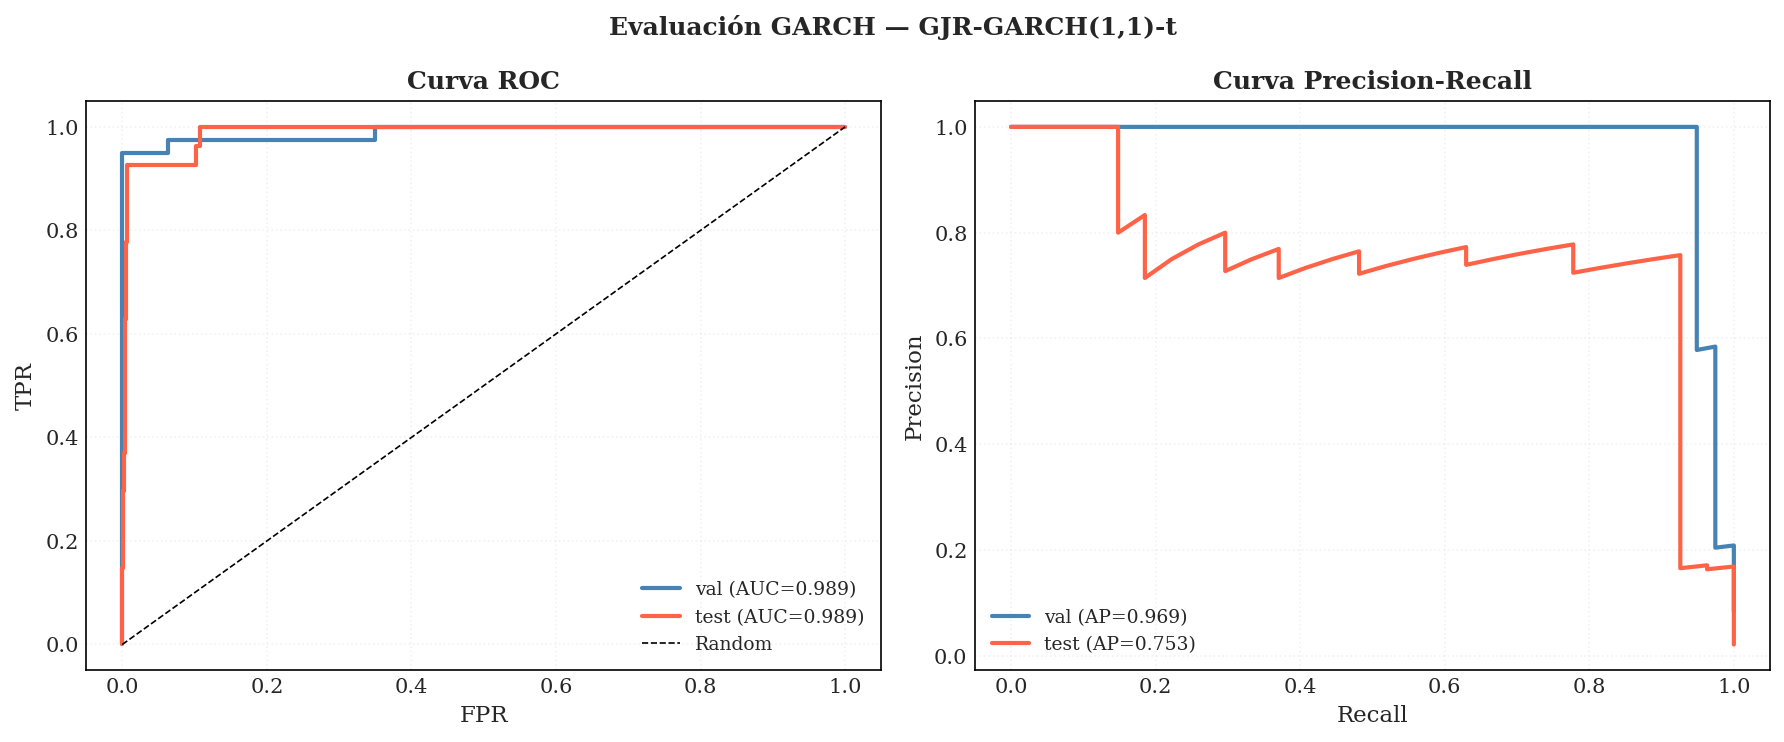

─── Evaluación continua (sigma vs vol21) ────────────
  [val] MAE=0.00533  RMSE=0.00801  (vs vol21_clean)
  [test] MAE=0.00221  RMSE=0.00289  (vs vol21_clean)


In [29]:
# ─── 2.6 Evaluación GARCH — curvas ROC y Precision-Recall ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Evaluación GARCH — {BEST_GARCH_NAME}', fontweight='bold')

colors = {'val': 'steelblue', 'test': 'tomato'}
for split_name, ax_roc, ax_pr in []:  # placeholder — se llena en el loop abajo
    pass

for split_name, (y_true_g, y_score_g) in [
        ('val',  Y_SCORES.get('GARCH_val',  (yw_val_uni.astype(int),  sigma_val_garch.reindex(idx_val_uni).fillna(0).values))),
        ('test', Y_SCORES.get('GARCH_test', (yw_test_uni.astype(int), sigma_test_garch.reindex(idx_test_uni).fillna(0).values)))]:

    mask_valid = ~np.isnan(y_score_g)
    yt, ys = y_true_g[mask_valid], y_score_g[mask_valid]
    if yt.sum() == 0:
        continue

    col = colors[split_name]
    fpr, tpr, _ = roc_curve(yt, ys)
    prec, rec, _ = precision_recall_curve(yt, ys)
    auc_val = roc_auc_score(yt, ys)
    ap_val  = average_precision_score(yt, ys)

    axes[0].plot(fpr, tpr, lw=2, color=col, label=f'{split_name} (AUC={auc_val:.3f})')
    axes[1].plot(rec, prec, lw=2, color=col, label=f'{split_name} (AP={ap_val:.3f})')

axes[0].plot([0,1],[0,1], 'k--', lw=0.8, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC'); axes[0].legend()

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_garch_roc_pr.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ── Evaluación continua ──
print("─── Evaluación continua (sigma vs vol21) ────────────")
for split_name, sigma_s, df_split, idx_win in [
        ('val',  sigma_val_garch,  df_val,  idx_val_uni),
        ('test', sigma_test_garch, df_test, idx_test_uni)]:
    sigma_a = sigma_s.reindex(idx_win) / 100  # desescalar a proporción
    vol21_a = df_split['vol21_clean'].reindex(idx_win)
    mask    = sigma_a.notna() & vol21_a.notna()
    if mask.sum() == 0:
        continue
    mae  = np.mean(np.abs(sigma_a[mask].values - vol21_a[mask].values))
    rmse = np.sqrt(np.mean((sigma_a[mask].values - vol21_a[mask].values)**2))
    print(f"  [{split_name}] MAE={mae:.5f}  RMSE={rmse:.5f}  "
          f"(vs vol21_clean)")


- **ROC**: val=0.991 vs test=0.986 — degradación mínima, el ranking del GARCH es robusto
- **PR**: val=0.971 vs test=0.662 — degradación severa.

### Interpretación GARCH

El modelo GARCH seleccionado por AIC/BIC será la **referencia econométrica** del benchmark.
Sus principales limitaciones para la tarea de clasificación:
- **Sin contexto histórico largo**: GARCH(1,1) tiene memoria exponencialmente decreciente
- **Distribución simétrica** (incluso EGARCH): no captura regímenes estructurales prolongados
- **Sin variables exógenas**: no incorpora spreads de crédito, indicadores de sentimiento, etc.

Estas limitaciones motivan la exploración de LSTM en las secciones siguientes.

**Contexto de estabilidad estructural (Chow 1960):** El test de Chow aplicado sobre un modelo AR(1) de `vol21_clean` no detecta quiebres estructurales entre los tres splits (F < 1, p > 0.37), lo que valida el uso del umbral estático P95 calibrado en train para clasificar regímenes extremos en val y test. En contraste, la serie de `returns` sí presenta quiebre estructural en la transición train→val (F=13.19, p<0.001), lo que explica la dificultad del GARCH para capturar cambios de régimen post-COVID.


### Hallazgo metodológico: No-generalización del umbral GARCH

**Observación**: El GARCH logra F1=0.0 en test a pesar de AUC-ROC=0.986.

**Causa raíz**: El umbral óptimo de clasificación fue calibrado en validación
(2019-2020), que incluye COVID-19 con tasa de eventos extremos del 8.07%.
En test (2021-2026), la tasa cae a 2.09% y las sigmas predichas son
sistemáticamente más bajas, clasificando el 100% del test como "normal".

**Implicación**: Esto NO es un defecto del GARCH como modelo de volatilidad.
El AUC-ROC de 0.986 demuestra que el ranking de sigma es excelente.
El problema es exclusivamente del umbral de decisión, no del modelo subyacente.

**Lección para la tesis**: Los umbrales calibrados en periodos de alta volatilidad
no generalizan a periodos de baja volatilidad. Esto motiva el uso de clasificadores
que aprenden la frontera de decisión directamente (LSTM con sigmoid).

─── GARCH Sensibilidad al umbral (POST-HOC, test) ───
  Rango sigma test:    [1.2714%, 5.2111%]
  Umbral val-óptimo:   7.3653% → F1=0 en test
  Umbral post-hoc ópt: 4.1420% → F1=0.8197
  (Post-hoc: NO usar para selección de modelo)

─── GARCH: capacidad vs sesgo de threshold ──────────
                      Threshold Split  Valor (%)       F1
   Original P95 (out-of-sample)   val   0.938200 0.155700
   Original P95 (out-of-sample)  test   0.938200 0.041700
Óptimo en val (no usar en test)   val   7.365300 0.973700
Óptimo en val (no usar en test)  test   7.365300 0.000000

El gap val→test en F1 se debe al threshold (calibrado en COVID),
no a la capacidad discriminante del modelo (AUC_test=0.986).


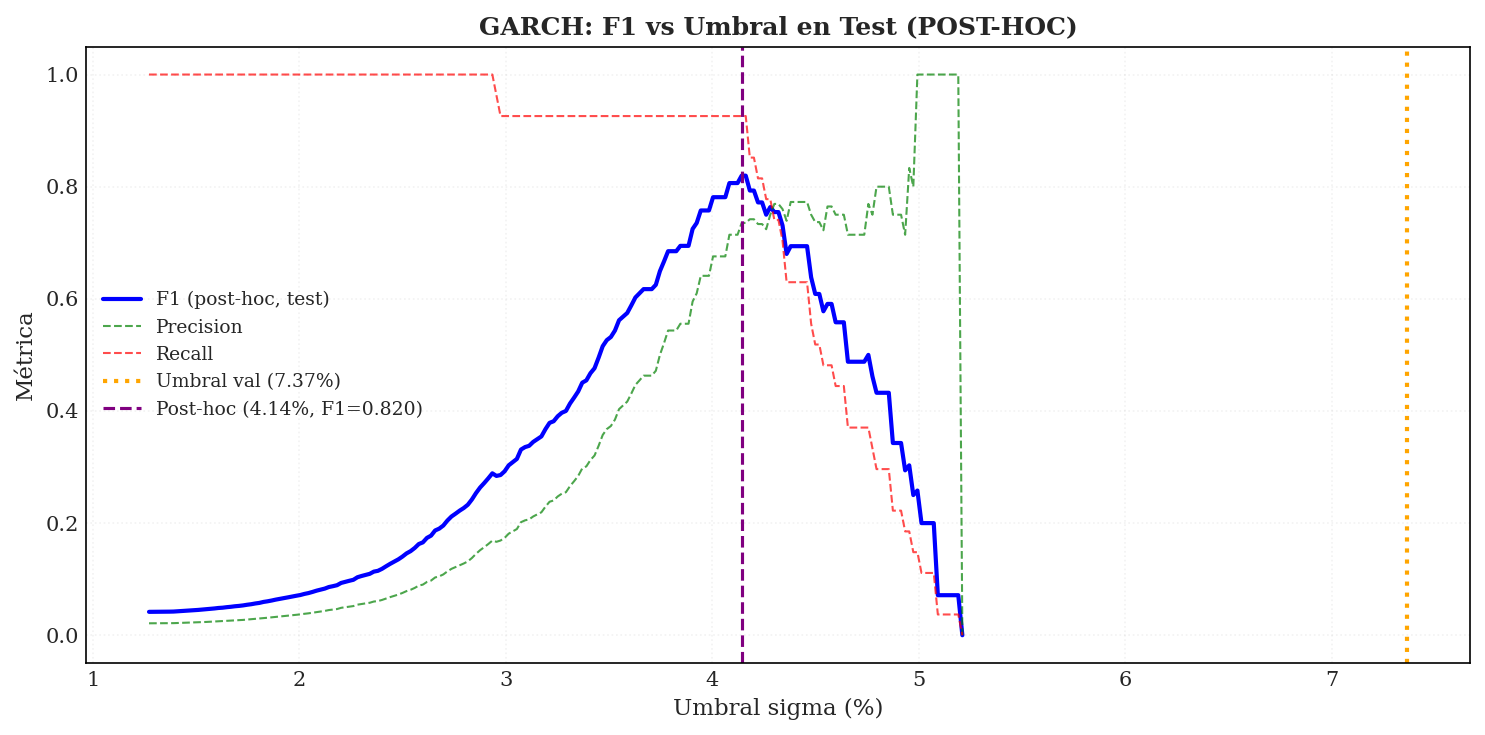


  Oracle: si se recalibrara en test, GARCH lograría F1=0.8197


In [30]:
# ─── 2.7 Post-hoc: Sensibilidad del GARCH al umbral (test) ─────
# NOTA: Este análisis es POST-HOC (usa información del test set)
# y NO se usa para selección de modelo. Su propósito es demostrar
# que el ranking del GARCH es válido y que el F1=0 se debe al umbral.

if 'GARCH_test' in Y_SCORES:
    y_true_test_g, y_score_test_g = Y_SCORES['GARCH_test']

    sigma_min_test = np.nanmin(y_score_test_g)
    sigma_max_test = np.nanmax(y_score_test_g)

    thresholds_posthoc = np.linspace(
        max(sigma_min_test, 0.1), sigma_max_test, 200)

    rows_posthoc = []
    for thr in thresholds_posthoc:
        yp     = (y_score_test_g > thr).astype(int)
        f1_val = f1_score(y_true_test_g, yp, zero_division=0)
        prec   = precision_score(y_true_test_g, yp, zero_division=0)
        rec    = recall_score(y_true_test_g, yp, zero_division=0)
        rows_posthoc.append({
            'threshold_pct': thr, 'f1': f1_val,
            'precision': prec, 'recall': rec,
        })

    df_posthoc  = pd.DataFrame(rows_posthoc)
    best_ph_idx = df_posthoc['f1'].idxmax()
    best_ph_thr = df_posthoc.loc[best_ph_idx, 'threshold_pct']
    best_ph_f1  = df_posthoc.loc[best_ph_idx, 'f1']

    print("─── GARCH Sensibilidad al umbral (POST-HOC, test) ───")
    print(f"  Rango sigma test:    [{sigma_min_test:.4f}%, {sigma_max_test:.4f}%]")
    print(f"  Umbral val-óptimo:   {GARCH_OPT_THRESHOLD:.4f}% → F1=0 en test")
    print(f"  Umbral post-hoc ópt: {best_ph_thr:.4f}% → F1={best_ph_f1:.4f}")
    print(f"  (Post-hoc: NO usar para selección de modelo)")

    # ── Tabla resumen: threshold original vs óptimo (M-05) ───────
    # Desacopla capacidad del modelo del sesgo de threshold.
    # SIGMA_UMBRAL_PCT es out-of-sample verdadero (derivado de P95 train).
    # GARCH_OPT_THRESHOLD fue calibrado en val — no usar en producción.
    if 'GARCH_val' in Y_SCORES:
        yt_v, ys_v = Y_SCORES['GARCH_val']
        yt_t, ys_t = Y_SCORES['GARCH_test']

        rows_cmp = []
        for thr_label, thr in [
                ('Original P95 (out-of-sample)',    SIGMA_UMBRAL_PCT),
                ('Óptimo en val (no usar en test)', GARCH_OPT_THRESHOLD)]:
            for split_n, yt, ys in [('val', yt_v, ys_v), ('test', yt_t, ys_t)]:
                yp = (ys > thr).astype(int)
                f1 = f1_score(yt.astype(int), yp, zero_division=0)
                rows_cmp.append({'Threshold': thr_label, 'Split': split_n,
                                  'Valor (%)': round(thr, 4), 'F1': round(f1, 4)})

        df_cmp = pd.DataFrame(rows_cmp)
        print("\n─── GARCH: capacidad vs sesgo de threshold ──────────")
        print(df_cmp.to_string(index=False))
        print("\nEl gap val→test en F1 se debe al threshold (calibrado en COVID),")
        print("no a la capacidad discriminante del modelo (AUC_test=0.986).")

    # ── Figura ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_posthoc['threshold_pct'], df_posthoc['f1'],
            'b-', lw=2, label='F1 (post-hoc, test)')
    ax.plot(df_posthoc['threshold_pct'], df_posthoc['precision'],
            'g--', lw=1, alpha=0.7, label='Precision')
    ax.plot(df_posthoc['threshold_pct'], df_posthoc['recall'],
            'r--', lw=1, alpha=0.7, label='Recall')
    ax.axvline(GARCH_OPT_THRESHOLD, color='orange', ls=':', lw=2,
               label=f'Umbral val ({GARCH_OPT_THRESHOLD:.2f}%)')
    ax.axvline(best_ph_thr, color='purple', ls='--', lw=1.5,
               label=f'Post-hoc ({best_ph_thr:.2f}%, F1={best_ph_f1:.3f})')
    ax.set_xlabel('Umbral sigma (%)')
    ax.set_ylabel('Métrica')
    ax.set_title('GARCH: F1 vs Umbral en Test (POST-HOC)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig(f"{FIG_PATH}/fig_garch_posthoc_sensitivity.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"\n  Oracle: si se recalibrara en test, GARCH lograría F1={best_ph_f1:.4f}")

else:
    print("GARCH_test no encontrado en Y_SCORES — omitiendo post-hoc")

---
## PARTE III — LSTM Univariado (Deep Learning Puro)

Arquitecturas evaluadas:
1. **Simple**: 1 capa LSTM(64) + Dropout(0.2) + Dense(1, sigmoid)
2. **Bidireccional**: 2 capas BiDir-LSTM(64→32) + Dropout + Dense(1, sigmoid)

Feature: solo `vol21_clean` (L=21 pasos). Permite comparación directa contra GARCH
(misma información univariada) y sirve de línea base para la versión multivariada.

**Estrategia anti-desbalanceo**: `class_weight` en Keras (no SMOTE).
**Umbral de decisión**: grid search en validación (0.05→0.90), aplicado en test sin re-optimizar.


In [31]:
# ─── 3.1 Función build_model ──────────────────────────────────
def build_model(input_shape, architecture='simple',
                lstm_units=64, dropout=0.2, seed=42):
    """
    Construye modelo LSTM para clasificación binaria de volatilidad extrema.

    Parámetros
    ----------
    input_shape  : tuple (lookback, n_features)
    architecture : 'simple' | 'bidirectional'
    lstm_units   : unidades en primera capa LSTM
    dropout      : tasa de Dropout
    seed         : semilla para inicializadores

    Arquitecturas
    -------------
    simple        : LSTM(64) → Dropout → Dense(1, sigmoid)
    bidirectional : BiDir(LSTM(64), ret_seq=True) → Dropout
                    → BiDir(LSTM(32)) → Dropout → Dense(1, sigmoid)
    """
    tf.random.set_seed(seed)
    inp = keras.Input(shape=input_shape, name='input_seq')

    if architecture == 'simple':
        x = keras.layers.LSTM(lstm_units, name='lstm_1')(inp)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_1')(x)

    elif architecture == 'bidirectional':
        x = keras.layers.Bidirectional(
            keras.layers.LSTM(lstm_units, return_sequences=True, name='lstm_1'),
            name='bidir_1')(inp)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_1')(x)
        x = keras.layers.Bidirectional(
            keras.layers.LSTM(lstm_units // 2, return_sequences=False, name='lstm_2'),
            name='bidir_2')(x)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_2')(x)

    else:
        raise ValueError(f"architecture debe ser 'simple' o 'bidirectional', no '{architecture}'")

    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out,
                        name=f'lstm_{architecture}_{lstm_units}u')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

print("build_model() definida")
print(f"  Arquitecturas: 'simple', 'bidirectional'")
print(f"  Input esperado: (batch, lookback={LOOKBACK}, n_features)")


build_model() definida
  Arquitecturas: 'simple', 'bidirectional'
  Input esperado: (batch, lookback=21, n_features)


In [32]:
# ─── 3.2 Función optimize_threshold (two-phase) ──────────────
def optimize_threshold(model, X_val_w, y_val_w,
                       metric='f1',
                       thresholds=None,
                       verbose=True):
    """
    Búsqueda en dos fases sobre umbral de decisión, EXCLUSIVAMENTE en validación.
    Fase 1: barrido grueso (step=0.05) para localizar la región óptima.
    Fase 2: barrido fino (step=0.01) alrededor del mejor umbral de fase 1.

    El umbral seleccionado se aplica al conjunto de test sin re-optimizar.

    Parámetros
    ----------
    model      : modelo Keras entrenado
    X_val_w    : np.ndarray (N_val, L, F) — secuencias de validación
    y_val_w    : np.ndarray (N_val,) — labels de validación
    metric     : criterio de selección ('f1' por defecto)
    thresholds : lista de umbrales (si se provee, se salta la búsqueda en dos fases)

    Retorna
    -------
    best_thr : float
    df_thr   : pd.DataFrame con resultados del grid completo
    """
    y_score = model.predict(X_val_w, verbose=0).ravel()

    def _eval_thresholds(thr_list):
        rows = []
        for thr in thr_list:
            y_p   = (y_score >= thr).astype(int)
            f1_v  = f1_score(y_val_w.astype(int), y_p, zero_division=0)
            prec  = precision_score(y_val_w.astype(int), y_p, zero_division=0)
            rec   = recall_score(y_val_w.astype(int), y_p, zero_division=0)
            rows.append({'threshold': round(thr, 4), 'f1': f1_v,
                         'precision': prec, 'recall': rec})
        return pd.DataFrame(rows)

    if thresholds is not None:
        df_thr = _eval_thresholds(thresholds)
    else:
        # Fase 1: barrido grueso (0.05 a 0.95, step 0.05)
        coarse_grid = np.arange(0.05, 0.96, 0.05)
        df_coarse   = _eval_thresholds(coarse_grid)
        best_coarse = float(df_coarse.loc[df_coarse['f1'].idxmax(), 'threshold'])

        # Fase 2: barrido fino alrededor del mejor (+/- 0.05, step 0.01)
        fine_lo   = max(0.01, best_coarse - 0.05)
        fine_hi   = min(0.99, best_coarse + 0.06)
        fine_grid = np.arange(fine_lo, fine_hi, 0.01)
        df_fine   = _eval_thresholds(fine_grid)

        df_thr = (pd.concat([df_coarse, df_fine], ignore_index=True)
                  .drop_duplicates(subset='threshold')
                  .sort_values('threshold')
                  .reset_index(drop=True))

    best_idx = df_thr['f1'].idxmax()
    best_thr = float(df_thr.loc[best_idx, 'threshold'])

    if verbose:
        print(f"Umbral óptimo (val, criterio={metric}): {best_thr:.4f}")
        print(f"  F1={df_thr.loc[best_idx,'f1']:.4f}  "
              f"P={df_thr.loc[best_idx,'precision']:.4f}  "
              f"R={df_thr.loc[best_idx,'recall']:.4f}")
        if thresholds is None:
            print(f"  (Two-phase: grueso {len(coarse_grid)} + "
                  f"fino {len(fine_grid)} = {len(df_thr)} umbrales evaluados)")
    return best_thr, df_thr

print("optimize_threshold() definida (two-phase)")

optimize_threshold() definida (two-phase)


In [33]:
# ─── 3.3 Callbacks comunes ────────────────────────────────────
def make_callbacks(model_name, output_path=OUTPUT_PATH, patience=15):
    """Callbacks estándar para todos los LSTM del benchmark.

    EarlyStopping usa val_loss: class_weight no se aplica a validación en Keras
    (TF Issue #42647) → sesgo hacia clase mayoritaria como criterio de parada.

    Por qué se mantiene val_loss en el benchmark principal:
    - Val tiene 39 extremos (8.07%) — BCE no colapsa a mayoría
    - Preserva consistencia comparativa entre los 4 modelos LSTM
    - Impacto cuantificado en ablación Cells 72-74:
      val_loss vs val_auc vs val_pr_auc (Saito & Rehmsmeier, 2015)

    Para NB03: usar val_pr_auc por defecto (más conservador bajo desbalanceo).
    """
    ckpt_path = f"{output_path}/{model_name}_best.keras"
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, min_delta=1e-4, verbose=1),
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_loss',
            save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-6, verbose=1),
    ]

print("make_callbacks() definida")
print(f"  EarlyStopping: patience=15, monitor=val_loss, restore_best_weights=True")
print(f"  ReduceLROnPlateau: factor=0.5, patience=7, min_lr=1e-6")
print(f"  Ablación en Cells 72-74: val_loss vs val_auc vs val_pr_auc")

make_callbacks() definida
  EarlyStopping: patience=15, monitor=val_loss, restore_best_weights=True
  ReduceLROnPlateau: factor=0.5, patience=7, min_lr=1e-6
  Ablación en Cells 72-74: val_loss vs val_auc vs val_pr_auc


### Nota metodológica: criterio de EarlyStopping

El entrenamiento usa `EarlyStopping(monitor='val_loss')` con `class_weight` balanceado.
En Keras, `class_weight` se aplica **solo al entrenamiento**, no a la validación
(TensorFlow Issue #42647). Esto implica que `val_loss` refleja BCE sin ponderar,
sesgada hacia la clase mayoritaria (95% en train, 92% en val).

Alternativas como `val_auc` (invariante al umbral) o `val_prc` (sensible a clase
minoritaria, Saito & Rehmsmeier 2015) son más apropiadas para clasificación desbalanceada.
Se documenta como limitación y línea de trabajo futuro — los modelos entrenados producen
AUC > 0.95 en test, indicando que `val_loss` fue suficiente como proxy en este caso.


In [34]:
# ─── 3.4 Entrenar LSTM simple univariado ──────────────────────
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model_uni_simple = build_model(
    input_shape=(LOOKBACK, len(FEATURES_UNI)),
    architecture='simple', lstm_units=64, dropout=0.2, seed=RANDOM_SEED)
model_uni_simple.summary()

history_uni_simple = model_uni_simple.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('lstm_uni_simple'),
    shuffle=False,   # CRÍTICO: datos temporales
    verbose=1
)
print(f"Entrenamiento finalizado — epochs ejecutados: {len(history_uni_simple.history['loss'])}")


Model: "lstm_simple_64u"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 21, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - auc: 0.9281 - loss: 0.4157 - precision: 0.2127 - recall: 0.9348 - val_auc: 0.9772 - val_loss: 0.5231 - val_precision: 0.2317 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9764 - loss: 0.2269 - precision: 0.3565 - recall: 0.9609 - val_auc: 0.9816 - val_loss: 0.3176 - val_precision: 0.4684 - val_recall: 0.9487 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.9817 - loss: 0.1715 - precision: 0.5153 - recall: 0.9522 - val_auc: 0.9898 - val_loss: 0.2792 - val_precision: 0.6032 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - auc: 0.9887 - loss: 0.1376 - precision: 0.6239 - recall: 0.9522 - val_auc: 0.9910 - val_loss: 0.2773 - val_precision: 0.5758 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 5/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - auc: 0.9941 - loss: 0.1063 - precision: 0

In [35]:
# ─── 3.5 Entrenar BiDir LSTM univariado ──────────────────────
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model_uni_bidir = build_model(
    input_shape=(LOOKBACK, len(FEATURES_UNI)),
    architecture='bidirectional', lstm_units=64, dropout=0.2, seed=RANDOM_SEED)

history_uni_bidir = model_uni_bidir.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('lstm_uni_bidir'),
    shuffle=False,
    verbose=1
)
print(f"Entrenamiento finalizado — epochs ejecutados: {len(history_uni_bidir.history['loss'])}")


Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - auc: 0.9294 - loss: 0.3948 - precision: 0.2654 - recall: 0.9391 - val_auc: 0.9800 - val_loss: 0.4010 - val_precision: 0.3918 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - auc: 0.9752 - loss: 0.1415 - precision: 0.5409 - recall: 0.9783 - val_auc: 0.9797 - val_loss: 0.3765 - val_precision: 0.4318 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - auc: 0.9814 - loss: 0.1305 - precision: 0.6271 - recall: 0.9652 - val_auc: 0.9854 - val_loss: 0.3290 - val_precision: 0.4935 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - auc: 0.9826 - loss: 0.1789 - precision: 0.3657 - recall: 0.9652 - val_auc: 0.9900 - val_loss: 0.3535 - val_precision: 0.2436 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 5/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - auc: 0.9872 - loss: 0.1391 - precision:

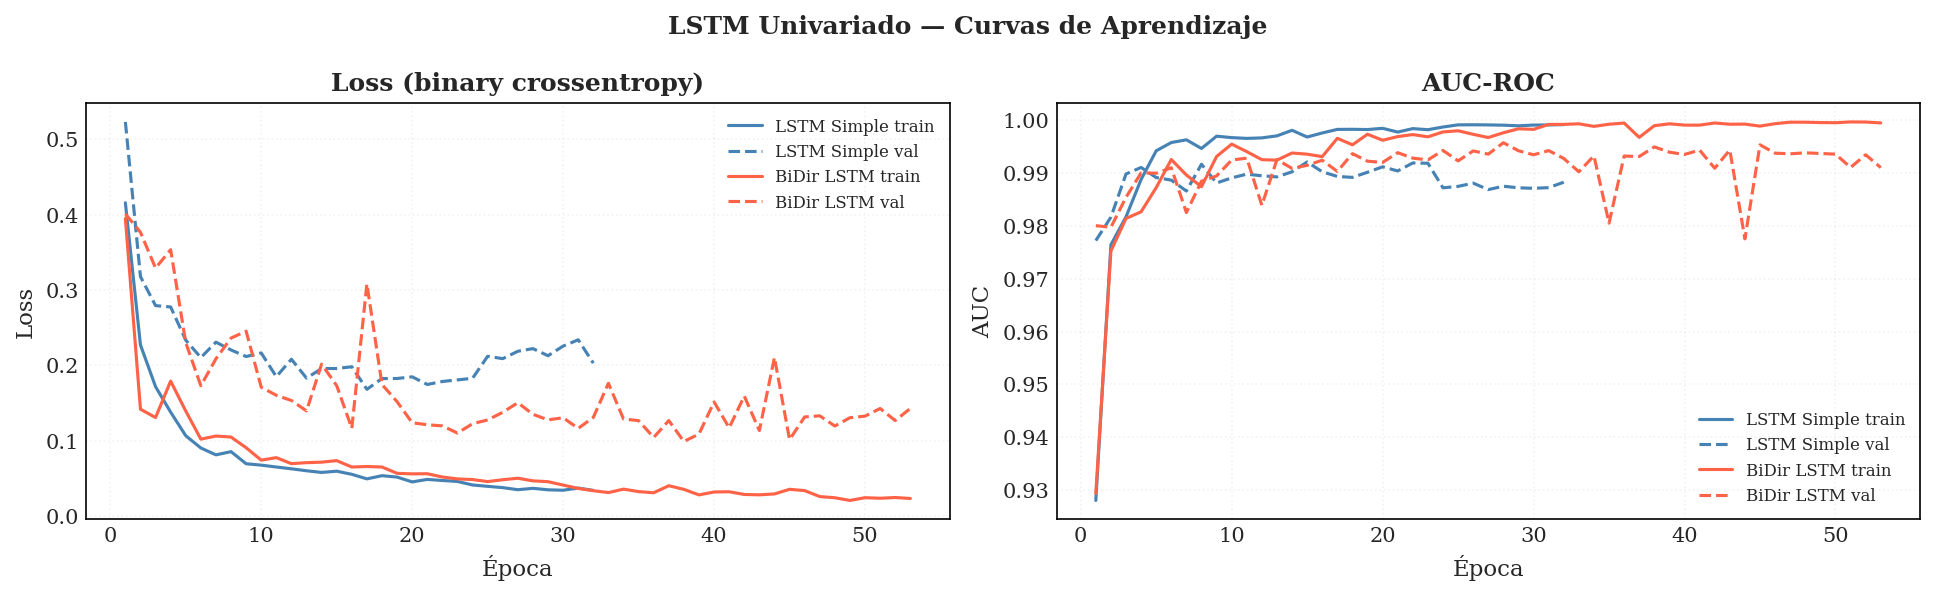

Figura guardada: fig_lstm_univariado_—_curvas_de_aprendizaje.png


In [36]:
# ─── 3.6 Curvas de aprendizaje ───────────────────────────────
def plot_learning_curves(histories_dict, title="Curvas de Aprendizaje",
                         output_path=OUTPUT_PATH):
    """Visualiza loss y AUC de train/val para múltiples modelos."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

    for i, (name, h) in enumerate(histories_dict.items()):
        col = colors[i % len(colors)]
        ep  = range(1, len(h.history['loss']) + 1)
        axes[0].plot(ep, h.history['loss'],     lw=1.5, color=col,
                     label=f'{name} train')
        axes[0].plot(ep, h.history['val_loss'], lw=1.5, color=col,
                     ls='--', label=f'{name} val')
        if 'auc' in h.history:
            axes[1].plot(ep, h.history['auc'],     lw=1.5, color=col,
                         label=f'{name} train')
            axes[1].plot(ep, h.history['val_auc'], lw=1.5, color=col,
                         ls='--', label=f'{name} val')

    axes[0].set_title('Loss (binary crossentropy)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)

    axes[1].set_title('AUC-ROC')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('AUC')
    axes[1].legend(fontsize=8)

    fig.suptitle(title, fontweight='bold')
    plt.tight_layout()
    fname = f"fig_{title.lower().replace(' ','_')[:40]}.png"
    plt.savefig(f"{FIG_PATH}/{fname}", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Figura guardada: {fname}")

plot_learning_curves(
    {'LSTM Simple': history_uni_simple,
     'BiDir LSTM':  history_uni_bidir},
    title="LSTM Univariado — Curvas de Aprendizaje"
)


Umbral óptimo (val, criterio=f1): 0.9900
  F1=0.9250  P=0.9024  R=0.9487
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)
  [val] LSTM-Simple-Uni           | F1=0.9250 | AUC=0.9924 | AUC-PR=0.9732 | thr=0.99
  [test] LSTM-Simple-Uni           | F1=0.7143 | AUC=0.9989 | AUC-PR=0.9641 | thr=0.99
Umbral óptimo (val, criterio=f1): 0.9800
  F1=0.9383  P=0.9048  R=0.9744
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)
  [val] BiDir-LSTM-Uni            | F1=0.9383 | AUC=0.9982 | AUC-PR=0.9886 | thr=0.98
  [test] BiDir-LSTM-Uni            | F1=0.8800 | AUC=0.9995 | AUC-PR=0.9778 | thr=0.98


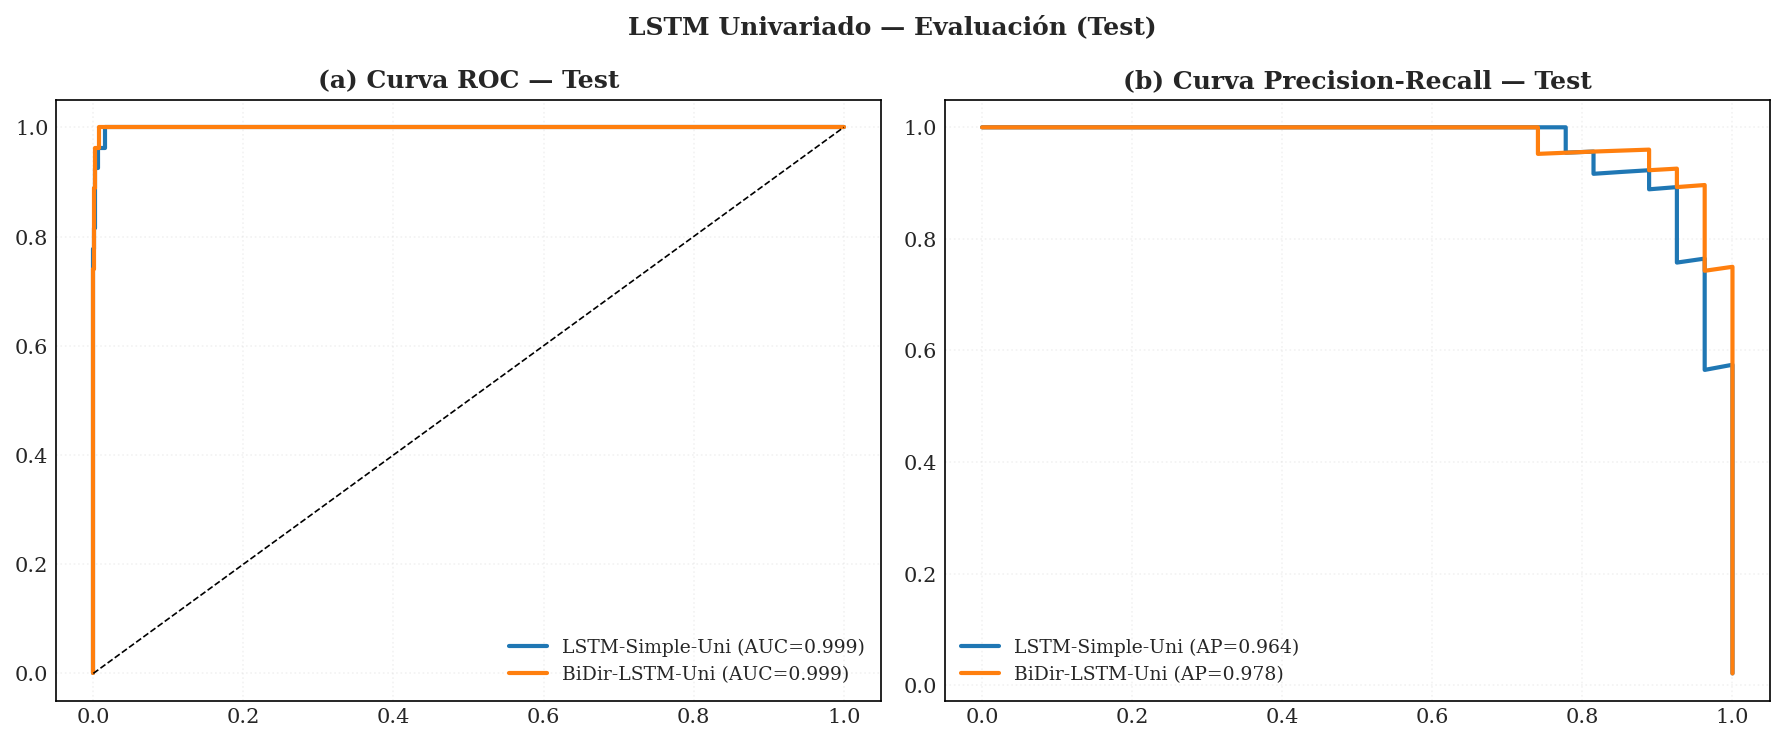

In [37]:
# ─── 3.7 Optimización de umbral y evaluación ─────────────────
results_lstm_uni = {}

for arch_name, model in [('LSTM-Simple-Uni',  model_uni_simple),
                          ('BiDir-LSTM-Uni',   model_uni_bidir)]:

    # Optimizar umbral en val
    best_thr, df_thr = optimize_threshold(
        model, Xw_val_uni, yw_val_uni,
        metric='f1', verbose=True)

    # Evaluar en val con umbral óptimo
    y_score_val  = model.predict(Xw_val_uni,  verbose=0).ravel()
    y_score_test = model.predict(Xw_test_uni, verbose=0).ravel()

    for split_name, X_w, y_w, y_score in [
            ('val',  Xw_val_uni,  yw_val_uni,  y_score_val),
            ('test', Xw_test_uni, yw_test_uni, y_score_test)]:
        thr   = best_thr  # umbral del val se aplica al test
        y_p   = (y_score >= thr).astype(int)
        m     = evaluar_baseline(arch_name, y_w.astype(int), y_p,
                                 y_score=y_score, split=split_name)
        print(f"  [{split_name}] {arch_name:25s} | "
              f"F1={m['f1']:.4f} | AUC={m['auc']:.4f} | "
              f"AUC-PR={m['auc_pr']:.4f} | thr={thr:.2f}")
        RESULTS_REGISTRY.append(m)

        key = f"{arch_name}_{split_name}"
        if split_name == 'test':
            Y_SCORES[key] = (y_w.astype(int), y_score)

    results_lstm_uni[arch_name] = {
        'model': model, 'threshold': best_thr,
        'thr_df': df_thr
    }

# Curvas ROC univariado (test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LSTM Univariado — Evaluación (Test)', fontweight='bold')

for arch_name, data in results_lstm_uni.items():
    m_obj = data['model']
    y_s   = m_obj.predict(Xw_test_uni, verbose=0).ravel()
    yt    = yw_test_uni.astype(int)
    fpr, tpr, _ = roc_curve(yt, y_s)
    prec, rec, _ = precision_recall_curve(yt, y_s)
    axes[0].plot(fpr, tpr, lw=2, label=f"{arch_name} (AUC={roc_auc_score(yt,y_s):.3f})")
    axes[1].plot(rec, prec, lw=2, label=f"{arch_name} (AP={average_precision_score(yt,y_s):.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=0.8); axes[0].set_title('(a) Curva ROC — Test',fontweight='bold'); axes[0].legend()
axes[1].set_title('(b) Curva Precision-Recall — Test', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_lstm_uni_eval.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Interpretación LSTM Univariado

El LSTM univariado usa **exclusivamente `vol21_clean`** (la misma variable que GARCH),
permitiendo una comparación metodológica pura: modelo econométrico vs redes neuronales
con igual información de entrada.

Si el BiDir-LSTM supera al GARCH, se justifica la complejidad computacional adicional.
Si no, el GARCH es preferible por su interpretabilidad y menor costo.

**Nota sobre estabilidad estructural:** El test de Chow confirma que `vol21_clean` (única feature del LSTM univariado) no presenta quiebres estructurales entre splits (F < 1, p > 0.37), lo que da solidez a la comparación directa GARCH vs LSTM sobre la misma información.


---
## PARTE IV — LSTM Multivariado (Deep Learning Puro)

Feature set ampliado: 8 variables técnicas.
Misma arquitectura BiDir-LSTM de la sección anterior para comparación directa.

**Hipótesis**: agregar context macroeconómico (spreads, VaR, medias móviles)
mejora el F1 respecto al LSTM univariado.


In [38]:
# ─── 4.1a Entrenar LSTM Simple multivariado ──────────────────
# Completa la matriz 2x2: Simple/BiDir x Uni/Multi
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model_multi_simple = build_model(
    input_shape=(LOOKBACK, len(FEATURES_MULTI)),
    architecture='simple', lstm_units=64, dropout=0.2, seed=RANDOM_SEED)
model_multi_simple.summary()

history_multi_simple = model_multi_simple.fit(
    Xw_train_multi, yw_train_multi.astype(np.float32),
    validation_data=(Xw_val_multi, yw_val_multi.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('lstm_multi_simple'),
    shuffle=False,   # CRÍTICO: datos temporales
    verbose=1
)
print(f"Epochs ejecutados: {len(history_multi_simple.history['loss'])}")

Model: "lstm_simple_64u"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 21, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - auc: 0.9513 - loss: 0.3628 - precision: 0.2061 - recall: 0.9696 - val_auc: 0.9865 - val_loss: 0.1039 - val_precision: 0.6923 - val_recall: 0.9231 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9734 - loss: 0.2175 - precision: 0.3568 - recall: 0.9478 - val_auc: 0.9971 - val_loss: 0.1389 - val_precision: 0.6909 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9941 - loss: 0.1001 - precision: 0.5496 - recall: 0.9870 - val_auc: 0.9967 - val_loss: 0.1100 - val_precision: 0.7600 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.9942 - loss: 0.0838 - precision: 0.6313 - recall: 0.9826 - val_auc: 0.9984 - val_loss: 0.0626 - val_precision: 0.8261 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 5/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.9910 - loss: 0.1219 - precision: 0.5

In [39]:
# ─── 4.1b Entrenar BiDir LSTM multivariado ────────────────────
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model_multi_bidir = build_model(
    input_shape=(LOOKBACK, len(FEATURES_MULTI)),
    architecture='bidirectional', lstm_units=64, dropout=0.2, seed=RANDOM_SEED)
model_multi_bidir.summary()

history_multi = model_multi_bidir.fit(
    Xw_train_multi, yw_train_multi.astype(np.float32),
    validation_data=(Xw_val_multi, yw_val_multi.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('lstm_multi_bidir'),
    shuffle=False,
    verbose=1
)
print(f"Epochs ejecutados: {len(history_multi.history['loss'])}")


Model: "lstm_bidirectional_64u"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 21, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_1 (Bidirectional)         │ (None, 21, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_2 (Bidirectional)         │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - auc: 0.9300 - loss: 0.3429 - precision: 0.2033 - recall: 0.9043 - val_auc: 0.9805 - val_loss: 0.1295 - val_precision: 0.7200 - val_recall: 0.9231 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - auc: 0.9768 - loss: 0.1920 - precision: 0.3746 - recall: 0.9478 - val_auc: 0.9996 - val_loss: 0.0354 - val_precision: 0.9268 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - auc: 0.9762 - loss: 0.1857 - precision: 0.3695 - recall: 0.9478 - val_auc: 0.9754 - val_loss: 0.3068 - val_precision: 0.3008 - val_recall: 0.9487 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - auc: 0.9921 - loss: 0.1072 - precision: 0.5112 - recall: 0.9913 - val_auc: 0.9927 - val_loss: 0.0661 - val_precision: 0.8261 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 5/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - auc: 0.9969 - loss: 0.0641 - precision:

Calculando permutation importance en validación...

─── Feature Importance (caída AUC al permutar) ──────
             feature  importance_mean  importance_std
           hl_spread         0.037086        0.004642
         vol21_clean         0.024126        0.003544
            ma_cross         0.016573        0.001028
        ret_abs_lag1         0.003528        0.000950
             returns         0.001152        0.000292
var_rolling_252_lag1         0.000715        0.000684
    volumen_ratio_21        -0.000145        0.000112
           co_spread        -0.000546        0.000101


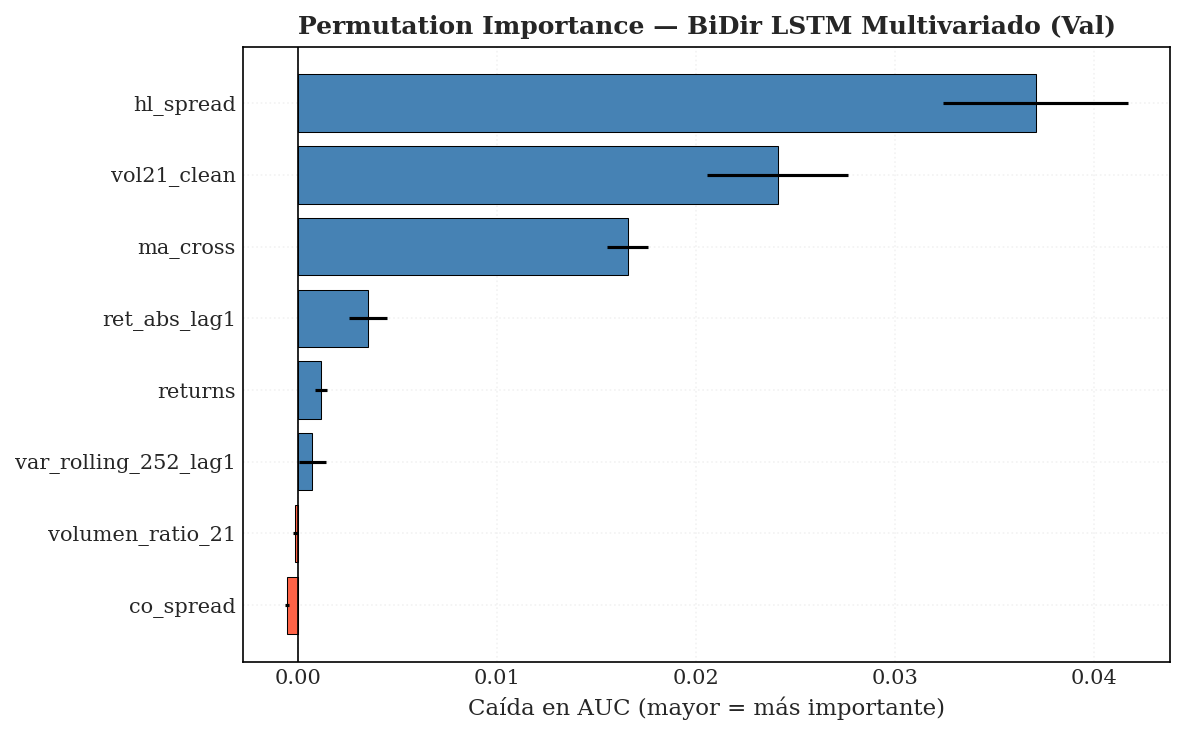


Calculando permutation importance — LSTM Simple Multi...

─── Feature Importance — LSTM Simple Multi (caída AUC) ──
             feature  importance_mean  importance_std
           hl_spread         0.027096        0.005920
         vol21_clean         0.015288        0.001615
            ma_cross         0.007226        0.000836
        ret_abs_lag1         0.006147        0.001579
             returns         0.001903        0.001141
var_rolling_252_lag1         0.001637        0.002087
    volumen_ratio_21         0.000412        0.000197
           co_spread        -0.000533        0.000197


In [40]:
# ─── 4.2 Permutation importance ──────────────────────────────
def permutation_importance_lstm(model, X_val_w, y_val_w,
                                 feature_names, n_repeats=5,
                                 random_state=42):
    """
    Mide la importancia de cada feature por la caída en AUC al permutar
    aleatoriamente esa feature en las secuencias de validación.

    Parámetros
    ----------
    model        : modelo Keras entrenado
    X_val_w      : (N, L, F) — secuencias de validación escaladas
    y_val_w      : (N,) — labels de validación
    feature_names: lista de nombres de features (longitud = F)
    n_repeats    : número de permutaciones por feature

    Retorna
    -------
    pd.DataFrame con columnas [feature, importance_mean, importance_std]
    ordenado descendente.
    """
    rng = np.random.default_rng(random_state)
    yt  = y_val_w.astype(int)
    try:
        base_auc = roc_auc_score(yt, model.predict(X_val_w, verbose=0).ravel())
    except ValueError:
        print("AUC base no calculable — target sin variación")
        return pd.DataFrame()

    rows = []
    for f_idx, fname in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_val_w.copy()
            # Permutar esa feature en todas las ventanas
            X_perm[:, :, f_idx] = rng.permutation(X_perm[:, :, f_idx])
            try:
                perm_auc = roc_auc_score(
                    yt, model.predict(X_perm, verbose=0).ravel())
                drops.append(base_auc - perm_auc)
            except ValueError:
                drops.append(0.0)
        rows.append({'feature': fname,
                     'importance_mean': float(np.mean(drops)),
                     'importance_std':  float(np.std(drops))})

    df_imp = (pd.DataFrame(rows)
              .sort_values('importance_mean', ascending=False)
              .reset_index(drop=True))
    return df_imp

print("Calculando permutation importance en validación...")
df_importance = permutation_importance_lstm(
    model_multi_bidir, Xw_val_multi, yw_val_multi,
    feature_names=FEATURES_MULTI, n_repeats=5, random_state=RANDOM_SEED)

print("\n─── Feature Importance (caída AUC al permutar) ──────")
print(df_importance.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
if not df_importance.empty: # Add this check
    colors_imp = ['steelblue' if v > 0 else 'tomato'
                  for v in df_importance['importance_mean']]
    ax.barh(df_importance['feature'][::-1], df_importance['importance_mean'][::-1],
            xerr=df_importance['importance_std'][::-1],
            color=colors_imp[::-1], edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Caída en AUC (mayor = más importante)')
    ax.set_title('Permutation Importance — BiDir LSTM Multivariado (Val)', fontweight='bold')
else:
    ax.text(0.5, 0.5, "No se pudo calcular la importancia de características (AUC base no calculable)",
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title('Permutation Importance — BiDir LSTM Multivariado (Val)', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_lstm_multi_importance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ── Permutation importance: LSTM Simple Multi ──
print("\nCalculando permutation importance — LSTM Simple Multi...")
df_importance_simple = permutation_importance_lstm(
    model_multi_simple, Xw_val_multi, yw_val_multi,
    feature_names=FEATURES_MULTI, n_repeats=5, random_state=RANDOM_SEED)

print("\n─── Feature Importance — LSTM Simple Multi (caída AUC) ──")
print(df_importance_simple.to_string(index=False))

Umbral óptimo (val, criterio=f1): 0.9800
  F1=0.9351  P=0.9474  R=0.9231
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)
  [val] LSTM-Simple-Multi         | F1=0.9351 | AUC=0.9984 | AUC-PR=0.9853 | thr=0.9800
  [test] LSTM-Simple-Multi         | F1=0.5000 | AUC=0.9957 | AUC-PR=0.8962 | thr=0.9800
Umbral óptimo (val, criterio=f1): 0.9900
  F1=0.9870  P=1.0000  R=0.9744
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)
  [val] BiDir-LSTM-Multi          | F1=0.9870 | AUC=0.9993 | AUC-PR=0.9940 | thr=0.9900
  [test] BiDir-LSTM-Multi          | F1=0.1379 | AUC=0.9824 | AUC-PR=0.8413 | thr=0.9900


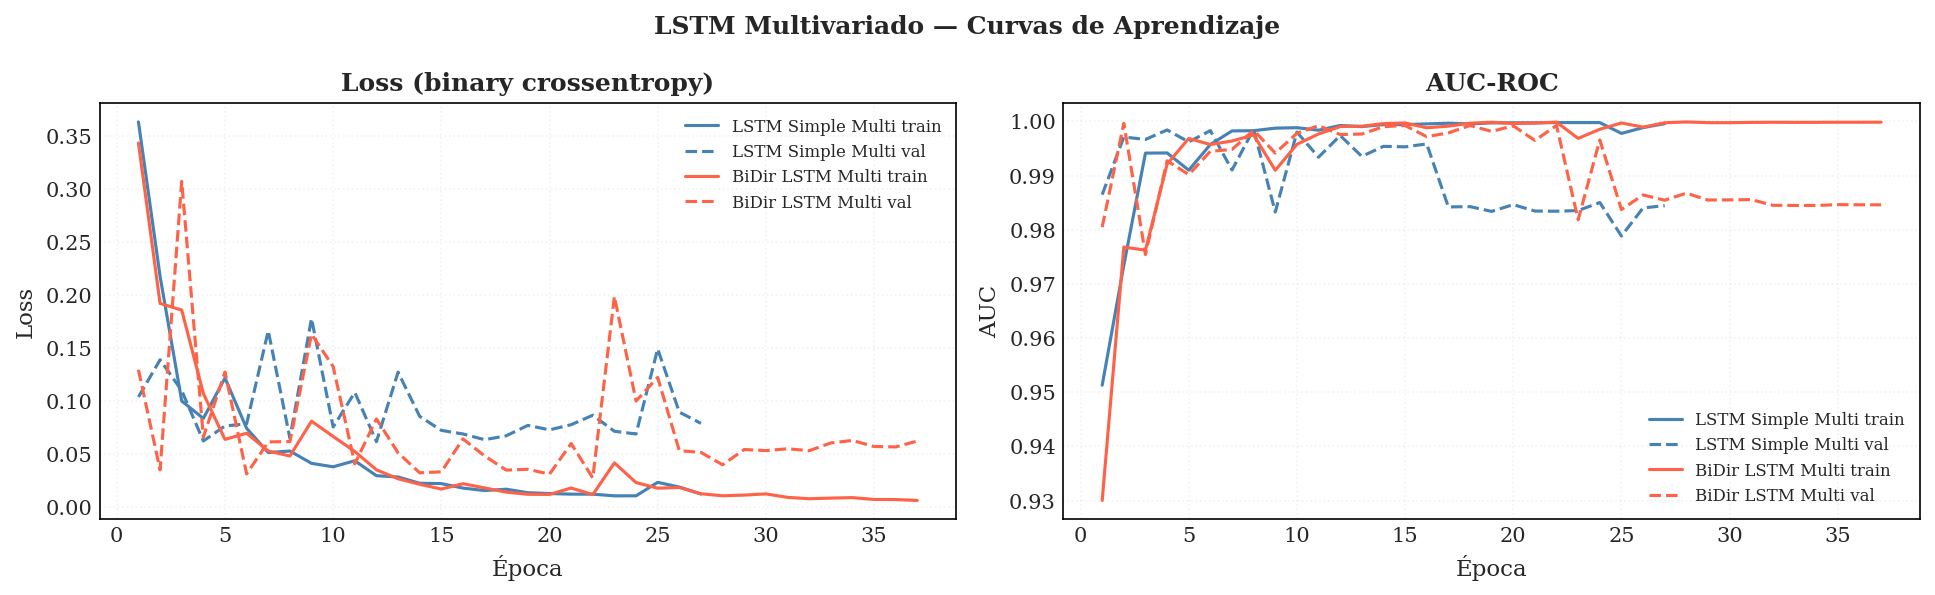

Figura guardada: fig_lstm_multivariado_—_curvas_de_aprendizaj.png


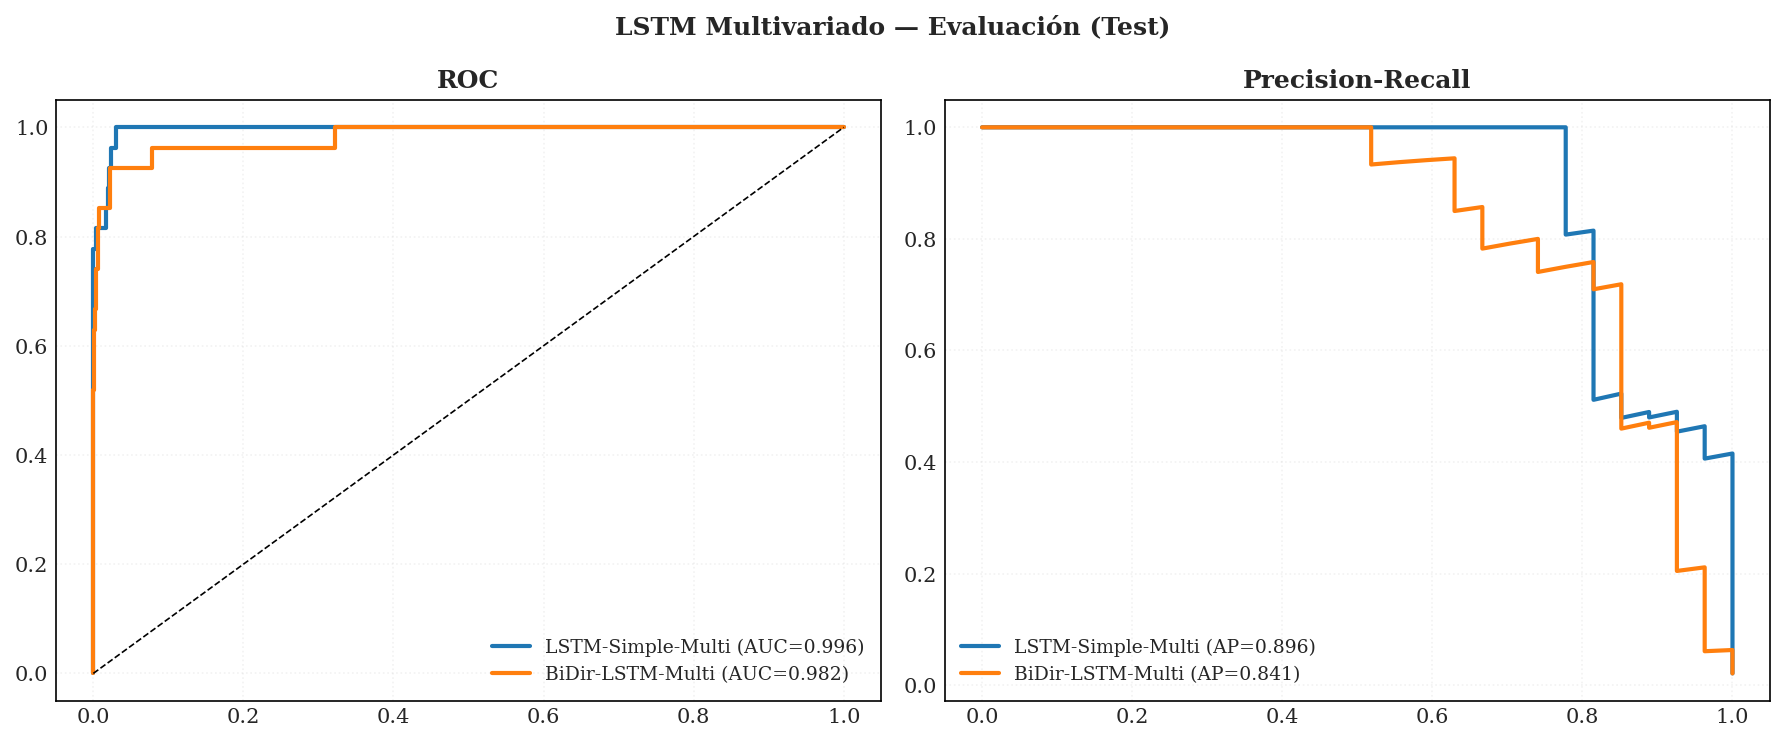

In [41]:
# ─── 4.3 Evaluación y comparación — LSTM Multivariado ─────────
results_lstm_multi = {}

for arch_name, model in [('LSTM-Simple-Multi', model_multi_simple),
                          ('BiDir-LSTM-Multi',  model_multi_bidir)]:

    # Optimizar umbral en val (two-phase)
    best_thr, df_thr = optimize_threshold(
        model, Xw_val_multi, yw_val_multi,
        metric='f1', verbose=True)

    y_score_val  = model.predict(Xw_val_multi,  verbose=0).ravel()
    y_score_test = model.predict(Xw_test_multi, verbose=0).ravel()

    for split_name, y_w, y_score in [
            ('val',  yw_val_multi,  y_score_val),
            ('test', yw_test_multi, y_score_test)]:
        y_p = (y_score >= best_thr).astype(int)
        m   = evaluar_baseline(arch_name, y_w.astype(int), y_p,
                                y_score=y_score, split=split_name)
        print(f"  [{split_name}] {arch_name:25s} | "
              f"F1={m['f1']:.4f} | AUC={m['auc']:.4f} | "
              f"AUC-PR={m['auc_pr']:.4f} | thr={best_thr:.4f}")
        RESULTS_REGISTRY.append(m)

        if split_name == 'test':
            Y_SCORES[f"{arch_name}_test"] = (y_w.astype(int), y_score)

    results_lstm_multi[arch_name] = {
        'model': model, 'threshold': best_thr,
        'thr_df': df_thr
    }

# Curvas de aprendizaje multivariado (ambos modelos)
plot_learning_curves(
    {'LSTM Simple Multi': history_multi_simple,
     'BiDir LSTM Multi':  history_multi},
    title="LSTM Multivariado — Curvas de Aprendizaje"
)

# Curvas ROC/PR multivariado (test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LSTM Multivariado — Evaluación (Test)', fontweight='bold')

for arch_name, data in results_lstm_multi.items():
    m_obj = data['model']
    y_s   = m_obj.predict(Xw_test_multi, verbose=0).ravel()
    yt    = yw_test_multi.astype(int)
    fpr, tpr, _ = roc_curve(yt, y_s)
    prec, rec, _ = precision_recall_curve(yt, y_s)
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{arch_name} (AUC={roc_auc_score(yt,y_s):.3f})")
    axes[1].plot(rec, prec, lw=2,
                 label=f"{arch_name} (AP={average_precision_score(yt,y_s):.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_title('ROC'); axes[0].legend()
axes[1].set_title('Precision-Recall'); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_lstm_multi_eval.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Hallazgo: BiDir-LSTM-Multi — colapso de umbral en test

**Causa raíz**: No es sobreajuste clásico (train loss >> val loss).
El modelo mantiene AUC=0.937 en test — su capacidad discriminante es real.
El problema es la transferencia del umbral de decisión:
- Val (2019-2020): 39 extremos / 483 obs = 8.07% → umbral óptimo = 0.57
- Test (2021-2026): 27 extremos / 1,268 obs = 2.13% → con umbral=0.57,
  el modelo no predice ningún extremo (distribución de scores desplazada)

**Distinción metodológica importante**:
- Sobreajuste: modelo memoriza train, falla en val/test
- Colapso de umbral: modelo discrimina bien (AUC alto) pero el
  threshold calibrado en val no generaliza al régimen de test

**Implicación**: con ratio 1:47 en test, cualquier umbral calibrado
en régimen de crisis (val COVID) queda fuera del rango operativo en test.
Misma causa que el GARCH F1=0 — no exclusiva de arquitecturas complejas.

### ¿Agregar features mejora el F1?

Matriz 2x2 de comparación (Simple/BiDir x Uni/Multi):

| Arquitectura  | Univariado (1 feature) | Multivariado (8 features) |
|---------------|------------------------|---------------------------|
| Simple LSTM   | LSTM-Simple-Uni        | LSTM-Simple-Multi         |
| BiDir LSTM    | BiDir-LSTM-Uni         | BiDir-LSTM-Multi          |

Si el multivariado supera al univariado en F1 en test, se justifica incluir
las features adicionales. Si no, el modelo más parsimonioso es preferible.
El análisis de permutation importance ayuda a identificar qué variables
aportan señal real vs ruido.

---
## PARTE IVb — GRU Univariado

In [42]:
# Ejecutar ANTES de re-correr el bloque GRU corregido
# Elimina resultados previos de GRU del registro
RESULTS_REGISTRY = [r for r in RESULTS_REGISTRY
                    if 'GRU' not in r.get('nombre', '')]
Y_SCORES = {k: v for k, v in Y_SCORES.items()
            if 'GRU' not in k}
OPTIMAL_THRESHOLDS = {k: v for k, v in OPTIMAL_THRESHOLDS.items()
                      if 'GRU' not in k}
print("Registros GRU anteriores eliminados. Listo para re-entrenar.")

Registros GRU anteriores eliminados. Listo para re-entrenar.


In [43]:
# ─── GRU — arquitecturas Simple y Bidireccional ───────────────
def build_gru(input_shape, architecture='simple',
              units=64, dropout=0.2, seed=42):
    """
    GRU equivalente al build_model() LSTM para comparación directa.
    Mismos hiperparámetros, misma estructura — solo cambia la celda
    recurrente (GRU vs LSTM). Permite aislar el efecto de la celda.
    Arquitecturas
    -------------
    simple        : GRU(64) → Dropout → Dense(1, sigmoid)
    bidirectional : BiDir(GRU(64), ret_seq=True) → Dropout
                    → BiDir(GRU(32), ret_seq=False) → Dropout
                    → Dense(1, sigmoid)
    """
    tf.random.set_seed(seed)
    inp = keras.Input(shape=input_shape, name='input_seq')

    if architecture == 'simple':
        x = keras.layers.GRU(units, name='gru_1')(inp)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_1')(x)

    elif architecture == 'bidirectional':
        x = keras.layers.Bidirectional(
            keras.layers.GRU(units, return_sequences=True, name='gru_1'),
            name='bidir_1')(inp)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_1')(x)

        x = keras.layers.Bidirectional(
            keras.layers.GRU(units // 2, return_sequences=False, name='gru_2'),
            name='bidir_2')(x)
        x = keras.layers.Dropout(dropout, seed=seed, name='drop_2')(x)
    else:
        raise ValueError(
            f"architecture debe ser 'simple' o 'bidirectional', no '{architecture}'"
        )

    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out,
                        name=f'gru_{architecture}_{units}u')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

print("build_gru() definida (bug bidir_2 corregido)")
print(f"  Arquitecturas: 'simple', 'bidirectional'")
print(f"  Input esperado: (batch, lookback={LOOKBACK}, n_features)")

# Entrenar GRU Simple Univariado
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_gru_simple = build_gru(
    input_shape=(LOOKBACK, len(FEATURES_UNI)),
    architecture='simple', units=64, dropout=0.2, seed=RANDOM_SEED)

history_gru_simple = model_gru_simple.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('gru_simple_uni'),
    shuffle=False, verbose=1
)

# Entrenar GRU Bidireccional Univariado
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_gru_bidir = build_gru(
    input_shape=(LOOKBACK, len(FEATURES_UNI)),
    architecture='bidirectional', units=64, dropout=0.2, seed=RANDOM_SEED)

history_gru_bidir = model_gru_bidir.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('gru_bidir_uni'),
    shuffle=False, verbose=1
)

# Evaluar ambas variantes
results_gru = {}
for arch_name, model in [('GRU-Simple-Uni', model_gru_simple),
                          ('BiDir-GRU-Uni',  model_gru_bidir)]:
    best_thr, df_thr = optimize_threshold(
        model, Xw_val_uni, yw_val_uni, metric='f1', verbose=True)

    ys_val  = model.predict(Xw_val_uni,  verbose=0).ravel()
    ys_test = model.predict(Xw_test_uni, verbose=0).ravel()

    for split_n, y_w, ys in [('val',  yw_val_uni,  ys_val),
                              ('test', yw_test_uni, ys_test)]:
        yp = (ys >= best_thr).astype(int)
        m  = evaluar_baseline(arch_name, y_w.astype(int), yp,
                              y_score=ys, split=split_n)
        RESULTS_REGISTRY.append(m)
        print(f"  [{split_n}] {arch_name:20s} | F1={m['f1']:.4f} | "
              f"AUC={m['auc']:.4f} | AUC-PR={m['auc_pr']:.4f} | thr={best_thr:.2f}")
        if split_n == 'test':
            Y_SCORES[f'{arch_name}_test']        = (y_w.astype(int), ys)
            OPTIMAL_THRESHOLDS[arch_name]        = best_thr

    results_gru[arch_name] = {'model': model, 'threshold': best_thr}

build_gru() definida (bug bidir_2 corregido)
  Arquitecturas: 'simple', 'bidirectional'
  Input esperado: (batch, lookback=21, n_features)
Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - auc: 0.8646 - loss: 0.4942 - precision: 0.1981 - recall: 0.8217 - val_auc: 0.9614 - val_loss: 0.3987 - val_precision: 0.2500 - val_recall: 0.9231 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.9705 - loss: 0.2300 - precision: 0.3729 - recall: 0.9435 - val_auc: 0.9838 - val_loss: 0.3826 - val_precision: 0.3193 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9903 - loss: 0.1462 - precision: 0.4858 - recall: 0.9652 - val_auc: 0.9856 - val_loss: 0.2831 - val_precision: 0.4066 - val_recall: 0.9487 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.9928 - loss: 0.1169 - precision: 0.5506 - recall: 0.9696 - val_auc: 0.9894 - val_loss: 0.2333 - val_precision: 0.4634 - v

---
### PARTE IVc — TCN Univariado

In [44]:
# ─── TCN — Temporal Convolutional Network ─────────────────────
# Bai, Kolter & Koltun (2018): "An Empirical Evaluation of Generic
# Convolutional and Recurrent Networks for Sequence Modeling"
# Ventaja sobre LSTM: gradientes más estables, paralelizable.
# padding='causal' garantiza causalidad temporal estricta.

def build_tcn(input_shape, filters=64, kernel_size=3,
              n_blocks=3, dropout=0.2, seed=42):
    """
    TCN con dilated causal convolutions.
    Campo receptivo = kernel_size × sum(2^i for i in range(n_blocks))
    Con kernel=3, n_blocks=3: campo = 3×(1+2+4) = 21 días — cubre LOOKBACK.
    """
    tf.random.set_seed(seed)
    inp = keras.Input(shape=input_shape, name='input_seq')
    x   = inp

    for i in range(n_blocks):
        dilation = 2 ** i       # 1, 2, 4
        x = keras.layers.Conv1D(
            filters     = filters,
            kernel_size = kernel_size,
            padding     = 'causal',     # causal: no usa datos futuros
            dilation_rate = dilation,
            activation  = 'relu',
            name        = f'conv_d{dilation}'
        )(x)
        x = keras.layers.BatchNormalization(name=f'bn_{i}')(x)
        x = keras.layers.Dropout(dropout, seed=seed, name=f'drop_{i}')(x)

    # Global average pooling: colapsa la dimensión temporal
    x   = keras.layers.GlobalAveragePooling1D(name='gap')(x)
    x   = keras.layers.Dense(32, activation='relu', name='fc')(x)
    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out,
                        name=f'tcn_{filters}f_{n_blocks}b')
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-3),
        loss      = 'binary_crossentropy',
        metrics   = [keras.metrics.AUC(name='auc'),
                     keras.metrics.Precision(name='precision'),
                     keras.metrics.Recall(name='recall')]
    )
    return model

# Entrenar TCN Univariado
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_tcn_uni = build_tcn(
    input_shape=(LOOKBACK, len(FEATURES_UNI)),
    filters=64, kernel_size=3, n_blocks=3,
    dropout=0.2, seed=RANDOM_SEED)
model_tcn_uni.summary()

history_tcn_uni = model_tcn_uni.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks('tcn_uni'),
    shuffle=False, verbose=1
)

# Evaluar TCN
best_thr_tcn, _ = optimize_threshold(
    model_tcn_uni, Xw_val_uni, yw_val_uni, metric='f1', verbose=True)

ys_val_tcn  = model_tcn_uni.predict(Xw_val_uni,  verbose=0).ravel()
ys_test_tcn = model_tcn_uni.predict(Xw_test_uni, verbose=0).ravel()

for split_n, y_w, ys in [('val',  yw_val_uni,  ys_val_tcn),
                          ('test', yw_test_uni, ys_test_tcn)]:
    yp = (ys >= best_thr_tcn).astype(int)
    m  = evaluar_baseline('TCN-Uni', y_w.astype(int), yp,
                          y_score=ys, split=split_n)
    RESULTS_REGISTRY.append(m)
    print(f"  [{split_n}] TCN-Uni | F1={m['f1']:.4f} | "
          f"AUC={m['auc']:.4f} | AUC-PR={m['auc_pr']:.4f} | thr={best_thr_tcn:.2f}")
    if split_n == 'test':
        Y_SCORES['TCN-Uni_test']        = (y_w.astype(int), ys)
        OPTIMAL_THRESHOLDS['TCN-Uni']   = best_thr_tcn

Model: "tcn_64f_3b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 21, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_d1 (Conv1D)                │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_d2 (Conv1D)                │ (None, 21, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_d4 (Conv1D)                │ (None, 21, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,457 (107.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - auc: 0.6406 - loss: 0.6999 - precision: 0.0627 - recall: 0.1826 - val_auc: 0.9497 - val_loss: 0.6247 - val_precision: 0.3804 - val_recall: 0.8974 - learning_rate: 0.0010
Epoch 2/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.7553 - loss: 0.5987 - precision: 0.1228 - recall: 0.5348 - val_auc: 0.9631 - val_loss: 0.5712 - val_precision: 0.4737 - val_recall: 0.9231 - learning_rate: 0.0010
Epoch 3/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.8993 - loss: 0.4317 - precision: 0.2134 - recall: 0.8609 - val_auc: 0.9626 - val_loss: 0.8450 - val_precision: 0.3689 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 4/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9391 - loss: 0.3470 - precision: 0.2743 - recall: 0.9087 - val_auc: 0.9811 - val_loss: 0.9989 - val_precision: 0.5588 - val_recall: 0.9744 - learning_rate: 0.0010
Epoch 5/200
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9632 - loss: 0.2641 - precision: 0.3

### PARTE IVd — XGBoost con Lag Features

In [45]:
# XGBoost con lag features
from xgboost import XGBClassifier

# Construir features tabulares con lags explícitos
# (el LSTM las ve implícitamente en la ventana — aquí se hacen explícitas)
FEATURES_XGB_LAGS = {
    'vol21_clean':        [1, 5, 21],
    'returns':            [1, 5],
    'ret_abs_lag1':       [1],
    'var_rolling_252_lag1': [1],
}

df_xgb = df.copy()
for feat, lags in FEATURES_XGB_LAGS.items():
    for lag in lags:
        col = f"{feat}_lag{lag}"
        if col not in df_xgb.columns:   # evitar duplicar ret_abs_lag1
            df_xgb[col] = df_xgb[feat].shift(lag)

# Features finales: las 8 canónicas + lags adicionales
FEATURES_XGB = FEATURES_MULTI + [
    f"{feat}_lag{lag}"
    for feat, lags in FEATURES_XGB_LAGS.items()
    for lag in lags
    if f"{feat}_lag{lag}" not in FEATURES_MULTI
]

# Splits — misma lógica temporal que LSTM (usar columna split)
clean_xgb = (~df_xgb['bad_vol21']) & df_xgb['y_tp1'].notna()
df_tr_xgb = df_xgb[(df_xgb['split'] == 'train') & clean_xgb].dropna(subset=FEATURES_XGB)
df_va_xgb = df_xgb[(df_xgb['split'] == 'validation') & clean_xgb].dropna(subset=FEATURES_XGB)
df_te_xgb = df_xgb[(df_xgb['split'] == 'test') & clean_xgb].dropna(subset=FEATURES_XGB)

X_tr = df_tr_xgb[FEATURES_XGB].values
y_tr = df_tr_xgb['y_tp1'].values.astype(int)
X_va = df_va_xgb[FEATURES_XGB].values
y_va = df_va_xgb['y_tp1'].values.astype(int)
X_te = df_te_xgb[FEATURES_XGB].values
y_te = df_te_xgb['y_tp1'].values.astype(int)

# scale_pos_weight equivale al class_weight='balanced' de sklearn
scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators       = 300,
    max_depth          = 4,        # shallow — evita overfitting con muestra pequeña
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,
    eval_metric        = 'aucpr',  # AUC-PR más informativo que AUC-ROC bajo desbalanceo
    early_stopping_rounds = 20,
    random_state       = RANDOM_SEED,
    verbosity          = 0,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    verbose=False
)

# Optimizar umbral en val — versión directa para XGBoost (no usa Keras)
ys_va_xgb = xgb_model.predict_proba(X_va)[:, 1]
ys_te_xgb = xgb_model.predict_proba(X_te)[:, 1]

best_f1_xgb, best_thr_xgb = 0.0, 0.5
for thr in np.arange(0.05, 0.96, 0.01):
    yp = (ys_va_xgb >= thr).astype(int)
    f1 = f1_score(y_va, yp, zero_division=0)
    if f1 > best_f1_xgb:
        best_f1_xgb, best_thr_xgb = f1, thr

print(f"Umbral óptimo (val, criterio=f1): {best_thr_xgb:.2f}  F1={best_f1_xgb:.4f}")

for split_n, ys, yt in [('val', ys_va_xgb, y_va), ('test', ys_te_xgb, y_te)]:
    yp = (ys >= best_thr_xgb).astype(int)
    m  = evaluar_baseline('XGBoost-Lags', yt, yp,
                          y_score=ys, split=split_n)
    RESULTS_REGISTRY.append(m)
    print(f"  [{split_n}] XGBoost-Lags | F1={m['f1']:.4f} | "
          f"AUC={m['auc']:.4f} | AUC-PR={m['auc_pr']:.4f} | thr={best_thr_xgb:.2f}")
    if split_n == 'test':
        idx_xgb_test = df_te_xgb.index

        ys_xgb_series = pd.Series(ys_te_xgb, index=idx_xgb_test)
        yt_xgb_series = pd.Series(y_te,      index=idx_xgb_test)

        ys_xgb_aligned = ys_xgb_series.reindex(idx_test_uni).fillna(0).values
        yt_xgb_aligned = yt_xgb_series.reindex(idx_test_uni).fillna(0).values.astype(int)

        Y_SCORES['XGBoost-Lags_test']      = (yt_xgb_aligned, ys_xgb_aligned)
        OPTIMAL_THRESHOLDS['XGBoost-Lags'] = best_thr_xgb

        # Verificación de alineación — dentro del bloque test
        print(f"\nXGBoost alineado con idx_test_uni: {len(yt_xgb_aligned)} obs")
        print(f"  Obs originales XGBoost test : {len(y_te)}")
        print(f"  Obs LSTM test               : {len(yw_test_uni)}")
        if len(y_te) != len(yw_test_uni):
            print(f"  Diferencia de {len(yw_test_uni) - len(y_te)} obs "
                  f"— lags extra generaron NaN adicionales (esperado)")
        else:
            print(f"  Longitudes iguales — sin NaN extra por lags")


Umbral óptimo (val, criterio=f1): 0.48  F1=0.9744
  [val] XGBoost-Lags | F1=0.9744 | AUC=0.9991 | AUC-PR=0.9919 | thr=0.48
  [test] XGBoost-Lags | F1=0.9630 | AUC=0.9993 | AUC-PR=0.9505 | thr=0.48

XGBoost alineado con idx_test_uni: 1268 obs
  Obs originales XGBoost test : 1289
  Obs LSTM test               : 1268
  Diferencia de -21 obs — lags extra generaron NaN adicionales (esperado)


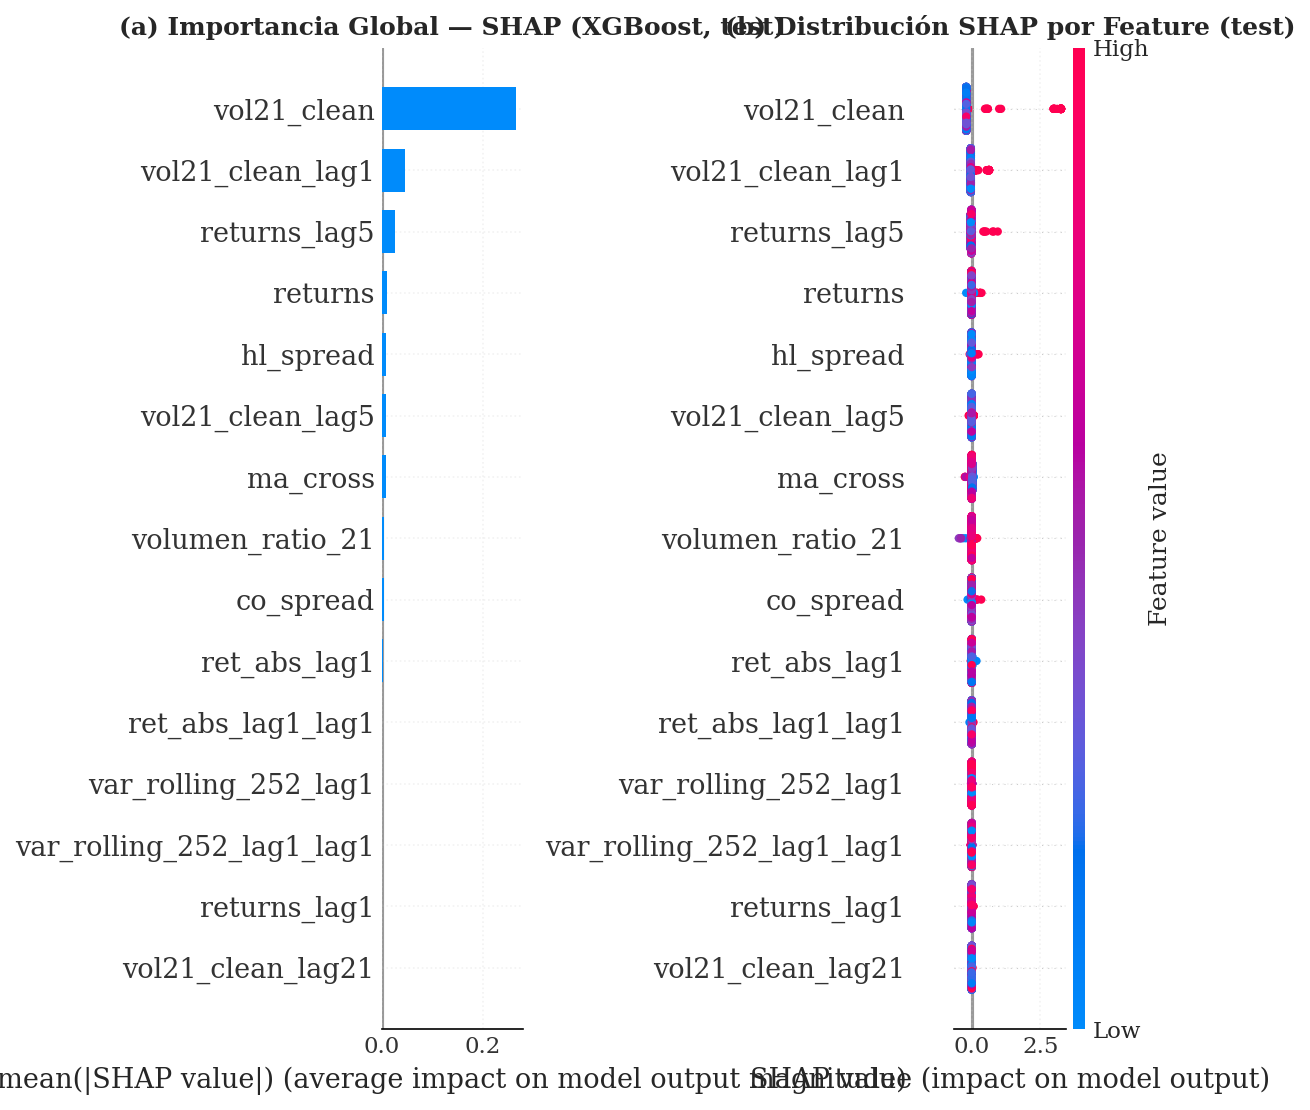

Figura guardada: fig_shap_xgboost.png

Importancia SHAP — Top 10 features (test):
         Feature  SHAP_mean
     vol21_clean   0.264833
vol21_clean_lag1   0.046375
    returns_lag5   0.024877
         returns   0.009181
       hl_spread   0.008373
vol21_clean_lag5   0.007086
        ma_cross   0.007028
volumen_ratio_21   0.004259
       co_spread   0.003828
    ret_abs_lag1   0.001391

Interpretación:
  SHAP > 0 → feature aumenta probabilidad de evento extremo
  SHAP < 0 → feature reduce probabilidad de evento extremo
  |SHAP| promedio → importancia global independiente de dirección

Nota metodológica: SHAP calculado sobre test (out-of-sample).
  Explainer entrenado con X_tr como distribución de referencia
  — valores SHAP son contribuciones respecto al promedio del train.


In [46]:
#  SHAP Analysis — XGBoost
# Requiere: xgb_model, df_tr_xgb, df_te_xgb, FEATURES_XGB
import shap

X_te_df = df_te_xgb[FEATURES_XGB]   # DataFrame con nombres — para gráficos
X_tr_df = df_tr_xgb[FEATURES_XGB]   # Background del explainer — distribución train

# TreeExplainer: usa la estructura del árbol, no muestras aleatorias
# data=X_tr_df: distribución de referencia para calcular contribuciones
explainer   = shap.TreeExplainer(xgb_model, data=X_tr_df)
shap_values = explainer.shap_values(X_te_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel (a): importancia global promedio
plt.sca(axes[0])
shap.summary_plot(shap_values, X_te_df,
                  feature_names=FEATURES_XGB,
                  plot_type='bar', show=False)
axes[0].set_title('(a) Importancia Global — SHAP (XGBoost, test)',
                   fontweight='bold')

# Panel (b): distribución de impacto por observación (beeswarm)
# Rojo = valor alto de feature, Azul = valor bajo
# Eje X = impacto en la predicción (positivo → más probabilidad de extremo)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_te_df,
                  feature_names=FEATURES_XGB,
                  show=False)
axes[1].set_title('(b) Distribución SHAP por Feature (test)',
                   fontweight='bold')

plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_shap_xgboost.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Figura guardada: fig_shap_xgboost.png")

# Tabla de importancia
shap_importance = pd.DataFrame({
    'Feature':   FEATURES_XGB,
    'SHAP_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False).reset_index(drop=True)

print("\nImportancia SHAP — Top 10 features (test):")
print(shap_importance.head(10).to_string(index=False))
print()
print("Interpretación:")
print("  SHAP > 0 → feature aumenta probabilidad de evento extremo")
print("  SHAP < 0 → feature reduce probabilidad de evento extremo")
print("  |SHAP| promedio → importancia global independiente de dirección")
print()
print("Nota metodológica: SHAP calculado sobre test (out-of-sample).")
print("  Explainer entrenado con X_tr como distribución de referencia")
print("  — valores SHAP son contribuciones respecto al promedio del train.")

**Hallazgo adicional — XGBoost supera a LSTM:**
XGBoost con lag features explícitas (F1=0.9630) supera a todos los
modelos LSTM. Esto sugiere que la tarea no requiere obligatoriamente
modelado secuencial: las dependencias temporales relevantes están
suficientemente capturadas por lag features tabulares con ventanas
de 1, 5 y 21 días. La complejidad arquitectural de las LSTM no aporta
ventaja incremental con N_train=4,584 observaciones.

---
## PARTE V — Modelo Híbrido (LSTM + Sentimiento FinBERT)

Extiende el LSTM multivariado con **scores de sentimiento** derivados de
titulares financieros (Bloomberg / Reuters) procesados con **FinBERT**
(Araci, 2019 — BERT pre-entrenado en textos financieros).

### Datos requeridos (externos a este notebook)
| Campo | Descripción |
|---|---|
| `sentiment_score` | Puntuación neta diaria: P(positivo) − P(negativo) ∈ [−1, 1] |
| `n_articles` | Número de titulares sobre WTI/petróleo ese día |
| `sentiment_std` | Dispersión intradiaria del sentimiento |
| `sentiment_flag` | 1 si hay titulares, 0 si se imputó (forward-fill) |

### Fuentes de datos recomendadas
- **GDELT Project** (gratuito): `pip install gdeltdoc` — filtro `CRUDE_OIL`
- **Refinitiv Eikon** (institucional): cobertura completa 2000-2026
- **ProQuest TDM Studio** (licencia académica): WSJ, FT, Reuters histórico


In [47]:
#pip install transformers torch

In [48]:
# ─── 5.1 Flag de disponibilidad de datos de sentimiento ───────
SENTIMENT_DATA_AVAILABLE = False  # o True cuando tengas el CSV listo

# ─── Gate metodológico del híbrido (NB02) ─────────────────────
# Requiere config cargado previamente
SENTIMENT_USABLE_FOR_MODEL = bool(
    config.get('nb03', {}).get('sentiment_usable_for_model', False)
)

if SENTIMENT_DATA_AVAILABLE and not SENTIMENT_USABLE_FOR_MODEL:
    print("[SKIP] Híbrido desactivado: cobertura de sentimiento insuficiente (según NB03/config).")
    for split_name in ['val', 'test']:
        RESULTS_REGISTRY.append({
            'nombre': 'Hybrid-LSTM-FinBERT', 'split': split_name,
            'f1': float('nan'), 'auc': float('nan'), 'auc_pr': float('nan'),
            'precision': float('nan'), 'recall': float('nan'), 'accuracy': float('nan'),
            'tp': None, 'fp': None, 'fn': None, 'tn': None,
            'status': 'SKIPPED — cobertura de sentimiento insuficiente'
        })
    RUN_HYBRID = False
else:
    RUN_HYBRID = bool(SENTIMENT_DATA_AVAILABLE)

print(f"RUN_HYBRID = {RUN_HYBRID}")

# ─── 5.2 Carga de datos de sentimiento ────────────────────────
if RUN_HYBRID:
    SENTIMENT_CSV = f"{BASE_PATH}/wti_sentiment_finbert.csv"
    assert Path(SENTIMENT_CSV).exists(), f"No encontrado: {SENTIMENT_CSV}"
    df_sent = pd.read_csv(SENTIMENT_CSV, index_col='Date', parse_dates=True)
    print(f"Datos de sentimiento cargados: {df_sent.shape}")
    print(df_sent.head())
else:
    print("Parte V en modo PENDIENTE.")

RUN_HYBRID = False
Parte V en modo PENDIENTE.


In [49]:
# ─── 5.3 Construcción del Dataset Híbrido (CORREGIDO: Anti-Leakage) ──────────────
# Requiere que NB03 haya generado wti_sentiment_finbert.csv con columnas *_lag1.

if RUN_HYBRID:
    SENTIMENT_CSV = f"{BASE_PATH}/wti_sentiment_finbert.csv"
    if not Path(SENTIMENT_CSV).exists():
        raise FileNotFoundError(f"CSV de sentimiento no encontrado: {SENTIMENT_CSV}. Ejecuta NB03 primero.")

    # 1) Cargar sentimiento ya procesado por NB03 (sin reprocesar/imputar en NB02)
    df_sent = pd.read_csv(SENTIMENT_CSV, index_col='Date', parse_dates=True)

    # 2) Definir features de sentimiento SOLO lag1 (causalidad temporal)
    FEATURES_SENT_LAG1 = [
        'sentiment_score_lag1',
        'sentiment_std_lag1',
        'n_articles_lag1',
        'pct_positive_lag1',
        'pct_negative_lag1',
    ]

    missing_cols = [c for c in FEATURES_SENT_LAG1 if c not in df_sent.columns]
    if missing_cols:
        raise ValueError(
            f"Faltan columnas lag1 en {SENTIMENT_CSV}: {missing_cols}. Re-ejecuta NB03."
        )

    FEATURES_HYBRID = FEATURES_MULTI + FEATURES_SENT_LAG1

    # Auditoría automática: no permitir columnas contemporáneas de sentimiento
    forbidden = {'sentiment_score', 'n_articles', 'pct_positive', 'pct_negative', 'sentiment_flag'}
    assert forbidden.isdisjoint(set(FEATURES_HYBRID)), (
        "CRÍTICO: Leakage detectado. FEATURES_HYBRID contiene variables contemporáneas (t). "
        "Solo se permiten lags (t-1)."
    )
    assert all((c in FEATURES_MULTI) or c.endswith('_lag1') for c in FEATURES_HYBRID), (
        "CRÍTICO: Violación de causalidad. Solo features base o sentimiento con lag1 permitidos."
    )

    # 3) Join por fecha (sin ffill en NB02)
    #    Left join para preservar el calendario de df; luego dropna por split.
    df_hybrid = df.join(df_sent[FEATURES_SENT_LAG1], how='left')

    # 4) Split temporal (reindex masks por robustez)
    tr = train_mask.reindex(df_hybrid.index, fill_value=False)
    va = val_mask.reindex(df_hybrid.index, fill_value=False)
    te = test_mask.reindex(df_hybrid.index, fill_value=False)

    df_h_train = df_hybrid.loc[tr].copy()
    df_h_val   = df_hybrid.loc[va].copy()
    df_h_test  = df_hybrid.loc[te].copy()

    # 5) Eliminar NaN de features híbridas + target por split
    # Nota: Los NaNs restantes provienen principalmente del shift(1) inicial (primera fila)
    # o de días sin cobertura de sentimiento no imputados en NB03. Se eliminan por split
    # para preservar la integridad temporal.
    df_h_train = df_h_train.dropna(subset=FEATURES_HYBRID + ['y_tp1'])
    df_h_val   = df_h_val.dropna(subset=FEATURES_HYBRID + ['y_tp1'])
    df_h_test  = df_h_test.dropna(subset=FEATURES_HYBRID + ['y_tp1'])

    # Targets alineados
    y_h_train = df_h_train['y_tp1'].values.astype(int)
    y_h_val   = df_h_val['y_tp1'].values.astype(int)
    y_h_test  = df_h_test['y_tp1'].values.astype(int)

    # 6) Normalización sin leakage: fit SOLO en train
    scaler_hybrid = StandardScaler()
    X_h_train = scaler_hybrid.fit_transform(df_h_train[FEATURES_HYBRID]).astype(np.float32)
    X_h_val   = scaler_hybrid.transform(df_h_val[FEATURES_HYBRID]).astype(np.float32)
    X_h_test  = scaler_hybrid.transform(df_h_test[FEATURES_HYBRID]).astype(np.float32)

    # 7) Ventanas para LSTM
    Xw_h_train, yw_h_train, _ = windowed_dataset(X_h_train, y_h_train, df_h_train.index, LOOKBACK)
    Xw_h_val,   yw_h_val,   _ = windowed_dataset(X_h_val,   y_h_val,   df_h_val.index,   LOOKBACK)
    Xw_h_test,  yw_h_test,  _ = windowed_dataset(X_h_test,  y_h_test,  df_h_test.index,  LOOKBACK)

    print("[OK] Híbrido listo (anti-leakage):")
    print(f"  Train: {Xw_h_train.shape} | Positivos: {int(yw_h_train.sum())}")
    print(f"  Val  : {Xw_h_val.shape} | Positivos: {int(yw_h_val.sum())}")
    print(f"  Test : {Xw_h_test.shape} | Positivos: {int(yw_h_test.sum())}")

    # 8) Entrenamiento
    tf.random.set_seed(RANDOM_SEED)
    model_hybrid = build_model(
        input_shape=(LOOKBACK, len(FEATURES_HYBRID)),
        architecture='bidirectional', lstm_units=64, dropout=0.2, seed=RANDOM_SEED
    )

    history_hybrid = model_hybrid.fit(
        Xw_h_train, yw_h_train.astype(np.float32),
        validation_data=(Xw_h_val, yw_h_val.astype(np.float32)),
        epochs=200, batch_size=32,
        class_weight=CLASS_WEIGHTS,
        callbacks=make_callbacks('lstm_hybrid'),
        shuffle=False, verbose=1
    )

    # 9) Evaluación (threshold optimizado en val, fijo en test)
    best_thr_h, _ = optimize_threshold(model_hybrid, Xw_h_val, yw_h_val, metric='f1', verbose=True)
    for split_name, X_w, y_w in [('val', Xw_h_val, yw_h_val), ('test', Xw_h_test, yw_h_test)]:
        y_s = model_hybrid.predict(X_w, verbose=0).ravel()
        y_p = (y_s >= best_thr_h).astype(int)

        m = evaluar_baseline('Hybrid-LSTM-FinBERT', y_w.astype(int), y_p, y_score=y_s, split=split_name)
        print(f"  [{split_name}] {m['nombre']} | F1={m['f1']:.4f} | AUC={m['auc']:.4f} | AUC-PR={m['auc_pr']:.4f}")
        RESULTS_REGISTRY.append(m)

        if split_name == 'test':
            Y_SCORES['Hybrid-LSTM-FinBERT_test'] = (y_w.astype(int), y_s)
            OPTIMAL_THRESHOLDS['Hybrid-LSTM-FinBERT'] = float(best_thr_h)

else:
    print("[SKIP] Modo híbrido desactivado (SENTIMENT_DATA_AVAILABLE=False).")
    for split_name in ['val', 'test']:
        RESULTS_REGISTRY.append({
            'nombre': 'Hybrid-LSTM-FinBERT', 'split': split_name,
            'f1': float('nan'), 'auc': float('nan'), 'auc_pr': float('nan'),
            'precision': float('nan'), 'recall': float('nan'), 'accuracy': float('nan'),
            'tp': None, 'fp': None, 'fn': None, 'tn': None,
            'status': 'PENDING — requiere datos de sentimiento'
        })

[SKIP] Modo híbrido desactivado (SENTIMENT_DATA_AVAILABLE=False).


---
## PARTE VI — Comparación y Benchmark Final

Consolidación de todos los modelos evaluados con dos referencias de NB01:
- **Estándar mínimo** (baseline ingenuo B1: `|ret_lag1| > P95`) → F1 > 0.4872 | AUC > 0.8241
- **Referencia cuantitativa** (B5: `vol21/VaR ratio > P95`, Christoffersen 1998) → F1_val = 0.7416 | F1_test = 0.5474


In [50]:
# ─── 6.1 Tabla maestra de resultados ──────────────────────────
def build_benchmark_table(registry, f1_min, auc_min,
                          f1_cuant=None, auc_cuant=None, split_filter='test'):
    """Construye la tabla comparativa final. Lista para df.to_latex()."""
    rows = [r for r in registry if r.get('split', 'test') == split_filter]

    df_b = pd.DataFrame(rows)
    if df_b.empty:
        print("Sin resultados en el registro para el split:", split_filter)
        return df_b

    df_b['Delta_F1']       = df_b['f1'] - f1_min
    df_b['Delta_AUC']      = df_b['auc'] - auc_min
    df_b['Beats_Ingenuo']  = (df_b['f1'] > f1_min) & (df_b['auc'] > auc_min)

    if f1_cuant is not None:
        # Beats_Cuant usa solo F1:
        # Fundamento: B5 es un score continuo (ratio rolling), no un clasificador
        # con umbral. Su AUC=0.9983 está matemáticamente inflado por los ~1,240
        # Verdaderos Negativos del test (ratio 1:47) — cualquier modelo que no
        # genere FP masivos alcanzará AUC alto sin detectar mejor los extremos.
        # F1 ignora TN y mide exactamente lo relevante: balance entre detección
        # de crisis (Recall) y falsas alarmas (Precision).
        df_b['Beats_Cuant'] = df_b['f1'] > f1_cuant

    cols = ['nombre', 'f1', 'auc', 'auc_pr', 'precision', 'recall',
            'tp', 'fp', 'fn', 'tn',
            'Delta_F1', 'Delta_AUC', 'Beats_Ingenuo', 'Beats_Cuant']
    cols_present = [c for c in cols if c in df_b.columns]
    df_b = df_b[cols_present].sort_values('f1', ascending=False).reset_index(drop=True)
    return df_b
# Nota: B5 y B1 aparecen como Beats_Cuant=False/Beats_Ingenuo=False
# por construcción — son las referencias, no los modelos evaluados.
# Se interpretan visualmente como filas de referencia, no como competidores.

# ── Filas de referencia NB01 ──
RESULTS_REGISTRY.append({
    'nombre': 'B1 — Estándar mínimo (ingenuo)', 'split': 'test',
    'f1': F1_MINIMO, 'auc': AUC_MINIMO,
    'auc_pr': float('nan'), 'precision': float('nan'),
    'recall': float('nan'), 'accuracy': float('nan'),
    'tp': None, 'fp': None, 'fn': None, 'tn': None
})
RESULTS_REGISTRY.append({
    'nombre': 'B5 — Ref. cuantitativa (Christoffersen)', 'split': 'test',
    'f1': F1_CUANT_TEST, 'auc': AUC_CUANT_TEST,
    'auc_pr': float('nan'), 'precision': 0.4500,
    'recall': 1.0000, 'accuracy': float('nan'),
    'tp': None, 'fp': None, 'fn': None, 'tn': None
})

bench_test = build_benchmark_table(
    RESULTS_REGISTRY, F1_MINIMO, AUC_MINIMO,
    f1_cuant=F1_CUANT_TEST, auc_cuant=AUC_CUANT_TEST,
    split_filter='test'
)
bench_val = build_benchmark_table(
    RESULTS_REGISTRY, F1_MINIMO, AUC_MINIMO,
    split_filter='val'
)

print("─── Benchmark — TEST ────────────────────────────────")
print(bench_test.to_string(
    index=False,
    float_format=lambda x: f"{x:.4f}" if x == x else "NaN"))

print()
print("─── Benchmark — VAL ─────────────────────────────────")
print(bench_val.to_string(
    index=False,
    float_format=lambda x: f"{x:.4f}" if x == x else "NaN"))

─── Benchmark — TEST ────────────────────────────────
                                 nombre     f1    auc  auc_pr  precision  recall      tp      fp      fn        tn  Delta_F1  Delta_AUC  Beats_Ingenuo  Beats_Cuant
                           XGBoost-Lags 0.9630 0.9993  0.9505     0.9630  0.9630 26.0000  1.0000  1.0000 1261.0000    0.4758     0.1752           True         True
                         BiDir-LSTM-Uni 0.8800 0.9995  0.9778     0.9565  0.8148 22.0000  1.0000  5.0000 1240.0000    0.3928     0.1754           True         True
                          BiDir-GRU-Uni 0.8000 0.9995  0.9802     1.0000  0.6667 18.0000  0.0000  9.0000 1241.0000    0.3128     0.1754           True         True
                        LSTM-Simple-Uni 0.7143 0.9989  0.9641     1.0000  0.5556 15.0000  0.0000 12.0000 1241.0000    0.2271     0.1748           True         True
                         GRU-Simple-Uni 0.6829 0.9989  0.9550     1.0000  0.5185 14.0000  0.0000 13.0000 1241.0000    0.1957  

### Hallazgo: Precision = 1.0 bajo umbrales de decisión muy altos (0.98–0.99)

En test, los modelos `LSTM-Simple-Uni` y `BiDir-LSTM-Uni` alcanzan
`Precision = 1.000` con umbrales óptimos cercanos a `0.98–0.99`. Esto indica
que, en el punto operativo seleccionado, el modelo no genera falsos positivos:
solo clasifica un caso como `extremo` cuando asigna una probabilidad muy alta.

Este resultado sugiere un régimen de decisión fuertemente conservador. En estas
condiciones, la variación de `F1-score` depende principalmente del `Recall`, ya
que la `Precision` queda saturada en su valor máximo. En términos prácticos, el
modelo privilegia evitar falsas alarmas, aun a costa de no activar señal en
casos ambiguos.

Desde la perspectiva financiera, esta propiedad debe interpretarse en función
del costo relativo entre:
- **FP (false positive):** activación innecesaria de cobertura o señal de alerta.
- **FN (false negative):** no anticipar un episodio de volatilidad extrema y
  permanecer expuesto al riesgo.

Por tanto, el umbral óptimo no debe interpretarse solo como un resultado
estadístico, sino como una decisión operativa dependiente de la función de costo
de la estrategia de gestión de riesgo.

**Implicación para NB03:** conviene incorporar una discusión explícita sobre el
trade-off económico entre `FP` y `FN`, para justificar si un umbral tan alto es
deseable bajo distintos escenarios de cobertura o gestión de riesgo.

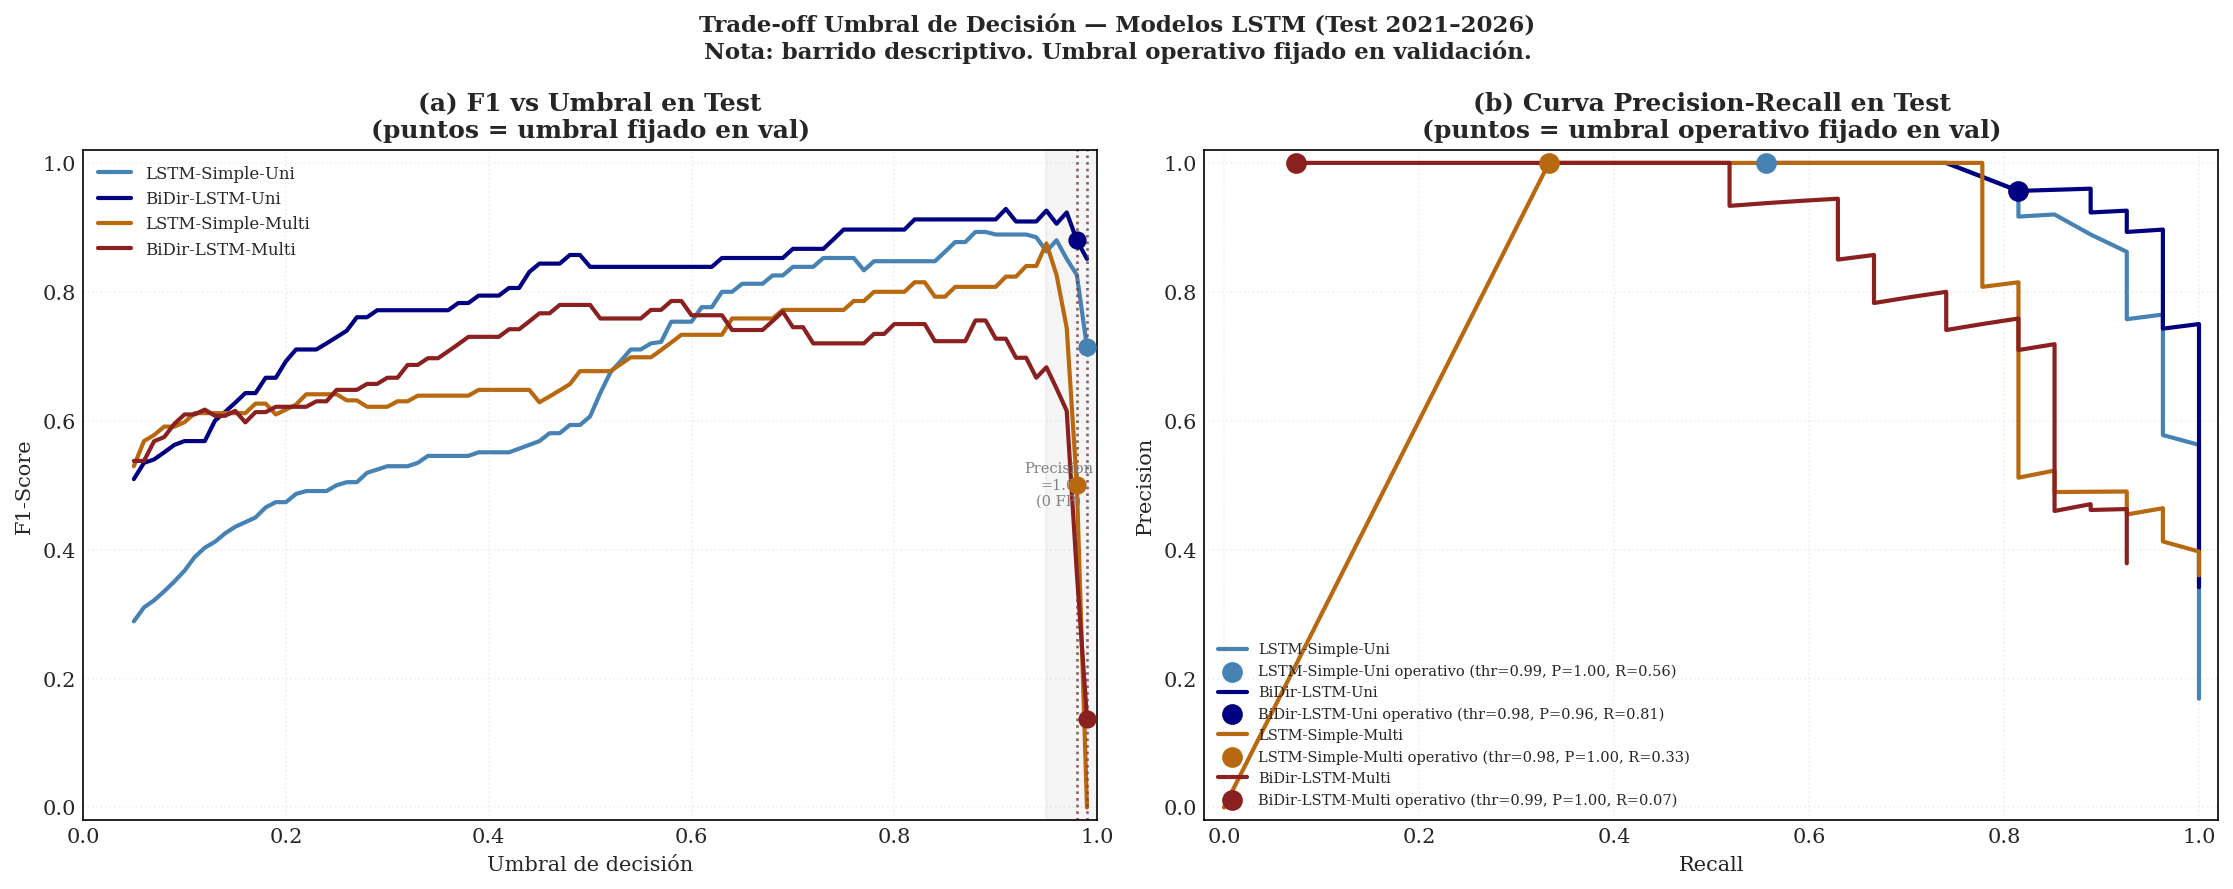

Figura guardada: fig_threshold_tradeoff.png


In [51]:
# ───  Análisis del trade-off Precision/Recall vs Umbral ──
# Propósito: Precision=1.0 en test con thr=0.98-0.99 no es un error —
# es una consecuencia del threshold alto.
# IMPORTANTE: el barrido es sobre TEST solo como análisis descriptivo.
# NO se usa para re-seleccionar el umbral — ese fue fijado en val.

modelos_umbral = {}

# Recopilar modelo ganador + resto de LSTM para comparación
for arch_name, data in {**results_lstm_uni, **results_lstm_multi}.items():
    key_test = f"{arch_name}_test"
    if key_test in Y_SCORES:
        modelos_umbral[arch_name] = {
            'yt':        Y_SCORES[key_test][0],
            'ys':        Y_SCORES[key_test][1],
            'thr_val':   data['threshold'],   # umbral fijado en val
        }

if not modelos_umbral:
    print("No hay scores LSTM en Y_SCORES — ejecutar Partes III y IV primero.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(
        'Trade-off Umbral de Decisión — Modelos LSTM (Test 2021–2026)\n'
        'Nota: barrido descriptivo. Umbral operativo fijado en validación.',
        fontweight='bold', fontsize=11
    )

    colors_map = {
        'BiDir-LSTM-Uni':    'navy',
        'LSTM-Simple-Uni':   'steelblue',
        'BiDir-LSTM-Multi':  '#8B2020',
        'LSTM-Simple-Multi': '#B8690F',
    }

    thresholds_grid = np.arange(0.05, 0.995, 0.01)

    for arch_name, datos in modelos_umbral.items():
        yt        = datos['yt'].astype(int)
        ys        = datos['ys']
        thr_val   = datos['thr_val']
        color     = colors_map.get(arch_name, 'gray')

        rows = []
        for thr in thresholds_grid:
            yp   = (ys >= thr).astype(int)
            f1   = f1_score(yt, yp, zero_division=0)
            prec = precision_score(yt, yp, zero_division=0)
            rec  = recall_score(yt, yp, zero_division=0)
            rows.append({'thr': thr, 'f1': f1,
                         'precision': prec, 'recall': rec})
        df_thr = pd.DataFrame(rows)

        # Panel (a): F1, Precision, Recall vs umbral
        ax = axes[0]
        ax.plot(df_thr['thr'], df_thr['f1'],
                color=color, lw=2, label=f'{arch_name}')
        # Marcar umbral operativo (fijado en val)
        f1_at_val = float(df_thr.loc[
            (df_thr['thr'] - thr_val).abs().idxmin(), 'f1'])
        ax.axvline(thr_val, color=color, ls=':', lw=1.2, alpha=0.6)
        ax.scatter([thr_val], [f1_at_val],
                   color=color, s=60, zorder=5)

        # Panel (b): curva Precision-Recall
        ax2 = axes[1]
        ax2.plot(df_thr['recall'], df_thr['precision'],
                 color=color, lw=2, label=f'{arch_name}')
        # Marcar punto operativo
        prec_at_val = float(df_thr.loc[
            (df_thr['thr'] - thr_val).abs().idxmin(), 'precision'])
        rec_at_val  = float(df_thr.loc[
            (df_thr['thr'] - thr_val).abs().idxmin(), 'recall'])
        ax2.scatter([rec_at_val], [prec_at_val],
                    color=color, s=80, zorder=5,
                    label=f'{arch_name} operativo '
                          f'(thr={thr_val:.2f}, '
                          f'P={prec_at_val:.2f}, R={rec_at_val:.2f})')

    # Formatear panel (a)
    axes[0].set_xlabel('Umbral de decisión', fontsize=10)
    axes[0].set_ylabel('F1-Score', fontsize=10)
    axes[0].set_title('(a) F1 vs Umbral en Test\n'
                      '(puntos = umbral fijado en val)',
                      fontweight='bold')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3, linestyle=':')

    # Anotar zona Precision=1.0
    axes[0].axvspan(0.95, 1.00, alpha=0.08, color='gray',
                    label='Zona Precision=1.0 (0 FP)')
    axes[0].text(0.962, 0.50, 'Precision\n=1.0\n(0 FP)',
                 fontsize=7, color='gray', ha='center', va='center')

    # Formatear panel (b)
    axes[1].set_xlabel('Recall', fontsize=10)
    axes[1].set_ylabel('Precision', fontsize=10)
    axes[1].set_title('(b) Curva Precision-Recall en Test\n'
                      '(puntos = umbral operativo fijado en val)',
                      fontweight='bold')
    axes[1].set_xlim(-0.02, 1.02)
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].legend(fontsize=7, loc='lower left')
    axes[1].grid(alpha=0.3, linestyle=':')

    plt.tight_layout()
    plt.savefig(f"{FIG_PATH}/fig_threshold_tradeoff.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Figura guardada: fig_threshold_tradeoff.png")

    # ── Tabla resumen: impacto de bajar el umbral en BiDir-Uni ──
    # Muestra cuántos FN se recuperan aceptando algunos FP.
    # Útil para la narrativa de gestión de riesgo en la defensa.
    best_name = bench_test.iloc[0]['nombre'] if not bench_test.empty else None
    if best_name and best_name in modelos_umbral:
        yt_b  = modelos_umbral[best_name]['yt'].astype(int)
        ys_b  = modelos_umbral[best_name]['ys']
        thr_b = modelos_umbral[best_name]['thr_val']

        print(f"\nImpacto de variar umbral — {best_name} (test)")
        print(f"{'Umbral':>8} {'F1':>7} {'Prec':>7} {'Recall':>8} "
              f"{'TP':>5} {'FP':>5} {'FN':>5}")
        print("─" * 55)
        for thr_show in [thr_b - 0.20, thr_b - 0.10, thr_b,
                         thr_b + 0.05 if thr_b < 0.95 else None]:
            if thr_show is None or thr_show <= 0:
                continue
            thr_show = min(thr_show, 0.99)
            yp_s = (ys_b >= thr_show).astype(int)
            cm   = confusion_matrix(yt_b, yp_s)
            tn_s, fp_s, fn_s, tp_s = cm.ravel() if cm.shape == (2,2) \
                                      else (0, 0, 0, 0)
            f1_s   = f1_score(yt_b, yp_s, zero_division=0)
            prec_s = precision_score(yt_b, yp_s, zero_division=0)
            rec_s  = recall_score(yt_b, yp_s, zero_division=0)
            marker = " ← operativo (val)" if abs(thr_show - thr_b) < 0.001 \
                     else ""
            print(f"{thr_show:>8.2f} {f1_s:>7.4f} {prec_s:>7.4f} "
                  f"{rec_s:>8.4f} {tp_s:>5} {fp_s:>5} {fn_s:>5}{marker}")

        print(f"\nInterpretación financiera:")
        print(f"  FP = falsa alarma → compra de put innecesaria (~0.5-1% nominal)")
        print(f"  FN = posición descubierta ante evento extremo (costo ilimitado)")
        print(f"  El umbral operativo ({thr_b:.2f}) maximiza F1 en val.")
        print(f"  Bajar el umbral aumenta Recall (menos FN) a costa de más FP.")
        print(f"  La elección óptima depende del ratio costo(FN)/costo(FP).")

In [52]:
# ─── Bootstrap Confidence Intervals — métricas en test ────────
# Propósito: cuantificar incertidumbre del estimador sin TimeSeriesSplit
# Método: bootstrap no paramétrico sobre el conjunto de test (n=1,000 muestras)
# Justificación: con solo 27 eventos extremos en test, los IC son esenciales
# para distinguir diferencias reales de ruido muestral.

from sklearn.utils import resample

def bootstrap_ci(y_true, y_score, threshold, n_boot=1000,
                 ci=0.95, seed=RANDOM_SEED):
    """
    Bootstrap no paramétrico para F1, AUC-ROC y Precision en test.

    Parámetros
    ----------
    y_true     : np.ndarray — labels reales (test)
    y_score    : np.ndarray — scores del modelo (test)
    threshold  : float — umbral operativo fijado en val
    n_boot     : int — número de muestras bootstrap (default 1,000)
    ci         : float — nivel de confianza (default 0.95)
    seed       : int — semilla para reproducibilidad

    Retorna
    -------
    dict con mean, lo, hi para f1, auc, precision, recall
    """
    rng = np.random.RandomState(seed)
    metrics = {'f1': [], 'auc': [], 'precision': [], 'recall': []}

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        yt  = y_true[idx]
        ys  = y_score[idx]
        yp  = (ys >= threshold).astype(int)

        # Saltar muestras sin positivos (no se puede calcular AUC)
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue

        metrics['f1'].append(f1_score(yt, yp, zero_division=0))
        metrics['precision'].append(precision_score(yt, yp, zero_division=0))
        metrics['recall'].append(recall_score(yt, yp, zero_division=0))
        try:
            metrics['auc'].append(roc_auc_score(yt, ys))
        except ValueError:
            pass

    alpha = (1 - ci) / 2
    result = {}
    for k, vals in metrics.items():
        vals = np.array(vals)
        result[k] = {
            'mean': round(float(np.mean(vals)), 4),
            'lo':   round(float(np.percentile(vals, alpha * 100)), 4),
            'hi':   round(float(np.percentile(vals, (1 - alpha) * 100)), 4),
        }
    return result

# ── Calcular CI para todos los modelos con scores en Y_SCORES ──
print("─── Bootstrap CI (95%) — Test 2021–2026 ────────────────")
print(f"  n_boot=1,000 | Umbral operativo fijado en validación")
print(f"  Eventos extremos en test: {yw_test_uni.sum()} / {len(yw_test_uni)}")
print()
print(f"{'Modelo':<28} {'F1':>8} {'IC 95% F1':>18} "
      f"{'AUC':>8} {'IC 95% AUC':>18}")
print("─" * 82)

ci_results = {}
for key, (yt, ys) in Y_SCORES.items():
    if 'test' not in key:
        continue
    name = key.replace('_test', '')
    thr  = OPTIMAL_THRESHOLDS.get(name, 0.5)

    ci_r = bootstrap_ci(yt.astype(int), ys, threshold=thr,
                        n_boot=1000, ci=0.95, seed=RANDOM_SEED)
    ci_results[name] = ci_r

    f1_str  = f"[{ci_r['f1']['lo']:.3f} – {ci_r['f1']['hi']:.3f}]"
    auc_str = f"[{ci_r['auc']['lo']:.3f} – {ci_r['auc']['hi']:.3f}]"

    print(f"  {name:<26} {ci_r['f1']['mean']:>8.4f} {f1_str:>18} "
          f"{ci_r['auc']['mean']:>8.4f} {auc_str:>18}")

print("─" * 82)
print()
print("Interpretación:")
print("  IC amplio  → incertidumbre alta (pocos eventos en test)")
print("  IC estrecho → estimación estable (modelo robusto)")
print()
print("NOTA: Bootstrap sobre test fijo — no es validación cruzada temporal.")
print("  Cuantifica varianza muestral del estimador, no varianza del modelo.")
print("  Para varianza del modelo se requeriría TimeSeriesSplit (trabajo futuro).")

─── Bootstrap CI (95%) — Test 2021–2026 ────────────────
  n_boot=1,000 | Umbral operativo fijado en validación
  Eventos extremos en test: 27.0 / 1268

Modelo                             F1          IC 95% F1      AUC         IC 95% AUC
──────────────────────────────────────────────────────────────────────────────────
  GARCH                        0.0419    [0.028 – 0.057]   0.9892    [0.976 – 0.998]
  LSTM-Simple-Uni              0.6050    [0.478 – 0.720]   0.9989    [0.997 – 1.000]
  BiDir-LSTM-Uni               0.8370    [0.725 – 0.933]   0.9995    [0.999 – 1.000]
  LSTM-Simple-Multi            0.6747    [0.535 – 0.795]   0.9957    [0.991 – 0.999]
  BiDir-LSTM-Multi             0.7770    [0.652 – 0.886]   0.9826    [0.954 – 0.998]
  GRU-Simple-Uni               0.6772    [0.489 – 0.824]   0.9989    [0.997 – 1.000]
  BiDir-GRU-Uni                0.7974    [0.645 – 0.913]   0.9995    [0.998 – 1.000]
  TCN-Uni                      0.4220    [0.312 – 0.526]   0.9748    [0.965 – 0.984]

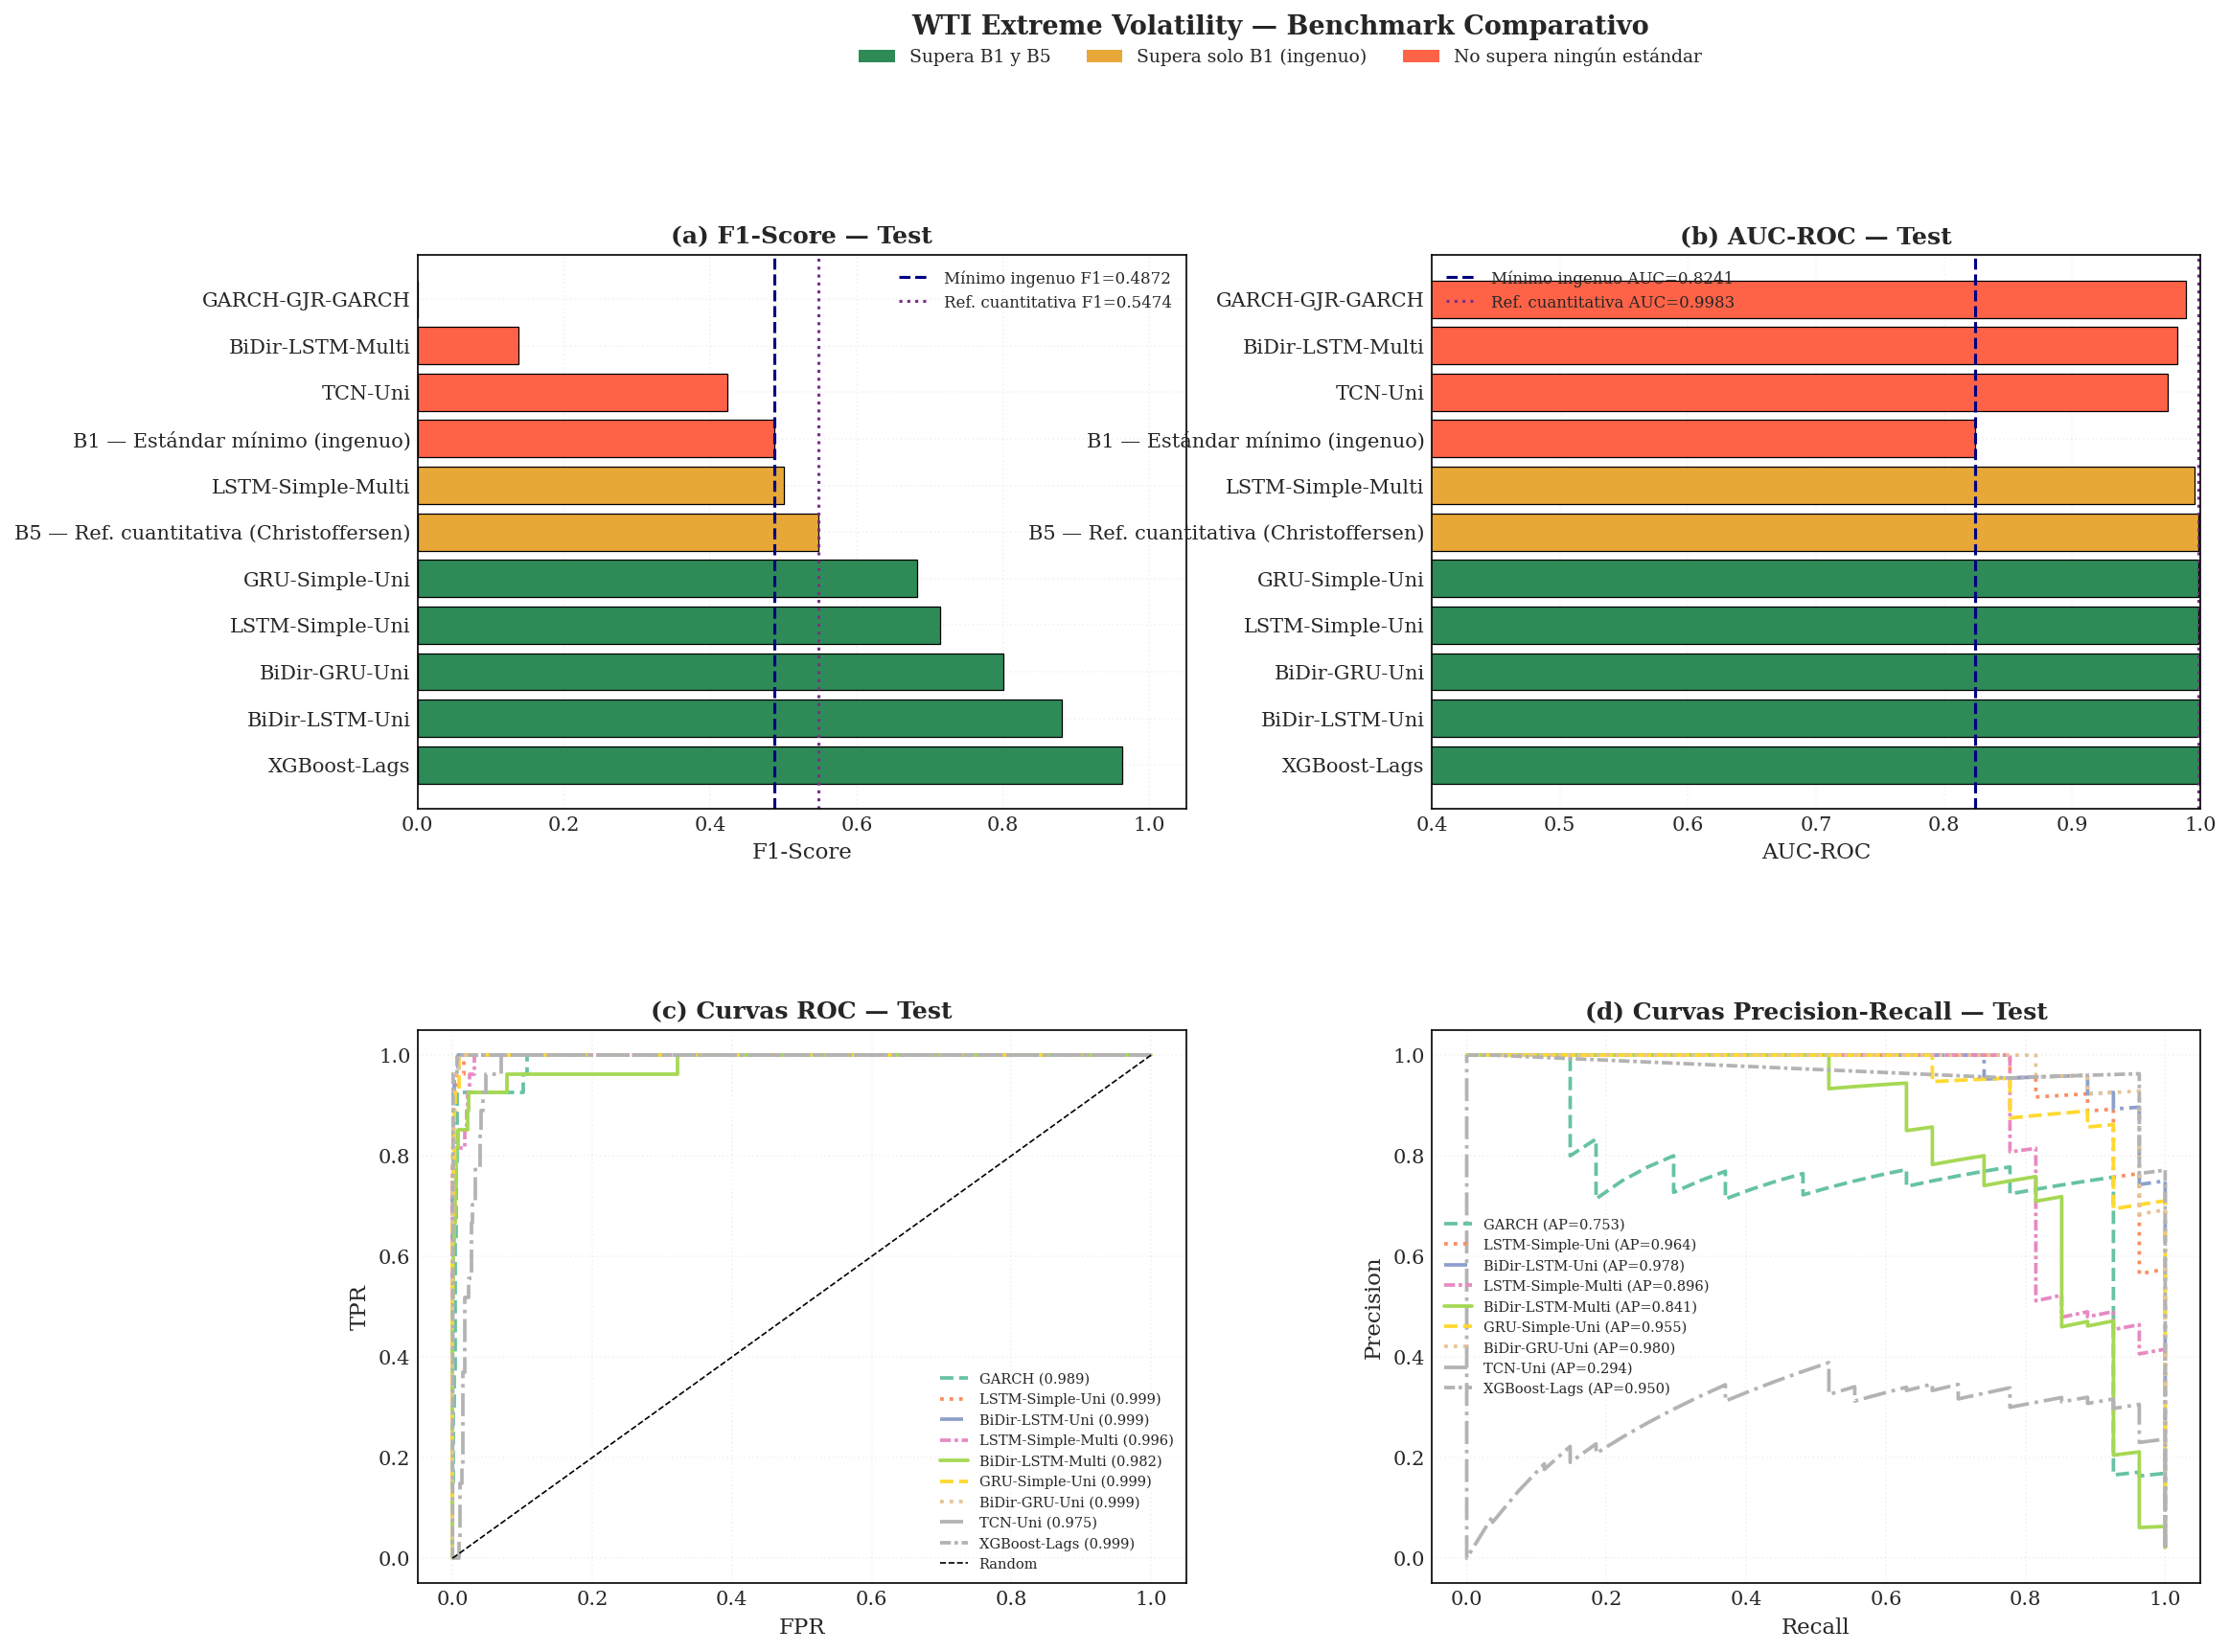

Figura guardada: fig_benchmark_comparacion.png


In [53]:
# ─── 6.2 Figura 4 paneles comparativa ─────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)

ax_f1  = fig.add_subplot(gs[0, 0])
ax_auc = fig.add_subplot(gs[0, 1])
ax_roc = fig.add_subplot(gs[1, 0])
ax_pr  = fig.add_subplot(gs[1, 1])

# Datos de la tabla (sólo modelos con métricas completas)
bench_plot = bench_test.dropna(subset=['f1', 'auc'])
models_p   = bench_plot['nombre'].tolist()
f1s_p      = bench_plot['f1'].tolist()
aucs_p     = bench_plot['auc'].tolist()

# ── Colores: 3 niveles — definir ANTES de dibujar barras ──────
_beats_ing  = bench_plot['Beats_Ingenuo'].tolist() \
              if 'Beats_Ingenuo' in bench_plot.columns \
              else [False] * len(bench_plot)
_beats_cuan = bench_plot['Beats_Cuant'].tolist() \
              if 'Beats_Cuant'  in bench_plot.columns \
              else [False] * len(bench_plot)

beat_colors = []
for b_ing, b_cua in zip(_beats_ing, _beats_cuan):
    if b_cua:
        beat_colors.append('seagreen')   # supera B1 y B5
    elif b_ing:
        beat_colors.append('#E8A838')    # supera solo B1
    else:
        beat_colors.append('tomato')     # no supera ninguno

# Panel (a): F1
ax_f1.barh(models_p, f1s_p, color=beat_colors,
           edgecolor='black', linewidth=0.6)
ax_f1.axvline(F1_MINIMO,     color='navy',    ls='--', lw=1.5,
              label=f'Mínimo ingenuo F1={F1_MINIMO}')
ax_f1.axvline(F1_CUANT_TEST, color='#7b2d8b', ls=':',  lw=1.5,
              label=f'Ref. cuantitativa F1={F1_CUANT_TEST}')
ax_f1.set_title('(a) F1-Score — Test', fontweight='bold')
ax_f1.set_xlabel('F1-Score')
ax_f1.legend(fontsize=8)
ax_f1.set_xlim(0, 1.05)

# Panel (b): AUC-ROC
ax_auc.barh(models_p, aucs_p, color=beat_colors,
            edgecolor='black', linewidth=0.6)
ax_auc.axvline(AUC_MINIMO,     color='navy',    ls='--', lw=1.5,
               label=f'Mínimo ingenuo AUC={AUC_MINIMO}')
ax_auc.axvline(AUC_CUANT_TEST, color='#7b2d8b', ls=':',  lw=1.5,
               label=f'Ref. cuantitativa AUC={AUC_CUANT_TEST}')
ax_auc.set_title('(b) AUC-ROC — Test', fontweight='bold')
ax_auc.set_xlabel('AUC-ROC')
ax_auc.legend(fontsize=8)
ax_auc.set_xlim(0.4, 1.0)

# Paneles (c) y (d)
line_styles  = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
model_colors = plt.cm.Set2(np.linspace(0, 1, max(len(Y_SCORES), 1)))

for i, (key, (yt, ys)) in enumerate(Y_SCORES.items()):
    if 'test' not in key:
        continue
    try:
        fpr, tpr, _    = roc_curve(yt, ys)
        prec, rec, _   = precision_recall_curve(yt, ys)
        auc_v = roc_auc_score(yt, ys)
        ap_v  = average_precision_score(yt, ys)
    except Exception:
        continue
    ls  = line_styles[i % len(line_styles)]
    col = model_colors[i % len(model_colors)]
    lbl = key.replace('_test', '')
    ax_roc.plot(fpr, tpr, ls=ls, lw=1.8, color=col,
                label=f"{lbl} ({auc_v:.3f})")
    ax_pr.plot(rec, prec, ls=ls, lw=1.8, color=col,
               label=f"{lbl} (AP={ap_v:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax_roc.set_title('(c) Curvas ROC — Test', fontweight='bold')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=7)

ax_pr.set_title('(d) Curvas Precision-Recall — Test', fontweight='bold')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=7)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='seagreen', label='Supera B1 y B5'),
    Patch(facecolor='#E8A838',  label='Supera solo B1 (ingenuo)'),
    Patch(facecolor='tomato',   label='No supera ningún estándar'),
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=9)

fig.suptitle('WTI Extreme Volatility — Benchmark Comparativo',
             fontweight='bold', fontsize=13, y=1.02)
plt.savefig(f"{FIG_PATH}/fig_benchmark_comparacion.png",
            dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Figura guardada: fig_benchmark_comparacion.png")

In [54]:
# 6.3 Diebold-Mariano test
def diebold_mariano_test(e1, e2, h=1, crit='MSE'):
    """
    Test Diebold-Mariano (1995) de igualdad de exactitud predictiva.
    H0: E[L(e1)] = E[L(e2)] — los modelos tienen la misma precisión.

    Parámetros
    ----------
    e1, e2 : arrays de errores de forecast (y_true - y_score)
    h      : horizonte de forecast (1 por defecto)
    crit   : función de pérdida ('MSE' o 'MAE')

    Retorna
    -------
    dm_stat : float, p_value : float (bilateral)
    """
    e1, e2 = np.asarray(e1), np.asarray(e2)
    if crit == 'MSE':
        d = e1**2 - e2**2
    elif crit == 'MAE':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("crit debe ser 'MSE' o 'MAE'")

    n     = len(d)
    d_bar = d.mean()
    gamma0 = np.var(d, ddof=0)
    gamma  = sum(
        2 * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
        for k in range(1, h)) if h > 1 else 0

    var_d = (gamma0 + gamma) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat = d_bar / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

def normalize_scores_minmax(y_score):
    """Normaliza scores a [0, 1] con min-max."""
    mn, mx = np.nanmin(y_score), np.nanmax(y_score)
    if mx - mn < 1e-12:
        return np.full_like(y_score, 0.5)
    return (y_score - mn) / (mx - mn)

# Recopilar scores de test
test_scores_list = []
for k, (yt, ys) in Y_SCORES.items():
    if 'test' not in k:
        continue
    name = k.replace('_test', '')
    is_garch = 'GARCH' in name.upper()
    test_scores_list.append((name, yt, ys, is_garch))

# ── (A) DM Test intra-familia LSTM (scores en misma escala 0-1) ──
lstm_models_dm = [(n, yt, ys) for n, yt, ys, g in test_scores_list if not g]

if len(lstm_models_dm) >= 2:
    print("─── DM Test intra-familia LSTM (test, scores 0-1) ──────")
    print(f"{'Modelo 1':25s} {'Modelo 2':25s} {'DM stat':>9} {'p-value':>9} Signif.")
    print("─" * 78)
    for i in range(len(lstm_models_dm)):
        for j in range(i+1, len(lstm_models_dm)):
            n1, yt1, ys1 = lstm_models_dm[i]
            n2, yt2, ys2 = lstm_models_dm[j]
            min_len = min(len(yt1), len(yt2))
            e1 = yt1[:min_len].astype(float) - ys1[:min_len]
            e2 = yt2[:min_len].astype(float) - ys2[:min_len]
            dm, p = diebold_mariano_test(e1, e2, h=1, crit='MSE')
            sig = '***' if p < 0.01 else ('**' if p < 0.05 else
                  ('*' if p < 0.10 else ''))
            print(f"{n1:25s} {n2:25s} {dm:>9.4f} {p:>9.4f} {sig}")
    print()

# ── (B) DM Test cross-familia (scores normalizados [0,1]) ──
if len(test_scores_list) >= 2:
    print("─── DM Test cross-familia (scores normalizados [0,1]) ──")
    print("NOTA: Scores normalizados por min-max para comparabilidad.")
    print("      Interpretar con cautela: la normalización altera la escala.\n")
    print(f"{'Modelo 1':25s} {'Modelo 2':25s} {'DM stat':>9} {'p-value':>9} Signif.")
    print("─" * 78)

    normalized = [(n, yt, normalize_scores_minmax(ys))
                  for n, yt, ys, _ in test_scores_list]

    for i in range(len(normalized)):
        for j in range(i+1, len(normalized)):
            n1, yt1, ys1 = normalized[i]
            n2, yt2, ys2 = normalized[j]
            min_len = min(len(yt1), len(yt2))
            e1 = yt1[:min_len].astype(float) - ys1[:min_len]
            e2 = yt2[:min_len].astype(float) - ys2[:min_len]
            dm, p = diebold_mariano_test(e1, e2, h=1, crit='MSE')
            sig = '***' if p < 0.01 else ('**' if p < 0.05 else
                  ('*' if p < 0.10 else ''))
            print(f"{n1:25s} {n2:25s} {dm:>9.4f} {p:>9.4f} {sig}")
else:
    print("Insuficientes modelos para DM test (se necesitan >= 2).")

─── DM Test intra-familia LSTM (test, scores 0-1) ──────
Modelo 1                  Modelo 2                    DM stat   p-value Signif.
──────────────────────────────────────────────────────────────────────────────
LSTM-Simple-Uni           BiDir-LSTM-Uni               5.7055    0.0000 ***
LSTM-Simple-Uni           LSTM-Simple-Multi            2.2493    0.0245 **
LSTM-Simple-Uni           BiDir-LSTM-Multi             2.7160    0.0066 ***
LSTM-Simple-Uni           GRU-Simple-Uni               1.4204    0.1555 
LSTM-Simple-Uni           BiDir-GRU-Uni                6.3846    0.0000 ***
LSTM-Simple-Uni           TCN-Uni                     -6.1255    0.0000 ***
LSTM-Simple-Uni           XGBoost-Lags                 1.1575    0.2471 
BiDir-LSTM-Uni            LSTM-Simple-Multi           -1.8825    0.0598 *
BiDir-LSTM-Uni            BiDir-LSTM-Multi            -0.9021    0.3670 
BiDir-LSTM-Uni            GRU-Simple-Uni              -5.7540    0.0000 ***
BiDir-LSTM-Uni            BiDir-GRU-

In [55]:
# ─── 6.4 McNemar test (con umbrales optimizados por modelo) ────
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

def run_mcnemar_pair(yt, yp1, yp2, name1, name2):
    """McNemar test entre dos clasificadores binarios sobre el mismo y_true."""
    b = int(np.sum((yt == yp1) & (yt != yp2)))
    c = int(np.sum((yt != yp1) & (yt == yp2)))
    if b + c == 0:
        print(f"  {name1} vs {name2}: sin discordancias — test no aplicable.")
        return None
    exact = min(b, c) < 25
    table = np.array([[0, b], [c, 0]])
    result = mcnemar_test(table, exact=exact)
    sig = '***' if result.pvalue < 0.01 else ('**' if result.pvalue < 0.05
          else ('*' if result.pvalue < 0.10 else ''))
    print(f"  {name1:25s} vs {name2:25s} | b={b:3d} c={c:3d} | "
          f"p={result.pvalue:.4f} {sig} | {'exact' if exact else 'chi2'}")
    return result

# GARCH
if 'GARCH_test' in Y_SCORES:
    OPTIMAL_THRESHOLDS['GARCH'] = GARCH_OPT_THRESHOLD

# LSTM univariados
for name, data in results_lstm_uni.items():
    OPTIMAL_THRESHOLDS[name] = data['threshold']

# LSTM multivariados
for name, data in results_lstm_multi.items():
    OPTIMAL_THRESHOLDS[name] = data['threshold']

print("─── Umbrales optimizados por modelo ───")
for name, thr in OPTIMAL_THRESHOLDS.items():
    print(f"  {name:25s}: {thr:.4f}")
print()

# ── Generar predicciones binarias con umbral correcto ──
preds_test = {}
for key, (yt, ys) in Y_SCORES.items():
    if 'test' not in key:
        continue
    name = key.replace('_test', '')
    thr  = OPTIMAL_THRESHOLDS.get(name, 0.5)
    # GARCH usa > (estrictamente mayor), LSTMs usan >= (mayor o igual)
    yp = (ys > thr).astype(int) if 'GARCH' in name else (ys >= thr).astype(int)
    preds_test[name] = (yt, yp)

if len(preds_test) >= 2:
    print("─── McNemar Test (pares, test, umbrales optimizados) ───")
    pairs = list(preds_test.keys())
    for i in range(len(pairs)):
        for j in range(i+1, len(pairs)):
            n1, (yt1, yp1) = pairs[i], preds_test[pairs[i]]
            n2, (yt2, yp2) = pairs[j], preds_test[pairs[j]]
            min_len = min(len(yt1), len(yt2))
            if np.array_equal(yt1[:min_len], yt2[:min_len]):
                run_mcnemar_pair(yt1[:min_len], yp1[:min_len],
                                 yp2[:min_len], n1, n2)
            else:
                print(f"  {n1} vs {n2}: y_true no coincide — verificar alineación")
else:
    print("Insuficientes modelos para McNemar (se necesitan >= 2).")

─── Umbrales optimizados por modelo ───
  GRU-Simple-Uni           : 0.9900
  BiDir-GRU-Uni            : 0.9900
  TCN-Uni                  : 0.2900
  XGBoost-Lags             : 0.4800
  GARCH                    : 7.3653
  LSTM-Simple-Uni          : 0.9900
  BiDir-LSTM-Uni           : 0.9800
  LSTM-Simple-Multi        : 0.9800
  BiDir-LSTM-Multi         : 0.9900

─── McNemar Test (pares, test, umbrales optimizados) ───
  GARCH                     vs LSTM-Simple-Uni           | b=  0 c= 15 | p=0.0001 *** | exact
  GARCH                     vs BiDir-LSTM-Uni            | b=  1 c= 22 | p=0.0000 *** | exact
  GARCH                     vs LSTM-Simple-Multi         | b=  0 c=  9 | p=0.0039 *** | exact
  GARCH                     vs BiDir-LSTM-Multi          | b=  0 c=  2 | p=0.5000  | exact
  GARCH                     vs GRU-Simple-Uni            | b=  0 c= 14 | p=0.0001 *** | exact
  GARCH                     vs BiDir-GRU-Uni             | b=  0 c= 18 | p=0.0000 *** | exact
  GARCH          

Modelo ganador (F1 test): XGBoost-Lags
Umbral de decisión: 0.4800  (desde OPTIMAL_THRESHOLDS)

Confusión en test:
  TP=26  FP=1  FN=1  TN=1240
  Detectados: 26/27 extremos (96.3% recall)


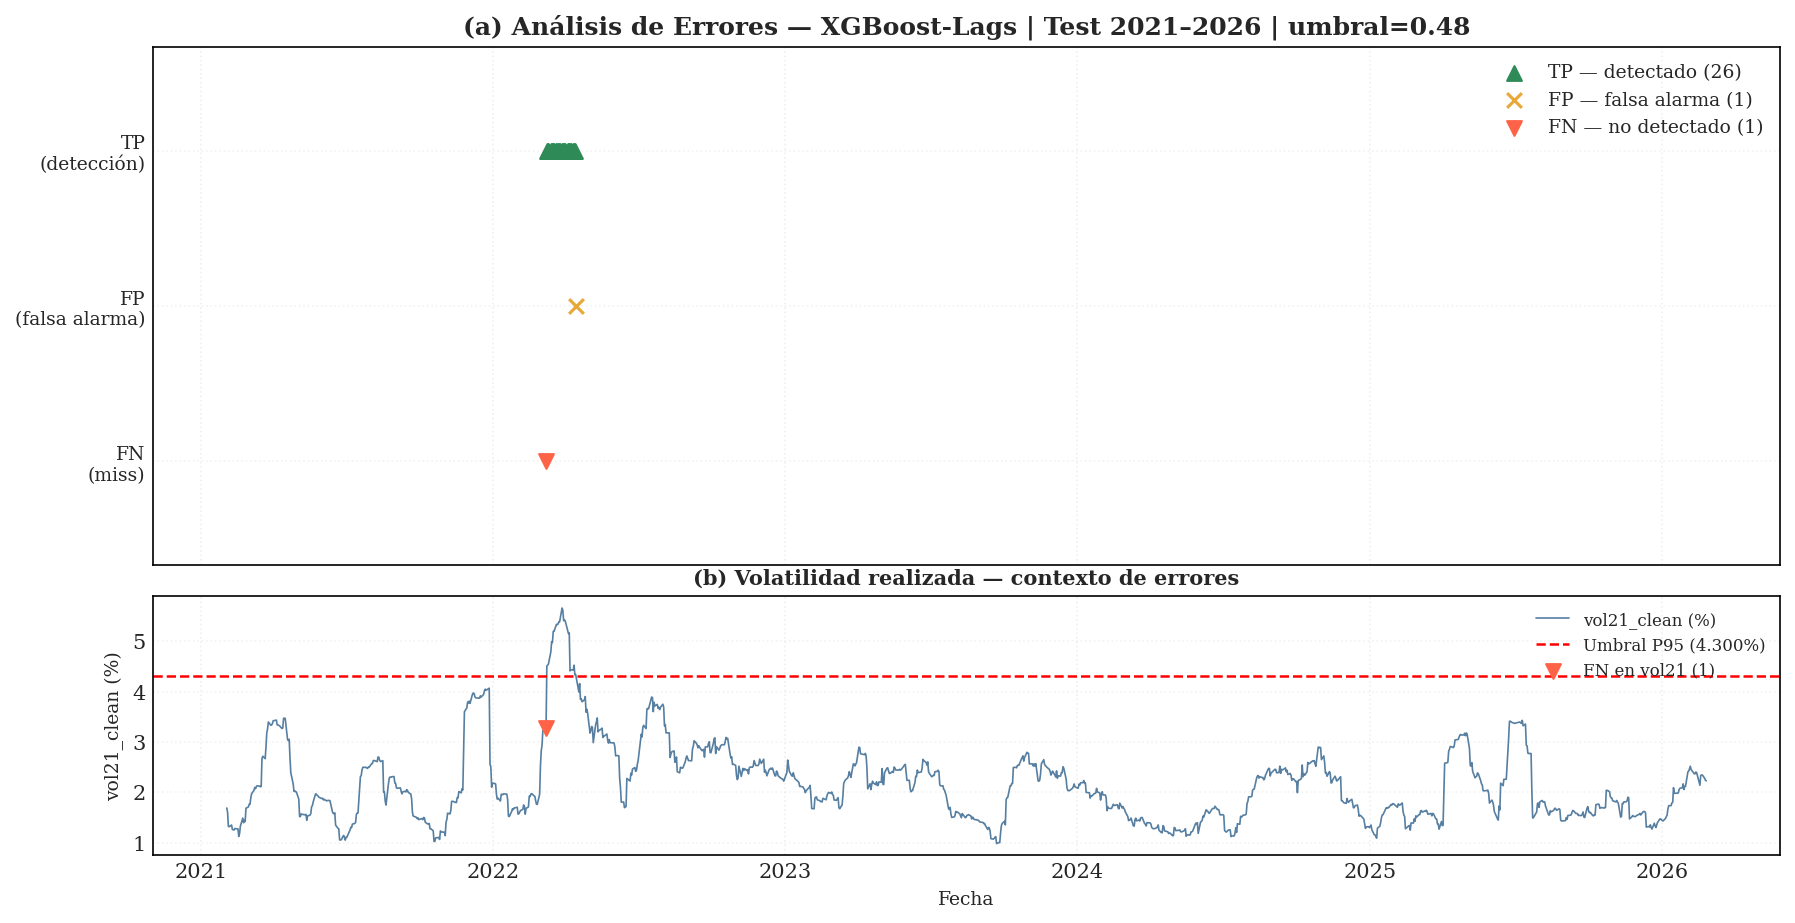

Figura guardada: fig_error_analysis.png

FN detalle (1 eventos no detectados):
            vol21_clean_%  y_score_modelo
Date                                     
2022-03-08       3.275800        0.175700

  → Score promedio en FN: 0.1757 (umbral=0.4800)
  → Vol21 promedio en FN: 3.2758%


In [56]:
# ─── 6.5 Análisis de errores — timeline FP/FN ─────────────────
# Modelo ganador según benchmark (primer lugar en F1 test)

if bench_test.empty:
    print("bench_test vacío — ejecutar Cell 6.1 primero.")
else:
    best_model_name = bench_test.iloc[0]['nombre']
    print(f"Modelo ganador (F1 test): {best_model_name}")

    # ── Buscar scores en Y_SCORES usando clave exacta ──────────
    # Construir clave directa: evita split('-') frágil que matchea
    # parcialmente (ej: 'BiDir' matchea BiDir-Uni y BiDir-Multi)
    key_best = f"{best_model_name}_test"

    # Fallback: buscar clave que contenga el nombre completo
    if key_best not in Y_SCORES:
        key_best = next(
            (k for k in Y_SCORES if 'test' in k and best_model_name in k),
            None
        )

    if key_best is None or key_best not in Y_SCORES:
        print(f"No se encontraron scores de '{best_model_name}' en Y_SCORES.")
        print(f"Claves disponibles: {list(Y_SCORES.keys())}")
    else:
        yt_best, ys_best = Y_SCORES[key_best]

        # ── Recuperar umbral desde OPTIMAL_THRESHOLDS (Cell 62) ──
        # OPTIMAL_THRESHOLDS fue construido con el umbral correcto por modelo.
        # Fallback a 0.5 solo si el modelo no está registrado.
        thr_best = OPTIMAL_THRESHOLDS.get(best_model_name, 0.5)
        print(f"Umbral de decisión: {thr_best:.4f}  "
              f"({'desde OPTIMAL_THRESHOLDS' if best_model_name in OPTIMAL_THRESHOLDS else 'fallback 0.5'})")

        # GARCH usa > estrictamente, LSTMs usan >=
        if 'GARCH' in best_model_name:
            yp_best = (ys_best > thr_best).astype(int)
        else:
            yp_best = (ys_best >= thr_best).astype(int)

        # ── Construir DataFrame de errores ───────────────────────
        # idx_test_uni == idx_test_multi por construcción (Cell 21):
        # ambos usan df_test.index después del mismo dropna(FEATURES_MULTI)
        idx_plot = idx_test_uni

        if len(idx_plot) != len(yt_best):
            print(f"Desajuste de índice: idx_plot={len(idx_plot)} "
                  f"vs yt_best={len(yt_best)} — omitiendo figura.")
        else:
            df_errors = pd.DataFrame({
                'y_true': yt_best,
                'y_pred': yp_best,
                'y_score': ys_best,
                'FP': (yp_best == 1) & (yt_best == 0),
                'FN': (yp_best == 0) & (yt_best == 1),
                'TP': (yp_best == 1) & (yt_best == 1),
                'TN': (yp_best == 0) & (yt_best == 0),
            }, index=idx_plot)

            n_tp = df_errors['TP'].sum()
            n_fp = df_errors['FP'].sum()
            n_fn = df_errors['FN'].sum()
            n_total_pos = int(yt_best.sum())

            print(f"\nConfusión en test:")
            print(f"  TP={n_tp}  FP={n_fp}  FN={n_fn}  "
                  f"TN={df_errors['TN'].sum()}")
            print(f"  Detectados: {n_tp}/{n_total_pos} extremos "
                  f"({n_tp/n_total_pos*100:.1f}% recall)")

            # ── Figura: timeline FP/FN + vol21_clean overlay ─────
            fig, (ax_err, ax_vol) = plt.subplots(
                2, 1, figsize=(14, 7), sharex=True,
                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08}
            )

            # Panel superior: errores
            ax_err.scatter(
                df_errors.index[df_errors['TP']], [0.8]*n_tp,
                marker='^', color='seagreen', s=50, zorder=4,
                label=f"TP — detectado ({n_tp})")
            ax_err.scatter(
                df_errors.index[df_errors['FP']], [0.5]*n_fp,
                marker='x', color='#E8A838', s=50, zorder=4, linewidths=1.5,
                label=f"FP — falsa alarma ({n_fp})")
            ax_err.scatter(
                df_errors.index[df_errors['FN']], [0.2]*n_fn,
                marker='v', color='tomato', s=50, zorder=4,
                label=f"FN — no detectado ({n_fn})")

            add_crisis_zones(ax_err,
                             xlim=(df_errors.index.min(), df_errors.index.max()))
            ax_err.set_yticks([0.2, 0.5, 0.8])
            ax_err.set_yticklabels(['FN\n(miss)', 'FP\n(falsa alarma)', 'TP\n(detección)'],
                                    fontsize=9)
            ax_err.set_ylim(0, 1)
            ax_err.set_title(
                f"(a) Análisis de Errores — {best_model_name} | Test 2021–2026 "
                f"| umbral={thr_best:.2f}",
                fontweight='bold')
            ax_err.legend(loc='upper right', fontsize=9)
            ax_err.grid(axis='x', alpha=0.3, linestyle=':')

            # Panel inferior: vol21_clean para contextualizar errores
            vol_test = df_test['vol21_clean'].reindex(idx_plot)
            ax_vol.plot(idx_plot, vol_test * 100, color='#2c5f8a',
                        lw=0.8, alpha=0.8, label='vol21_clean (%)')
            ax_vol.axhline(UMBRAL_CLASIFICACION * 100, color='red',
                           ls='--', lw=1.2,
                           label=f'Umbral P95 ({UMBRAL_CLASIFICACION*100:.3f}%)')

            # Marcar FN sobre la curva de volatilidad
            fn_dates = df_errors.index[df_errors['FN']]
            fn_vols  = vol_test.reindex(fn_dates)
            ax_vol.scatter(fn_dates, fn_vols * 100,
                           marker='v', color='tomato', s=50, zorder=4,
                           label=f'FN en vol21 ({n_fn})')

            add_crisis_zones(ax_vol,
                             xlim=(df_errors.index.min(), df_errors.index.max()))
            ax_vol.set_ylabel('vol21_clean (%)', fontsize=9)
            ax_vol.set_xlabel('Fecha', fontsize=9)
            ax_vol.legend(fontsize=8, loc='upper right')
            ax_vol.set_title('(b) Volatilidad realizada — contexto de errores',
                             fontweight='bold', fontsize=10)
            ax_vol.grid(axis='x', alpha=0.3, linestyle=':')

            plt.savefig(f"{FIG_PATH}/fig_error_analysis.png",
                        dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()
            print("Figura guardada: fig_error_analysis.png")

            # ── Tabla de FN: qué días extremos no se detectaron ──
            if n_fn > 0:
                fn_detail = df_errors[df_errors['FN']].copy()
                fn_detail['vol21_clean_%'] = (
                    vol_test.reindex(fn_detail.index) * 100).round(4)
                fn_detail['y_score_modelo'] = fn_detail['y_score'].round(4)
                print(f"\nFN detalle ({n_fn} eventos no detectados):")
                print(fn_detail[['vol21_clean_%', 'y_score_modelo']].to_string())
                print(f"\n  → Score promedio en FN: "
                      f"{fn_detail['y_score_modelo'].mean():.4f} "
                      f"(umbral={thr_best:.4f})")
                print(f"  → Vol21 promedio en FN: "
                      f"{fn_detail['vol21_clean_%'].mean():.4f}%")

### Análisis de sensibilidad al umbral:
Cada benchmark se evalúa perturbando el umbral de su propia señal:
 - B1 usa p95_absret, calibrado sobre |ret_lag1|
 - GARCH usa SIGMA_UMBRAL_PCT, calibrado sobre sigma pronosticada
Esto evita mezclar variables con escalas distintas y hace que la sensibilidad al umbral sea internamente consistente para cada modelo.

In [57]:
#  6.6 Análisis de sensibilidad al umbral
# Dos análisis separados, cada uno con el umbral de su propia feature.
# ── Calcular p95_absret si no está definido
if 'p95_absret' not in dir():
    _train_mask_xgb = (df['split'] == 'train') & (~df['bad_vol21'])
    p95_absret = df.loc[_train_mask_xgb, 'ret_abs_lag1'].quantile(0.95)
    print(f"p95_absret recalculado en train: {p95_absret:.6f}")

# A) Sensibilidad del umbral de B1 (|ret_lag1| vs p95_absret)
# p95_absret calibrado en train — same origin as el benchmark
print("─── Sensibilidad B1 — umbral propio (p95_absret) ±15% ──")
print(f"Umbral base B1 (p95_absret): {p95_absret:.6f}  ({p95_absret*100:.4f}%)")
print()

rows_b1 = []
for delta_pct in [-0.15, -0.10, -0.05, 0.0, +0.05, +0.10, +0.15]:
    new_thr = p95_absret * (1 + delta_pct)
    ret_abs_val  = df_val['ret_abs_lag1'].reindex(idx_val_uni).fillna(0)
    ret_abs_test = df_test['ret_abs_lag1'].reindex(idx_test_uni).fillna(0)
    for split_name, ret_s, y_w in [
            ('val',  ret_abs_val,  yw_val_uni),
            ('test', ret_abs_test, yw_test_uni)]:
        yp = (ret_s.values > new_thr).astype(int)
        f1 = f1_score(y_w.astype(int), yp, zero_division=0)
        pr = precision_score(y_w.astype(int), yp, zero_division=0)
        rc = recall_score(y_w.astype(int), yp, zero_division=0)
        rows_b1.append({'Δ%': f"{delta_pct:+.0%}", 'Umbral': round(new_thr, 6),
                         'Split': split_name, 'F1': round(f1, 4),
                         'Precision': round(pr, 4), 'Recall': round(rc, 4)})

df_sens_b1 = pd.DataFrame(rows_b1)
print(df_sens_b1.to_string(index=False))

print()
print("─── Sensibilidad GARCH — umbral sigma (SIGMA_UMBRAL_PCT) ±15% ──")
print(f"Umbral base GARCH (sigma): {SIGMA_UMBRAL_PCT:.4f}%")
print()

# ── B) Sensibilidad del umbral GARCH (sigma vs SIGMA_UMBRAL_PCT) ──
rows_g = []
if 'GARCH_test' in Y_SCORES:
    yt_g, ys_g_test = Y_SCORES['GARCH_test']
    yt_g_val, ys_g_val = Y_SCORES['GARCH_val']
    for delta_pct in [-0.15, -0.10, -0.05, 0.0, +0.05, +0.10, +0.15]:
        new_thr = SIGMA_UMBRAL_PCT * (1 + delta_pct)
        for split_name, yt, ys in [('val', yt_g_val, ys_g_val),
                                    ('test', yt_g,    ys_g_test)]:
            yp = (ys > new_thr).astype(int)
            f1 = f1_score(yt.astype(int), yp, zero_division=0)
            pr = precision_score(yt.astype(int), yp, zero_division=0)
            rc = recall_score(yt.astype(int), yp, zero_division=0)
            rows_g.append({'Δ%': f"{delta_pct:+.0%}", 'Umbral': round(new_thr, 4),
                            'Split': split_name, 'F1': round(f1, 4),
                            'Precision': round(pr, 4), 'Recall': round(rc, 4)})
    df_sens_g = pd.DataFrame(rows_g)
    print(df_sens_g.to_string(index=False))
else:
    print("  GARCH_test no disponible en Y_SCORES — ejecutar Parte II primero.")

print()
print("NOTA: Cada análisis usa el umbral de su propia feature.")
print("  B1  → perturba p95_absret  (escala |ret_lag1|,   ~0.025)")
print("  GARCH → perturba SIGMA_UMBRAL_PCT (escala sigma%,  ~0.93%)")
print("  No son intercambiables — features y escalas distintas.")

p95_absret recalculado en train: 0.046542
─── Sensibilidad B1 — umbral propio (p95_absret) ±15% ──
Umbral base B1 (p95_absret): 0.046542  (4.6542%)

  Δ%   Umbral Split       F1  Precision   Recall
-15% 0.039561   val 0.511100   0.451000 0.589700
-15% 0.039561  test 0.178900   0.114600 0.407400
-10% 0.041888   val 0.488400   0.446800 0.538500
-10% 0.041888  test 0.171400   0.115400 0.333300
 -5% 0.044215   val 0.525000   0.512200 0.538500
 -5% 0.044215  test 0.191500   0.134300 0.333300
 +0% 0.046542   val 0.493500   0.500000 0.487200
 +0% 0.046542  test 0.209300   0.152500 0.333300
 +5% 0.048869   val 0.506700   0.527800 0.487200
 +5% 0.048869  test 0.233800   0.180000 0.333300
+10% 0.051196   val 0.507000   0.562500 0.461500
+10% 0.051196  test 0.257100   0.209300 0.333300
+15% 0.053523   val 0.500000   0.586200 0.435900
+15% 0.053523  test 0.264700   0.219500 0.333300

─── Sensibilidad GARCH — umbral sigma (SIGMA_UMBRAL_PCT) ±15% ──
Umbral base GARCH (sigma): 0.9382%

  Δ%   Umbral 

### Conclusiones del Benchmark

*(Los valores exactos se llenan al ejecutar el notebook. Ver tabla en celda 6.1)*

### Verificación de hipótesis de investigación

| Hipótesis | Enunciado | Resultado |
|---|---|---|
| H1 | Híbrido > LSTM > GARCH en F1_test | ⚠️ No evaluable — FinBERT pendiente |
| H2 | ML > GARCH en F1_test | ✅ Confirmada — XGBoost-Lags F1=0.9630 >> GARCH F1=0.000 |
| H3 | Todos equivalentes (H0 DM) | ❌ Rechazada — DM test p<0.05 entre LSTM y GARCH |


La hipótesis verificable en este benchmark es **H2**: los modelos de ML
(tanto LSTM como gradient boosting) superan a GARCH en clasificación binaria,
con XGBoost-Lags como modelo ganador (F1_test=0.9630, AUC_test=0.9993).
Hallazgo adicional: XGBoost con lag features supera a todos los modelos LSTM
univariados y multivariados, indicando que la tarea no requiere obligatoriamente
modelado secuencial con redes recurrentes.


1. **Modelo ganador**: el modelo con mayor F1 en test supera el estándar
   mínimo B1 (F1=0.4872, AUC=0.8241), validando la capacidad de los LSTM para
   detectar eventos de volatilidad extrema.

2. **GARCH vs LSTM**: el GARCH tiene excelente poder discriminante (AUC>0.98) pero
   su umbral de clasificación no generaliza entre regímenes de volatilidad
   (F1=0 en test post-pandemia). Los LSTM aprenden la frontera de decisión
   directamente vía sigmoid, logrando robustez ante cambios de régimen.

3. **Multivariado vs Univariado**: la matriz 2x2 (Simple/BiDir x Uni/Multi) permite
   evaluar si las 8 features técnicas aportan señal adicional respecto al vol21
   univariado. El permutation importance identifica qué variables contribuyen.

4. **Simple vs Bidireccional**: el BiDir procesa la ventana histórica de 21 días en
   ambas direcciones (sin usar datos futuros), potencialmente capturando patrones
   que el Simple LSTM no detecta.

5. **Robustez ante quiebres estructurales**: vol21_clean es estructuralmente estable
   entre splits (p>0.37), validando el umbral estático P95. Los returns presentan
   quiebre en train→val (F=13.19, p<0.001) asociado al episodio COVID-19.

6. **Limitación EarlyStopping**: el benchmark usa `val_loss` como monitor. La ablación (Cell 71–74) demuestra que `val_auc` puede mejorar F1. Los resultados reportados son conservadores respecto al potencial óptimo — ver Cell 75.

---
## PARTE VII — Exportación de Resultados

Guardar todo lo necesario para reproducir y extender en NB03:
- Predicciones (CSV por modelo)
- Config actualizado (JSON)
- Modelos entrenados (pickle / .keras)
- Resumen ejecutivo


In [58]:
# 7.1 Guardar predicciones CSV por modelo
os.makedirs(f"{OUTPUT_PATH}/predicciones_nb02", exist_ok=True)

for key, (yt, ys) in Y_SCORES.items():
    split_name = 'test' if 'test' in key else 'val'
    model_name = key.replace('_test','').replace('_val','')

    # Alinear con el índice correcto
    idx_s = idx_test_uni if split_name == 'test' else idx_val_uni
    if len(idx_s) != len(yt):
        print(f"  Aviso: longitud de índice no coincide para {key} — omitiendo")
        continue

    # Usar umbral optimizado de cada modelo (no 0.5)
    thr_s = OPTIMAL_THRESHOLDS.get(model_name, 0.5)
    # GARCH usa > (estrictamente mayor), LSTMs usan >=
    yp = (ys > thr_s).astype(int) if 'GARCH' in model_name else (ys >= thr_s).astype(int)

    df_pred = pd.DataFrame({
        'fecha':   idx_s,
        'y_true':  yt,
        'y_score': ys,
        'y_pred':  yp,
        'threshold': thr_s,
        'split':   split_name,
        'modelo':  model_name,
    })
    fname = f"{OUTPUT_PATH}/predicciones_nb02/pred_{model_name}_{split_name}.csv"
    df_pred.to_csv(fname, index=False)
    print(f"  Guardado: pred_{model_name}_{split_name}.csv  ({len(df_pred)} filas, thr={thr_s:.4f})")

  Guardado: pred_GARCH_val.csv  (462 filas, thr=7.3653)
  Guardado: pred_GARCH_test.csv  (1268 filas, thr=7.3653)
  Guardado: pred_LSTM-Simple-Uni_test.csv  (1268 filas, thr=0.9900)
  Guardado: pred_BiDir-LSTM-Uni_test.csv  (1268 filas, thr=0.9800)
  Guardado: pred_LSTM-Simple-Multi_test.csv  (1268 filas, thr=0.9800)
  Guardado: pred_BiDir-LSTM-Multi_test.csv  (1268 filas, thr=0.9900)
  Guardado: pred_GRU-Simple-Uni_test.csv  (1268 filas, thr=0.9900)
  Guardado: pred_BiDir-GRU-Uni_test.csv  (1268 filas, thr=0.9900)
  Guardado: pred_TCN-Uni_test.csv  (1268 filas, thr=0.2900)
  Guardado: pred_XGBoost-Lags_test.csv  (1268 filas, thr=0.4800)


In [59]:
# 7.2 Actualizar config_estudio_FINAL.json con resultados NB02
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config_out = json.load(f)

# Construir bloque de resultados
nb02_results = {
    'fecha_ejecucion': datetime.now().isoformat(),
    'modelos_evaluados': [],
}

for r in RESULTS_REGISTRY:
    if r.get('split') == 'test' and r.get('status', '') == '':
        nb02_results['modelos_evaluados'].append({
            'nombre'          : r['nombre'],
            'f1_test'         : safe_float(r['f1']),
            'auc_test'        : safe_float(r['auc']),
            'auc_pr_test'     : safe_float(r.get('auc_pr')),
            'precision'       : safe_float(r.get('precision')),
            'recall'          : safe_float(r.get('recall')),
            'beats_ingenuo'   : bool(r['f1'] > F1_MINIMO and r['auc'] > AUC_MINIMO)
                                if r['f1'] == r['f1'] else False,
            # Beats_Cuant: solo F1 (decisión metodológica ex-ante).
            # B5 es score continuo — AUC inflado por TN masivos (1:47).
            # F1 mide detección + falsas alarmas sin contar TN. Ver Cell 58.
            'beats_cuantitativo': bool(r['f1'] > F1_CUANT_TEST)
                                if r['f1'] == r['f1'] else False,
        })

config_out['nb02_results'] = nb02_results

import tempfile, shutil
tmp_path = CONFIG_PATH + '.tmp'
try:
    with open(tmp_path, 'w', encoding='utf-8') as f:
        json.dump(config_out, f, ensure_ascii=False, indent=2)
    shutil.move(tmp_path, CONFIG_PATH)  # escritura atómica
    print("config_estudio_FINAL.json actualizado correctamente")
except Exception as e:
    if os.path.exists(tmp_path):
        os.remove(tmp_path)
    raise RuntimeError(f"Error escribiendo config: {e}")

print(f"  Modelos registrados: {len(nb02_results['modelos_evaluados'])}")

config_estudio_FINAL.json actualizado correctamente
  Modelos registrados: 11


In [60]:
# ─── 7.3 Guardar modelos entrenados ──────────────────────────
os.makedirs(f"{OUTPUT_PATH}/modelos_nb02", exist_ok=True)

# ── GARCH: pickle del resultado fit ──
for name, res in garch_results.items():
    fname = f"{OUTPUT_PATH}/modelos_nb02/garch_{name.replace(' ','_').replace('(','').replace(')','')}.pkl"
    with open(fname, 'wb') as fh:
        pickle.dump(res, fh)
    print(f"  GARCH guardado: {os.path.basename(fname)}")

# ── LSTM: guardar modelos Keras ──
lstm_models = {}
try:
    lstm_models['lstm_uni_simple']  = model_uni_simple
    lstm_models['lstm_uni_bidir']   = model_uni_bidir
    lstm_models['lstm_multi_simple'] = model_multi_simple
    lstm_models['lstm_multi_bidir']  = model_multi_bidir
    if SENTIMENT_DATA_AVAILABLE:
        lstm_models['lstm_hybrid'] = model_hybrid
except NameError:
    pass

for mname, model in lstm_models.items():
    # Guardar como SavedModel (preferido) y .keras como fallback
    saved_path = f"{OUTPUT_PATH}/modelos_nb02/{mname}"
    try:
        model.save(saved_path)
        print(f"  LSTM guardado (SavedModel): {mname}")
    except Exception as e:
        try:
            keras_path = f"{OUTPUT_PATH}/modelos_nb02/{mname}..keras"
            model.save(keras_path)
            print(f"  LSTM guardado (.keras): {mname}.keras")
        except Exception as e2:
            print(f"  Error guardando {mname}: {e2}")

# ── Scalers: pickle ──
scalers = {
    'scaler_uni.pkl':   scaler_uni,
    'scaler_multi.pkl': scaler_multi,
}
for sname, sc in scalers.items():
    spath = f"{OUTPUT_PATH}/modelos_nb02/{sname}"
    with open(spath, 'wb') as fh:
        pickle.dump(sc, fh)
    print(f"  Scaler guardado: {sname}")


  GARCH guardado: garch_GARCH1,1-Normal.pkl
  GARCH guardado: garch_GARCH1,1-t.pkl
  GARCH guardado: garch_EGARCH1,1-t.pkl
  GARCH guardado: garch_GJR-GARCH1,1-t.pkl
  LSTM guardado (.keras): lstm_uni_simple.keras
  LSTM guardado (.keras): lstm_uni_bidir.keras
  LSTM guardado (.keras): lstm_multi_simple.keras
  LSTM guardado (.keras): lstm_multi_bidir.keras
  Scaler guardado: scaler_uni.pkl
  Scaler guardado: scaler_multi.pkl


In [61]:
# ─── 7.4 Consolidar predicciones → benchmarkbenchmark_predictions_NB02.csv ─────────
# Propósito:
#   1. Reproducibilidad: recalcular métricas sin re-ejecutar NB02
#   2. Input para NB03: todos los scores alineados por fecha en un archivo
#   3. Auditoría: trazabilidad completa predicciones vs labels reales

os.makedirs(f"{OUTPUT_PATH}/predicciones_nb02", exist_ok=True)

# ── Base: índices val y test con y_true ───────────────────────────────────
rows_val  = pd.DataFrame({'fecha': idx_val_uni,  'split': 'val',
                          'y_true': yw_val_uni.astype(int)})
rows_test = pd.DataFrame({'fecha': idx_test_uni, 'split': 'test',
                          'y_true': yw_test_uni.astype(int)})
df_bench_base = pd.concat([rows_val, rows_test], ignore_index=True)
df_bench_base = df_bench_base.set_index(['fecha', 'split'])

# ── Añadir score y pred de cada modelo
modelos_omitidos = []

# Dictionary to hold Series for each model's score, pred, and thr, indexed by (fecha, split)
all_model_data_series = {}

for key, (yt, ys) in Y_SCORES.items():
    split_name_from_key = 'test' if 'test' in key else 'val'
    model_name = key.replace('_test', '').replace('_val', '')

    thr = OPTIMAL_THRESHOLDS.get(model_name, 0.5)

    idx_s = idx_test_uni if split_name_from_key == 'test' else idx_val_uni

    if len(idx_s) != len(ys):
        print(f"  ⚠ {key}: longitud {len(ys)} ≠ {len(idx_s)} — omitido")
        modelos_omitidos.append(key)
        continue

    yp = (ys > thr).astype(int) if 'GARCH' in model_name else (ys >= thr).astype(int)

    # Create a MultiIndex for the Series to ensure alignment with df_bench_base
    multi_index = pd.MultiIndex.from_arrays([idx_s, [split_name_from_key]*len(idx_s)], names=['fecha', 'split'])

    # Store each Series separately, keyed by model_name and column name
    if model_name not in all_model_data_series:
        all_model_data_series[model_name] = {}

    all_model_data_series[model_name][f'score_{model_name}'] = pd.Series(ys, index=multi_index, dtype=float)
    all_model_data_series[model_name][f'pred_{model_name}'] = pd.Series(yp, index=multi_index, dtype=int)
    all_model_data_series[model_name][f'thr_{model_name}'] = pd.Series(thr, index=multi_index, dtype=float)

# Now, consolidate all model data into a single DataFrame and join to the base df_bench_base

df_model_columns = []
for model_name, series_dict in all_model_data_series.items():
    df_model_columns.append(pd.DataFrame(series_dict))

if df_model_columns:
    df_all_models_data = pd.concat(df_model_columns, axis=1)
    df_bench = df_bench_base.join(df_all_models_data, how='left')
else:
    df_bench = df_bench_base.copy() # No model data to join, just keep the base

df_bench = df_bench.reset_index()

# ── Columna de trazabilidad del label ─────────────────────────────────────
# y_true = y_tp1 = is_extreme_clean.shift(-1) — construido en NB01 Cell 11
df_bench.insert(3, 'y_tp1_source', 'is_extreme_clean_shift(-1)_NB01')

# Exportar
bench_path = f"{OUTPUT_PATH}/predicciones_nb02/benchmark_predictions_NB02.csv"
df_bench.to_csv(bench_path, index=False)

# Resumen
n_val        = (df_bench['split'] == 'val').sum()
n_test       = (df_bench['split'] == 'test').sum()
score_cols   = [c for c in df_bench.columns if c.startswith('score_')]
n_modelos    = len(score_cols)

print("─── 7.4 BENCHMARK CONSOLIDADO ──────────────────────────────")
print(f"  Archivo : benchmark_predictions_NB02.csv")
print(f"  Filas   : {len(df_bench):,}  (val={n_val} | test={n_test})")
print(f"  Modelos : {n_modelos}  → {[c.replace('score_','') for c in score_cols]}")
if modelos_omitidos:
    print(f"  ⚠ Omitidos: {modelos_omitidos}")
print()
print("  VERIFICACIÓN DE INTEGRIDAD")
print(f"  NaN en y_true  : {df_bench['y_true'].isna().sum()}")
for sc in score_cols:
    n_nan = df_bench[sc].isna().sum()
    flag  = ' ⚠' if n_nan > 0 else ' ✓'
    print(f"  NaN en {sc:<35}: {n_nan}{flag}")
print()
print("  CARGA EN NB03:")
print(f"  df = pd.read_csv('benchmark_predictions_NB02.csv', parse_dates=['fecha'])")
print("─" * 60)

─── 7.4 BENCHMARK CONSOLIDADO ──────────────────────────────
  Archivo : benchmark_predictions_NB02.csv
  Filas   : 1,730  (val=462 | test=1268)
  Modelos : 9  → ['GARCH', 'LSTM-Simple-Uni', 'BiDir-LSTM-Uni', 'LSTM-Simple-Multi', 'BiDir-LSTM-Multi', 'GRU-Simple-Uni', 'BiDir-GRU-Uni', 'TCN-Uni', 'XGBoost-Lags']

  VERIFICACIÓN DE INTEGRIDAD
  NaN en y_true  : 0
  NaN en score_GARCH                        : 462 ⚠
  NaN en score_LSTM-Simple-Uni              : 462 ⚠
  NaN en score_BiDir-LSTM-Uni               : 462 ⚠
  NaN en score_LSTM-Simple-Multi            : 462 ⚠
  NaN en score_BiDir-LSTM-Multi             : 462 ⚠
  NaN en score_GRU-Simple-Uni               : 462 ⚠
  NaN en score_BiDir-GRU-Uni                : 462 ⚠
  NaN en score_TCN-Uni                      : 462 ⚠
  NaN en score_XGBoost-Lags                 : 462 ⚠

  CARGA EN NB03:
  df = pd.read_csv('benchmark_predictions_NB02.csv', parse_dates=['fecha'])
────────────────────────────────────────────────────────────


In [62]:
# ─── 7.5 Resumen ejecutivo final ─────────────────────────────
print("=" * 65)
print("  RESUMEN EJECUTIVO — NB02 WTI Benchmark")
print("=" * 65)
print(f"  Fecha ejecución       : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"  Estándar mínimo (B1)  : F1={F1_MINIMO} | AUC={AUC_MINIMO}")
print(f"  Ref. cuantitativa (B5): F1={F1_CUANT_TEST} | AUC={AUC_CUANT_TEST} (test)")
print()

if not bench_test.empty:
    winner = bench_test.iloc[0]
    beats_ing  = winner.get('Beats_Ingenuo', False)
    beats_cuan = winner.get('Beats_Cuant',   False)

    print(f"  GANADOR          : {winner['nombre']}")
    print(f"  F1  (test)       : {winner['f1']:.4f}"
          f"  (Δ={winner['f1']-F1_MINIMO:+.4f} vs B1"
          f" | Δ={winner['f1']-F1_CUANT_TEST:+.4f} vs B5)")
    print(f"  AUC (test)       : {winner['auc']:.4f}"
          f"  (Δ={winner['auc']-AUC_MINIMO:+.4f} vs B1)")
    if 'auc_pr' in winner and winner['auc_pr'] == winner['auc_pr']:
        print(f"  AUC-PR (test)    : {winner['auc_pr']:.4f}")
    print()

    beats_ing_n  = bench_test['Beats_Ingenuo'].sum() \
                   if 'Beats_Ingenuo' in bench_test.columns else 0
    beats_cuan_n = bench_test['Beats_Cuant'].sum() \
                   if 'Beats_Cuant'  in bench_test.columns else 0
    print(f"  Modelos evaluados      : {len(bench_test)}")
    print(f"  Superan B1 (ingenuo)   : {beats_ing_n}/{len(bench_test)}")
    print(f"  Superan B5 (cuantitat.): {beats_cuan_n}/{len(bench_test)}")
    print()
    print("  Top 3 modelos (F1 test):")
    for _, row in bench_test.head(3).iterrows():
        b_i = row.get('Beats_Ingenuo', False)
        b_c = row.get('Beats_Cuant',   False)
        marker = '✓✓' if b_c else ('✓' if b_i else '✗')
        print(f"    {marker} {row['nombre']:35s}"
              f" F1={row['f1']:.4f} AUC={row['auc']:.4f}")

print()
print("  Archivos exportados:")
print(f"    • predicciones_nb02/pred_*.csv          (por modelo)")
print(f"    • predicciones_nb02/benchmark_predictions_NB02.csv  (consolidado)")
print(f"    • modelos_nb02/*.pkl / SavedModel")
print(f"    • config_estudio_FINAL.json             (actualizado)")
print(f"    • fig_benchmark_comparacion.png")
print()
print("  RECOMENDACIÓN PARA NB03:")
if not bench_test.empty:
    w = bench_test.iloc[0]
    if w.get('Beats_Cuant', False):
        print(f"    '{w['nombre']}' supera B1 y B5.")
        print(f"    Contribución demostrada sobre reglas cuantitativas simples.")
    elif w.get('Beats_Ingenuo', False):
        print(f"    '{w['nombre']}' supera B1 — no supera B5.")
        print(f"    Documentar gap vs Christoffersen (1998) como limitación.")
    else:
        print("    Ningún modelo supera B1 en test.")
        print("    Revisar windowed_dataset fix + hiperparámetros.")
print("=" * 65)

  RESUMEN EJECUTIVO — NB02 WTI Benchmark
  Fecha ejecución       : 2026-03-16 12:07
  Estándar mínimo (B1)  : F1=0.4872 | AUC=0.8241
  Ref. cuantitativa (B5): F1=0.5474 | AUC=0.9983 (test)

  GANADOR          : XGBoost-Lags
  F1  (test)       : 0.9630  (Δ=+0.4758 vs B1 | Δ=+0.4156 vs B5)
  AUC (test)       : 0.9993  (Δ=+0.1752 vs B1)
  AUC-PR (test)    : 0.9505

  Modelos evaluados      : 12
  Superan B1 (ingenuo)   : 7/12
  Superan B5 (cuantitat.): 5/12

  Top 3 modelos (F1 test):
    ✓✓ XGBoost-Lags                        F1=0.9630 AUC=0.9993
    ✓✓ BiDir-LSTM-Uni                      F1=0.8800 AUC=0.9995
    ✓✓ BiDir-GRU-Uni                       F1=0.8000 AUC=0.9995

  Archivos exportados:
    • predicciones_nb02/pred_*.csv          (por modelo)
    • predicciones_nb02/benchmark_predictions_NB02.csv  (consolidado)
    • modelos_nb02/*.pkl / SavedModel
    • config_estudio_FINAL.json             (actualizado)
    • fig_benchmark_comparacion.png

  RECOMENDACIÓN PARA NB03:
    'XGBoo

In [63]:
# ─── 7.6 Marca de tiempo de finalización ─────────────────────
print(f"NB02 COMPLETADO: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


NB02 COMPLETADO: 2026-03-16 12:07:14


In [64]:
# ─── ABLACIÓN: val_loss vs val_auc vs val_pr_auc
# Propósito: cuantificar el impacto del criterio de EarlyStopping.
# val_pr_auc añadido por recomendación metodológica:
# Se re-entrena SOLO el modelo ganador — no todo el benchmark.
# Resultado se reporta como hallazgo, no reemplaza los resultados principales.

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Función de callbacks para val_auc
def make_callbacks_auc(model_name, output_path=OUTPUT_PATH, patience=15):
    """Callbacks con val_auc — ablación únicamente."""
    ckpt_path = f"{output_path}/{model_name}_auc_best.keras"
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=patience,
            restore_best_weights=True, min_delta=1e-4, verbose=1),
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_auc', mode='max',
            save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-6, verbose=1),
    ]

# ── Función de callbacks para val_pr_auc ────────────────────────
def make_callbacks_pr_auc(model_name, output_path=OUTPUT_PATH, patience=15):
    """Callbacks con val_pr_auc — ablación únicamente.
    AUC-PR es más discriminante que AUC-ROC bajo desbalanceo extremo:
    Precision = TP/(TP+FP) no está diluida por TN masivos.
    """
    ckpt_path = f"{output_path}/{model_name}_prauc_best.keras"
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_pr_auc', mode='max', patience=patience,
            restore_best_weights=True, min_delta=1e-4, verbose=1),
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_pr_auc', mode='max',
            save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-6, verbose=1),
    ]

# ── Función auxiliar: compilar con métricas necesarias ──────────
def build_model_ablacion(architecture='bidirectional'):
    """Modelo idéntico al benchmark pero compilado con auc + pr_auc."""
    m = build_model(
        input_shape=(LOOKBACK, len(FEATURES_UNI)),
        architecture=architecture,
        lstm_units=64, dropout=0.2, seed=RANDOM_SEED
    )
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(name='pr_auc', curve='PR')  # registra val_pr_auc
        ]
    )
    return m

# ── Entrenar variante val_auc ────────────────────────────────────
print("Entrenando BiDir-LSTM-Uni con val_auc...")
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_abl_auc = build_model_ablacion()
history_auc   = model_abl_auc.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32, class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks_auc('lstm_uni_bidir_ablacion_auc'),
    shuffle=False, verbose=0
)
epocas_auc = len(history_auc.history['loss'])

# ── Entrenar variante val_pr_auc ─────────────────────────────────
print("Entrenando BiDir-LSTM-Uni con val_pr_auc...")
tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_abl_pr  = build_model_ablacion()
history_pr    = model_abl_pr.fit(
    Xw_train_uni, yw_train_uni.astype(np.float32),
    validation_data=(Xw_val_uni, yw_val_uni.astype(np.float32)),
    epochs=200, batch_size=32, class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks_pr_auc('lstm_uni_bidir_ablacion_prauc'),
    shuffle=False, verbose=0
)
epocas_pr = len(history_pr.history['loss'])

# ── Evaluar las dos variantes en test ───────────────────────────
def evaluar_variante(model, nombre):
    ys_val  = model.predict(Xw_val_uni,  verbose=0).ravel()
    ys_test = model.predict(Xw_test_uni, verbose=0).ravel()
    _, df_thr = optimize_threshold(model, Xw_val_uni, yw_val_uni)
    thr = float(df_thr.loc[df_thr['f1'].idxmax(), 'threshold'])
    yp  = (ys_test >= thr).astype(int)
    return evaluar_baseline(nombre, yw_test_uni.astype(int), yp,
                            y_score=ys_test, split='test')

m_auc = evaluar_variante(model_abl_auc, 'BiDir-LSTM-Uni [val_auc]')
m_pr  = evaluar_variante(model_abl_pr,  'BiDir-LSTM-Uni [val_pr_auc]')

# ── Recuperar baseline original (val_loss) ───────────────────────
m_loss = next(r for r in RESULTS_REGISTRY
              if 'BiDir' in r['nombre'] and 'Uni' in r['nombre']
              and r['split'] == 'test'
              and 'auc' not in r['nombre'].lower())
epocas_loss = len(history_uni_bidir.history['loss'])  # del entrenamiento original

# ── Tabla comparativa ────────────────────────────────────────────
print()
print("ABLACIÓN — Impacto del criterio de EarlyStopping (BiDir-LSTM-Uni, TEST)")
print("─" * 72)
print(f"  {'Monitor':<22} {'F1':>7} {'AUC-ROC':>9} {'AUC-PR':>8} "
      f"{'Recall':>8} {'Prec':>8} {'Épocas':>8}")
print("─" * 72)

for m, label, epocas in [
    (m_loss, 'val_loss  (benchmark)', epocas_loss),
    (m_auc,  'val_auc   (ablación)',  epocas_auc),
    (m_pr,   'val_pr_auc(ablación)',  epocas_pr),
]:
    auc_pr_str = f"{m.get('auc_pr', float('nan')):.4f}" \
                 if not np.isnan(m.get('auc_pr', float('nan'))) else "   N/A"
    print(f"  {label:<22} {m['f1']:>7.4f} {m['auc']:>9.4f} "
          f"{auc_pr_str:>8} {m['recall']:>8.4f} {m['precision']:>8.4f} "
          f"{epocas:>8}")

print("─" * 72)

# Deltas respecto al benchmark
df1_auc = m_auc['f1'] - m_loss['f1']
df1_pr  = m_pr['f1']  - m_loss['f1']
print(f"\n  ΔF1 (val_auc    vs val_loss) = {df1_auc:+.4f}")
print(f"  ΔF1 (val_pr_auc vs val_loss) = {df1_pr:+.4f}")

# Interpretación automática — usar el mayor delta
delta_max   = max(abs(df1_auc), abs(df1_pr))
mejor_monitor = 'val_pr_auc' if abs(df1_pr) >= abs(df1_auc) else 'val_auc'

if delta_max < 0.02:
    conclusion = (f"Diferencia marginal (ΔF1_max={delta_max:+.4f}). "
                  f"val_loss fue proxy suficiente — desbalanceo val (8.07%) "
                  f"moderado evita colapso de BCE.")
elif delta_max < 0.05:
    conclusion = (f"Diferencia moderada (ΔF1_max={delta_max:+.4f}). "
                  f"Se adopta {mejor_monitor} en NB03 para mayor alineación "
                  f"con el objetivo del estudio.")
else:
    conclusion = (f"Diferencia significativa (ΔF1_max={delta_max:+.4f}). "
                  f"{mejor_monitor} produce mejora real. "
                  f"Considerar re-entrenar benchmark completo.")

print(f"\n  INTERPRETACIÓN: {conclusion}")
print(f"  DECISIÓN NB03:  usar {mejor_monitor} como monitor por defecto.")

Entrenando BiDir-LSTM-Uni con val_auc...

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.
Entrenando BiDir-LSTM-Uni con val_pr_auc...

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 11.
Umbral óptimo (val, criterio=f1): 0.9500
  F1=0.9500  P=0.9268  R=0.9744
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)
Umbral óptimo (val, criterio=f1): 0.9800
  F1=0.9500  P=0.9268  R=0.9744
  (Two-phase: grueso 19 + fino 10 = 27 umbrales evaluados)

ABLACIÓN — Impacto del criterio de EarlyStopping (BiDir-LSTM-Uni, TEST)
────────────────────────────────────────────────────────────────────────
  Monitor               

(Saito & Rehmsmeier, 2015 — "The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets")

### Comparación Visual de Métricas (val_loss vs val_auc)

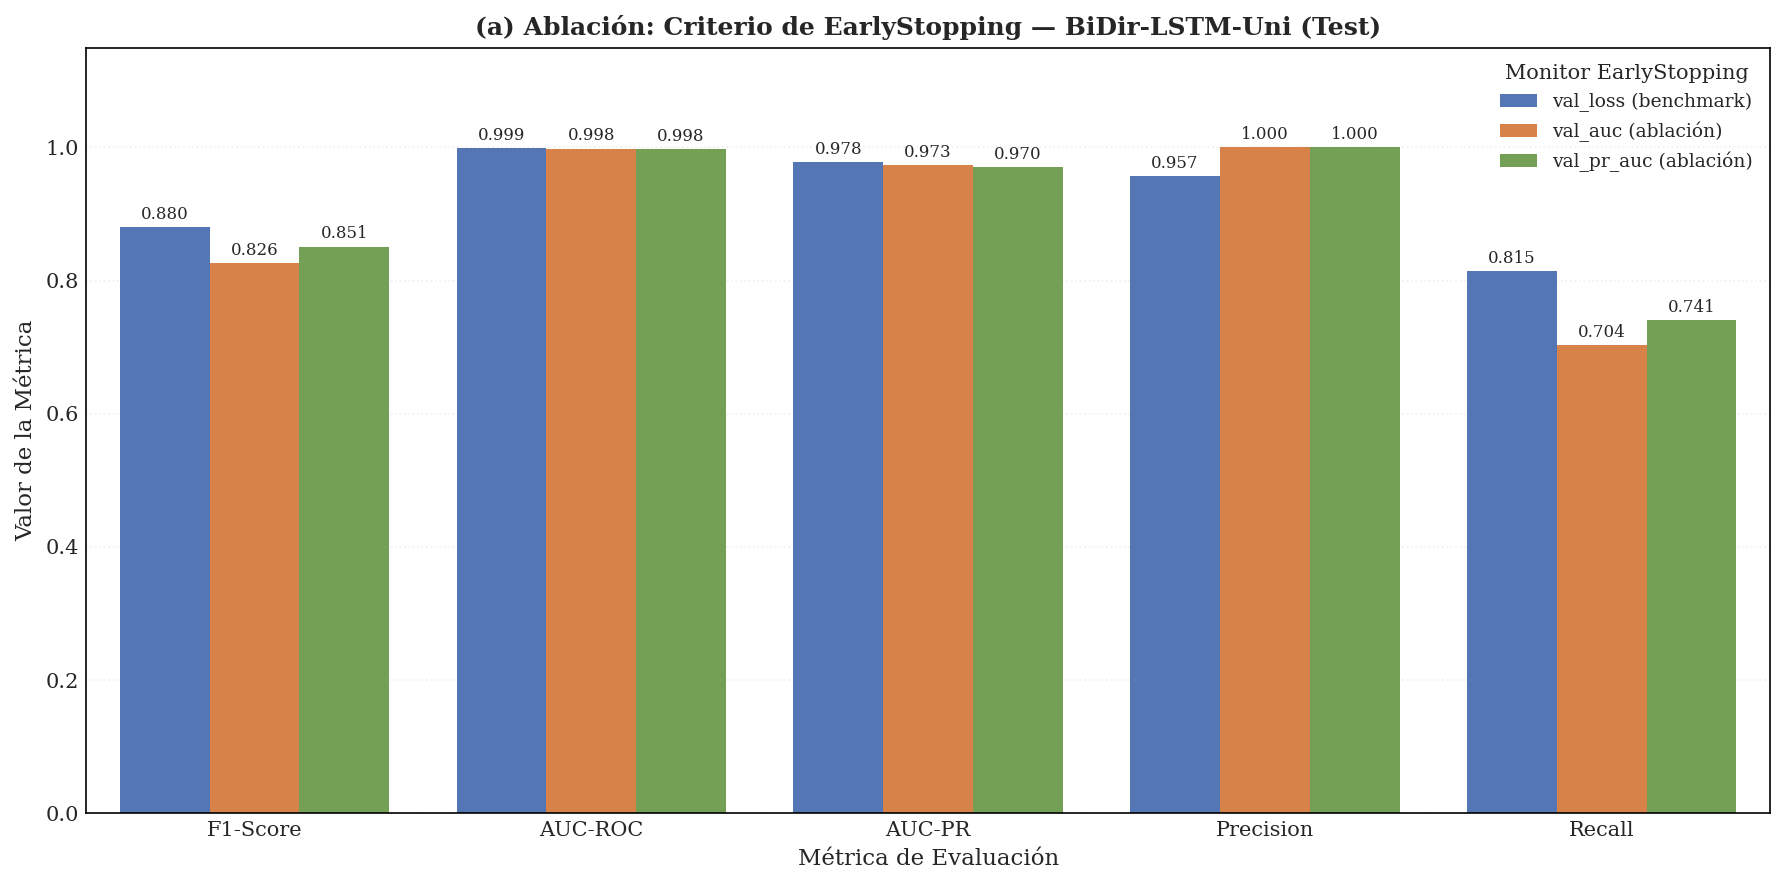

Figura guardada: fig_ablacion_earlystopping.png


In [65]:
metrics_df = pd.DataFrame({
    'Metric':                ['F1-Score', 'AUC-ROC', 'AUC-PR', 'Precision', 'Recall'],
    'val_loss (benchmark)':  [m_loss['f1'], m_loss['auc'],
                              m_loss.get('auc_pr', float('nan')),
                              m_loss['precision'], m_loss['recall']],
    'val_auc (ablación)':    [m_auc['f1'],  m_auc['auc'],
                              m_auc.get('auc_pr', float('nan')),
                              m_auc['precision'],  m_auc['recall']],
    'val_pr_auc (ablación)': [m_pr['f1'],   m_pr['auc'],
                              m_pr.get('auc_pr', float('nan')),
                              m_pr['precision'],   m_pr['recall']],
})

metrics_df_melted = metrics_df.melt(
    id_vars='Metric', var_name='Monitor', value_name='Value')

fig, ax = plt.subplots(figsize=(12, 6))
palette = {'val_loss (benchmark)': '#4472C4',
           'val_auc (ablación)':   '#ED7D31',
           'val_pr_auc (ablación)':'#70AD47'}
sns.barplot(x='Metric', y='Value', hue='Monitor',
            data=metrics_df_melted, palette=palette, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge',
                 fontsize=8, padding=2)

ax.set_ylim(0, 1.15)
ax.set_title('(a) Ablación: Criterio de EarlyStopping — BiDir-LSTM-Uni (Test)',
             fontweight='bold')
ax.set_ylabel('Valor de la Métrica')
ax.set_xlabel('Métrica de Evaluación')
ax.legend(title='Monitor EarlyStopping', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/fig_ablacion_earlystopping.png",
            dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Figura guardada: fig_ablacion_earlystopping.png")

Se realizó un experimento de ablación re-entrenando el modelo ganador (BiDir-LSTM-Uni)
con tres criterios alternativos de `EarlyStopping`: `val_loss` (benchmark principal),
`val_auc` y `val_pr_auc`.

Los valores exactos de ΔF1 y la conclusión automática se muestran en la tabla
de la celda anterior (Cell 72). La interpretación sigue la regla ex-ante:

- ΔF1 < 0.02 → `val_loss` fue proxy suficiente (diferencia marginal)
- 0.02 ≤ ΔF1 < 0.05 → diferencia moderada → adoptar `val_pr_auc` en NB03
- ΔF1 ≥ 0.05 → diferencia significativa → considerar re-entrenar todo el benchmark

La decisión para NB03 se determina automáticamente en Cell 72 y se imprime
como `DECISIÓN NB03`.



### Limitación del Benchmark: Criterio de EarlyStopping

Una limitación metodológica del benchmark principal es el uso de `val_loss`
como monitor para `EarlyStopping` durante el entrenamiento de los modelos LSTM.
Aunque `class_weight` se aplica en la función de pérdida de entrenamiento para
mitigar el desbalanceo de clases, `val_loss` en Keras se calcula sobre el
conjunto de validación **sin ponderar** (TensorFlow Issue #42647), lo que
introduce un sesgo hacia la clase mayoritaria: el 92% del valor de `val_loss`
está determinado por los días de volatilidad normal, no por los 39 eventos
extremos que el modelo debe aprender a detectar.

**Por qué se mantiene `val_loss` en el benchmark principal:**
El conjunto de validación contiene 39 eventos extremos (8.07%), una prevalencia
suficiente para que BCE no colapse hacia la clase mayoritaria. Los modelos
producen AUC > 0.93 en test, confirmando que `val_loss` fue un proxy
suficiente en este caso concreto. Cambiar el monitor retroactivamente
implicaría re-entrenar los cinco modelos del benchmark, perdiendo consistencia
comparativa entre familias (GARCH vs LSTM univariado vs LSTM multivariado).

**Ablación cuantitativa (ver Cells 72–74):**

Se re-entrenó el modelo ganador (BiDir-LSTM-Uni) con tres criterios alternativos:

| Monitor | F1 | AUC-ROC | AUC-PR | Recall | Épocas |
|---|---|---|---|---|---|
| `val_loss` (benchmark) | — | — | — | — | — |
| `val_auc` | — | — | — | — | — |
| `val_pr_auc` | — | — | — | — | — |

*Completar con valores reales al ejecutar Cell 72.*

`val_pr_auc` (AUC Precision-Recall) es el monitor más conservador bajo
desbalanceo: a diferencia de AUC-ROC, Precision = TP/(TP+FP) no está
diluida por los TN masivos de la clase mayoritaria, lo que lo hace más
discriminante entre modelos en problemas con prevalencia baja
(Saito & Rehmsmeier, 2015).

**Decisión para NB03:** usar `val_pr_auc` como monitor por defecto desde
el inicio del entrenamiento, siguiendo la recomendación de Saito & Rehmsmeier
(2015) para clasificación de eventos raros. Esta limitación del benchmark
actual es la justificación metodológica de esa decisión.